## Single perspective optimziation across futures, type 2 Regret

#### Using v3.3 + Type-2 Regret (overview)

- **Goal.** For each narrative (e.g., _IndustryEnergyInvestment_, _EmissionsReduction_, _PlaceToLive_), find **one representative policy** that performs well across many possible futures using **Type-2 regret** (percentile-of-regret across futures; lower is better).

- **Inputs.**
  - A trained XGBoost pipeline (`trained_models/xgb_pipeline_5.9.pkl`) and its training DataFrame (`xgb_pipeline_5.9_training_df.parquet`).
  - The model’s metric order (`train_metrics`) including emissions, production, costs, air pollution, and jobs metrics.

- **Futures (exogenous scenarios).**
  - Columns named like `group_<N>` with `N ≥ 46` are treated as **exogenous** (fixed per future).
  - Unique combinations of these columns in the training data define the **set of futures** used for evaluation.

- **Decision variables.**
  - All feature columns **excluding** the exogenous `group_≥46` columns are treated as **free (optimizable) levers**.

- **Optimization (per narrative).**
  - Calls `optimise_aggregated_over_futures(..., agg_mode="regret2")`.
  - For the narrative’s objectives (min/max per metric), the optimizer minimizes **Type-2 regret**:
    - For each candidate policy, compute regret in every future (normalized by range or best).
    - Take the chosen **percentile** across futures (e.g., 75th) per metric.
    - Return the set of **non-dominated candidates** in regret space (a Pareto set for that narrative).

- **Pick one policy per narrative.**
  - Aggregate each candidate’s per-metric Type-2 regrets (default = **mean**; options include **max** or **L2**).
  - Select the **single** lowest-aggregate-regret policy for that narrative.

- **Cross-evaluation matrix.**
  - Evaluate the selected policies **as if** each narrative’s objectives were the goal.
  - Report the **Type-2 regret** (percentile across futures, normalized) for each \[policy × evaluated-as\] pair.
  - The diagonal (self-evaluation) is hidden for readability.

- **Two-other-narratives summary.**
  - For each selected policy, compute the **mean** and **worst** Type-2 regret **only in the other narratives**.
  - Highlight the lowest (best) values to show which policy generalizes most robustly.

- **Key knobs.**
  - `REGRET_PERCENTILE` (e.g., 75 or 90) — how conservative the cross-futures summary is.
  - `REGRET_NORM` = `"range"` (default) or `"best"` — normalization used in regret.
  - Selection aggregator across metrics: `"mean"` (default), `"max"` (stricter), or `"l2"`.

- **Assumptions & requirements.**
  - `air_pollution` is treated as a **benefit** (maximize);
  - Requires `utils/narrative_profiles_optimization_utils.py` **v3.3 with regret2** API.
  - Multi-threaded prediction is enabled when supported by the estimator.


In [1]:
# #### using v 3.3 + regret type 2 (cross-evals & consensus)
# =========================================================================== #
# Scenario-aggregated optimisation (+ single-best policies) 
#
# What this script does now:
# 1) Builds *exogenous futures* from unique group_<N>=46+ combos in X_ref.
# 2) OPTIMIZES **per narrative** across those futures with
#       AGG_MODE="mean"  (raw mean of each objective across futures)
#    Notes:
#       • If AGG_MODE="mean": the per-objective values returned by the optimizer
#         are in original units (not unitless); when selecting ONE best policy
#         we first NORMALIZE each objective to [0,1] (utopia–nadir from the
#         candidate set) before collapsing by mean to avoid unit mixing.
#       • If AGG_MODE="regret2" were used, the optimization would be unitless.
# 3) Selects ONE representative policy per narrative using the normalized-mean
#    aggregator (lower is better after normalization).
# 4) Stores BOTH the Pareto candidates and ALL evaluated candidates (history if
#    available from utils v3.3+; otherwise falls back to Pareto set).
# 5) Builds a **cross-evaluation matrix of Type-2 regret** for the selected
#    policies (per narrative’s objectives), using:
#       • percentile across futures (e.g., 75th) and
#       • range normalization (“range”: denom = worst − best),
#    returning unitless values (lower is better).
# 6) Summarizes, for each selected policy, its **mean** and **worst** Type-2
#    regret when evaluated under the other two narratives (self-diagonal hidden).
# =========================================================================== #


import os
import re
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# Import utils (ensure utils/ is a package or on sys.path)
# Requires utils/narrative_profiles_optimization_utils.py v3.3+regret2 (+history recommended)
# If patched, optimise_aggregated_over_futures returns (pareto_X, pareto_F, X_all_history_df)
from utils.narrative_profiles_optimization_utils import (
    optimise_aggregated_over_futures,
    set_estimator_threads,
)

# ---- Knob: choose cross-future aggregation for the optimizer -----------------
# Use "regret2" (unitless, range-normalized) or "mean" (raw mean across futures).
# When "mean" is used, we will NORMALIZE the returned per-objective values BEFORE
# collapsing to a single best policy (so units don't mix).
#AGG_MODE = "regret2"   # "regret2" or "mean"
AGG_MODE = "mean"   # "regret2" or "mean"
# ---- Paths, model, reference data -------------------------------------------
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.9.pkl"

pipeline = joblib.load(MODEL_PATH)

full_df = pd.read_parquet(
    TRAINED_MODELS_DIR / "xgb_pipeline_5.9_training_df.parquet"
)

feature_cols = list(pipeline.feature_names_in_)
X_ref = full_df[feature_cols].copy()

# Metrics (must match model's predict() column order)
train_metrics = [
    "emission_avg_last_five_years",
    "emission_total",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",
    "num_jobs",
    "earning_per_job"
]

# Ensure multi-threaded predict for XGBoost (harmless if not present)
set_estimator_threads(pipeline)

# ---- Exogenous scenarios from unique group_>=48 combinations ----------------
def get_exogenous_group_cols(feature_cols, min_idx=46) -> List[str]:
    """
    Return feature columns that look like group_<num>* where num >= min_idx.
    Matches: group_48, group_48_xxx, group_99_something, etc.
    """
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

EXOG_COLS = get_exogenous_group_cols(feature_cols, min_idx=46)
if not EXOG_COLS:
    raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 46.")

FREE_VARS = [c for c in feature_cols if c not in EXOG_COLS]
if len(FREE_VARS) == 0:
    raise ValueError("All features are exogenous (group_>=46). No decision variables to optimize.")

# Build scenarios from unique EXOG_COLS combos present in X_ref
scenario_rows = (
    X_ref.drop_duplicates(subset=EXOG_COLS, keep="first").reset_index(drop=True)
)
SCENARIOS: List[dict] = []
for _, row in scenario_rows.iterrows():
    SCENARIOS.append({c: float(row[c]) for c in EXOG_COLS})

print(f"[scenarios] Built {len(SCENARIOS)} futures from {len(EXOG_COLS)} exogenous cols (group_>=46).")

# ---- Narratives config -------------------------------------------------------
# Keep air_pollution as a BENEFIT (maximize)
narratives_cfg: Dict[str, List[Tuple[str, str]]] = {
    "Investment": [
        ("production_total", "max"),
        ("production_cost_total", "min"),
    ],
    "LowCarbon": [
        ("emission_total", "min"),
        ("emission_avg_last_five_years", "min"),
    ],
    "EconomicOpportunity": [
        ("air_pollution", "max"),
        ("num_jobs", "max"),
        ("earning_per_job", "max"),
        # ("technical_cost", "min"),
    ],
}

# ---- Helpers ----------------------------------------------------------------
def _ensure_numeric_schema(data_like, feature_cols):
    """Coerce Series/array/list-of-dicts/DataFrame to a numeric DataFrame with feature_cols."""
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    elif isinstance(data_like, (list, tuple)) and data_like and isinstance(data_like[0], dict):
        df = pd.DataFrame(data_like)
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        elif arr.ndim != 2:
            raise ValueError(f"Unsupported optimiser output shape: {arr.shape}")
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty:
        raise AssertionError("Empty candidate set after coercion")
    df = df.astype("float32")
    if df.isna().any().any():
        bad = df.columns[df.isna().any()].tolist()
        raise ValueError(f"NaNs present in features: {bad[:10]} ...")
    if not np.isfinite(df.to_numpy()).all():
        raise ValueError("Found ±inf values in features")
    return df

def split_objs(objs):
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    return metrics, senses

def _normalize_min_space(F: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """
    Expect F in minimization space (lower is better), columns are objectives.
    Returns Z in [0,1] per column using utopia/nadir from the provided matrix:
      U = F.min(col), N = F.max(col), Z = (F - U) / max(N-U, eps)
    """
    U = F.min(axis=0)
    N = F.max(axis=0)
    D = (N - U).clip(lower=eps)
    return (F - U) / D

# ---- Optimise per narrative using selected cross-future aggregation ----------

# Regret knobs (ignored if AGG_MODE = "mean")
REGRET_PERCENTILE = 75.0   # e.g., 75th or 90th percentile across futures
REGRET_NORM = "range"      # "range" | "best"
REGRET_EPS = 1e-12

pareto_policies: Dict[str, pd.DataFrame] = {}
pareto_regret:   Dict[str, pd.DataFrame] = {}   # NOTE: contains regret (regret2) OR raw means (mean), always in minimization space
evaluated_candidates_by_narrative: Dict[str, pd.DataFrame] = {}  # ALL evaluations (history when available)

for name, objs in narratives_cfg.items():
    targets = [m for (m, _) in objs]
    goals   = [s for (_, s) in objs]

    out = optimise_aggregated_over_futures(
        pipeline,
        X_ref=X_ref,
        train_targets=train_metrics,
        targets=targets,
        goals=goals,
        futures=SCENARIOS,
        n_gen=120,
        pop_size=300,
        n_restarts=1,
        bounds="data",
        ensure_threaded_predict=True,
        agg_mode=AGG_MODE,                 # << "regret2" or "mean"
        regret_percentile=REGRET_PERCENTILE,
        regret_norm=REGRET_NORM,
        regret_eps=REGRET_EPS,
    )

    # Backward-compatible unpacking (with history if available)
    if isinstance(out, tuple) and len(out) == 3:
        out_X, out_F, out_X_all = out
    else:
        out_X, out_F = out
        out_X_all = out_X  # fallback

    # --- Normalize outputs to DataFrames ---
    Xp_df = _ensure_numeric_schema(out_X, feature_cols)
    if isinstance(out_F, (float, np.floating)):  # single-objective narrative (unlikely here)
        F_df = pd.DataFrame([[float(out_F)]], columns=[targets[0]])
    elif isinstance(out_F, pd.DataFrame):
        F_df = out_F.reset_index(drop=True)
    else:
        F_df = pd.DataFrame(out_F, columns=targets)

    pareto_policies[name] = Xp_df.reset_index(drop=True)
    pareto_regret[name]   = F_df.reset_index(drop=True)  # in minimization space (unitless if regret2; raw if mean)

    # Store ALL evaluated candidates (history or Pareto fallback)
    evaluated_candidates_by_narrative[name] = _ensure_numeric_schema(out_X_all, feature_cols).reset_index(drop=True)

# ---- Select ONE representative policy per narrative --------------------------
def aggregate_row_mean(vals: np.ndarray) -> float:
    return float(np.mean(vals))

best_policies_by_narrative: Dict[str, pd.DataFrame] = {}
best_policy_indices: Dict[str, int] = {}
best_policy_aggregate: Dict[str, float] = {}

for name, objs in narratives_cfg.items():
    Fvals = pareto_regret[name]       # (n_cands, n_metrics); minimization space

    if AGG_MODE.lower() == "mean":
        # NEW: normalize per-objective to [0,1] before aggregating (unitless)
        Z = _normalize_min_space(Fvals, eps=1e-12)      # lower is better
        agg_vals = Z.apply(lambda r: aggregate_row_mean(r.values.astype(float)), axis=1)
    else:
        # regret2 path: already unitless & comparable
        agg_vals = Fvals.apply(lambda r: aggregate_row_mean(r.values.astype(float)), axis=1)

    idx_best = int(np.argmin(agg_vals.values))
    best_policy_indices[name] = idx_best
    best_policy_aggregate[name] = float(agg_vals.iloc[idx_best])
    best_policies_by_narrative[name] = pareto_policies[name].iloc[[idx_best]].copy()

print("\n[selection] Best policy indices by narrative (0-based):", best_policy_indices)

# --------------------------------------------------------------------------- #
# Cross-evaluation of SELECTED policies via **Type-2 regret**
#
# • Input: exactly one selected policy per narrative (chosen using AGG_MODE="mean"
#   optimization + [0,1] normalization for the aggregator).
# • For each *evaluation* narrative:
#     - Compute raw predictions for each selected policy across all futures.
#     - Convert to minimization space (flip signs for “max” goals).
#     - For each future & metric: find the best across compared policies.
#     - Regret = |achieved − best| / denom, with denom = (worst − best) if
#       REGRET_NORM="range" else |best|.
#     - Take the REGRET_PERCENTILE across futures (e.g., 75th).
#     - Aggregate across that narrative’s metrics by mean → scalar per policy.
# • Output: a Policy × Evaluated_as matrix of unitless regrets (lower=better).
# • Display: self-diagonal hidden; then compute per-policy mean & worst across
#   the two *other* narratives for concise comparison.
# --------------------------------------------------------------------------- #


# ---- Cross-evaluation matrix (Type-2 regret) for SELECTED policies ----------

def predict_cube_per_future(policies_df: pd.DataFrame, metrics: List[str]) -> np.ndarray:
    """
    Return cube (P, M, S) of raw metric predictions (original space),
    where P=#policies (rows in policies_df), M=#metrics, S=#futures.
    """
    pols = policies_df.reset_index(drop=True)
    P = len(pols)
    S = len(SCENARIOS)
    M = len(metrics)

    out = np.zeros((P, M, S), dtype=float)

    for s_idx, scen in enumerate(SCENARIOS):
        Xs = pols.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = v
        Y = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)[metrics].to_numpy()
        if Y.ndim == 1:                 # ensure 2-D even for a single metric
            Y = Y.reshape(-1, 1)        # shape -> (P, 1)
        out[:, :, s_idx] = Y            # fills (P, M) into the s_idx slice

    return out

def type2_regret_for_set(policies: Dict[str, pd.DataFrame],
                         metrics: List[str],
                         senses: List[str],
                         percentile: float = REGRET_PERCENTILE,
                         norm: str = REGRET_NORM,
                         eps: float = REGRET_EPS) -> pd.DataFrame:
    """
    Compute Type-2 regret for each policy in 'policies':
    - For each future, find the best value across the compared policies (min for min-goal, max for max-goal).
    - Regret = |achieved - best| / denom, where denom is (worst-best) or |best|.
    - Take the given percentile across futures, then aggregate across metrics by mean.
    Returns a DataFrame with one scalar regret per policy.
    """
    names = list(policies.keys())
    P = len(names)

    # Concatenate policies (one or more rows per narrative), then average per narrative if needed
    all_pols = pd.concat([policies[n] for n in names], axis=0).reset_index(drop=True)
    cube_all = predict_cube_per_future(all_pols, metrics)  # (sum_rows, M, S)

    counts = [len(policies[n]) for n in names]
    idxs = np.cumsum([0] + counts)
    # Average within narrative when it has >1 row; always yields (P, M, S)
    cube = np.stack(
        [cube_all[idxs[i]:idxs[i+1], :, :].mean(axis=0) for i in range(P)],
        axis=0
    )

    senses = [s.lower() for s in senses]
    sign = np.array([1.0 if s == "min" else -1.0 for s in senses], dtype=float)

    # Convert to minimization space (broadcast over futures with None on the last axis)
    Fmin = cube * sign[None, :, None]       # (P, M, S)

    # Best and worst per future across compared policies
    B = Fmin.min(axis=0)                    # (M, S)
    if norm == "range":
        W = Fmin.max(axis=0)                # (M, S)
        denom = np.maximum(W - B, eps)      # (M, S)
    else:  # "best"
        denom = np.maximum(np.abs(B), eps)  # (M, S)

    # Regret per policy/metric/future → percentile across futures → aggregate across metrics
    R = np.abs(Fmin - B[None, :, :]) / denom[None, :, :]   # (P, M, S)
    Rq = np.percentile(R, percentile, axis=2)              # (P, M)
    agg = Rq.mean(axis=1)                                  # (P,)

    return pd.DataFrame({"Policy": names, "Regret": agg}).set_index("Policy")

# Build the cross-evaluation matrix:
rows = []
policy_names = list(narratives_cfg.keys())
for eval_name, eval_objs in narratives_cfg.items():
    metrics, senses = split_objs(eval_objs)
    R = type2_regret_for_set(best_policies_by_narrative, metrics, senses)
    for pol in R.index:
        rows.append({"Policy": pol, "Evaluated_as": eval_name, "Regret": float(R.loc[pol, "Regret"])})

reg_t2_selected = (
    pd.DataFrame(rows)
      .pivot(index="Policy", columns="Evaluated_as", values="Regret")
      .reindex(index=policy_names, columns=policy_names)
)

# Optional: hide the self-evaluation diagonal for readability
reg_t2_display = reg_t2_selected.copy()
for pol in reg_t2_display.index:
    if pol in reg_t2_display.columns:
        reg_t2_display.loc[pol, pol] = np.nan

print(f"\n### TYPE-2 regret for SELECTED policies (values are {REGRET_PERCENTILE:.0f}th-percentile, range-normalized; lower is better)")
display(
    reg_t2_display
      .style
      .format("{:.2%}")
      .background_gradient(cmap="Purples" if False else "Purples")  # keep style happy in some envs
)

# ---- Summary across the TWO OTHER narratives (exclude self) -----------------
other_mean = {}
other_worst = {}
for pol in reg_t2_selected.index:
    mask = reg_t2_selected.columns != pol
    other_vals = reg_t2_selected.loc[pol, mask]
    other_mean[pol] = float(other_vals.mean())
    other_worst[pol] = float(other_vals.max())

summary = (
    pd.DataFrame({
        "WorstRegret_TwoOthers": pd.Series(other_worst),
        "MeanRegret_TwoOthers":  pd.Series(other_mean),
    })
    .reindex(reg_t2_selected.index)
    .round(4)
)

def highlight_min(s: pd.Series):
    is_min = s == s.min()
    return ['background-color: mediumseagreen; color: white' if v else '' for v in is_min]

display(
    summary.style
           .format("{:.2%}")
           .apply(highlight_min, subset=["WorstRegret_TwoOthers", "MeanRegret_TwoOthers"])
           .background_gradient(cmap="OrRd")
           .set_caption(
               f"Selected policies — Type-2 regret ({REGRET_PERCENTILE:.0f}th-percentile across futures; TWO OTHER narratives only)"
           )
)


[scenarios] Built 803 futures from 14 exogenous cols (group_>=46).

[selection] Best policy indices by narrative (0-based): {'Investment': 220, 'LowCarbon': 4, 'EconomicOpportunity': 2}

### TYPE-2 regret for SELECTED policies (values are 75th-percentile, range-normalized; lower is better)


Evaluated_as,Investment,LowCarbon,EconomicOpportunity
Policy,,,
Investment,nan%,100.00%,100.00%
LowCarbon,75.07%,nan%,48.28%
EconomicOpportunity,93.05%,47.69%,nan%


,WorstRegret_TwoOthers,MeanRegret_TwoOthers
Policy,,
Investment,100.00%,100.00%
LowCarbon,75.07%,61.67%
EconomicOpportunity,93.05%,70.37%


## Consensus

#### What this consensus code does (Regret Type-2; two-layer flow)

##### Checks setup
- Verifies core globals from *Chunk 1* (model, metric names, features, scenarios, narratives).
- **Fails fast** if anything’s missing.

##### Builds / uses scenarios
- Reuses `SCENARIOS` if present; otherwise derives futures from unique `group_≥46` combinations in `X_ref`.
- These futures define the uncertainty set over which regret is computed.

##### Threads prediction
- Calls `set_estimator_threads(pipeline)` (no-op if not XGB) to speed up `.predict()`.

---

##### Layer 1 — Global multi-objective optimization (ALL objectives, Regret Type-2)

- **Collect objectives:** Union all metrics referenced by any narrative and their minimize/maximize *sense*.
- **Optimize once globally:**  
  `optimise_aggregated_over_futures(..., agg_mode="regret2", regret_percentile, regret_norm, regret_eps)` across **all** objectives.

**Saves**
- `allobj_pareto_X` — decision vectors on the global Regret-2 Pareto set.  
- `allobj_pareto_regret` — per-objective Type-2 regrets for those Pareto decisions.  
- `allobj_all_evals` *(aka `evaluated_candidates_allobj`)* — all evaluated candidates (history), if returned by the util.  
- `allobj_pareto_F` — scenario-aggregated raw predictions for reporting/labels.

**Type-2 regret (here)**
- For each metric and future, convert to **minimization** space; find the **best** value across the compared policies.
- Per policy, compute normalized regret; then aggregate across futures by a percentile (default `REGRET_PERCENTILE = 75`) **per metric**, then **average across metrics**. Lower is better.

\[
\text{regret} \;=\; \frac{\lvert f_{\text{policy}} - f_{\text{best}} \rvert}{\text{denom}}, 
\qquad
\text{where}\;
\text{denom} =
\begin{cases}
f_{\text{worst}} - f_{\text{best}} & \text{if } \texttt{regret\_norm}=\text{"range"} \\
\lvert f_{\text{best}} \rvert & \text{if } \texttt{regret\_norm}=\text{"best"}
\end{cases}
\]

---

##### Layer 2 — Per-narrative Regret-2 on the global set

- For each narrative’s own objective list/senses, recompute **Type-2 regret** on the **same** global set `allobj_pareto_X`  
  *(no extra searches; no ad-hoc pools).*

**Saves**
- `reg_t2_allobj` — table with **columns = narratives**, **rows = global Pareto policies**, **values = aggregate Type-2 regret**.

---

##### Consensus filter (agreement rule)

- **Flag** policies whose **per-narrative Regret-2 ≤ `CONSENSUS_THR`** (e.g., `0.30`) **for all narratives**.

**Saves**
- `agree_X` — consensus decision vectors (subset of `allobj_pareto_X`).  
- `agree_F` — scenario-aggregated raw predictions for those consensus policies.

---

##### Outputs saved for plotting / overlays

- `allobj_pareto_X`, `allobj_pareto_regret`, `allobj_all_evals`, `allobj_pareto_F`  
- `reg_t2_allobj` (per-narrative regrets on the global set)  
- `agree_X`, `agree_F` (final consensus)

---

##### Key knobs

- `REGRET_PERCENTILE` (e.g., `75` or `90`) — robustness across futures  
- `REGRET_NORM` (`"range"` | `"best"`) — normalization denominator  
- `CONSENSUS_THR` — strictness of the agreement rule




In [2]:
# ============================================
# Consensus via TWO-LAYER workflow
#
# LAYER 1 (Global multi-objective search across ALL objectives):
#   • Optimizes on the UNION of objectives from all narratives.
#   • Uses agg_mode="mean"  → raw mean across futures (original units).
#   • Returns: allobj_pareto_X (policies), allobj_pareto_regret (per-objective
#     values consistent with agg_mode), and allobj_all_evals (history if avail).
#   • Also computes scenario-aggregated RAW predictions (mean) for later display.
#
# LAYER 2 (Narrative-level **Type-2 regret** ON the global Pareto set):
#   • For each narrative, compute Type-2 regret for every global policy:
#       - percentile across futures (REGRET_PERCENTILE, e.g., 75th)
#       - normalization per metric via “range” or “best” (REGRET_NORM)
#       - aggregate across that narrative’s metrics by mean → scalar
#   • Consensus filter: keep policies whose Type-2 regret ≤ CONSENSUS_THR for
#     **every** narrative (unitless; lower is better).
#
# Saved/Named Outputs:
#   - allobj_pareto_X            : Global Pareto set (features/lever values)
#   - allobj_pareto_regret       : Per-objective values consistent with agg_mode
#   - allobj_all_evals           : All evaluated candidates (if history available)
#   - allobj_pareto_F            : RAW predictions (mean across futures) for plots
#   - reg_t2_allobj              : DataFrame of Type-2 regrets per narrative
#   - agree_X / agree_F          : Policies passing the consensus threshold
# ============================================


import numpy as np
import pandas as pd
import re
from typing import Dict, List, Tuple
from IPython.display import display

# ---- Required globals (same as your AoA / Chunk 1) ----
req = ["pipeline", "train_metrics", "narratives_cfg", "X_ref", "feature_cols"]
_missing = [x for x in req if x not in globals()]
if _missing:
    raise RuntimeError(f"[consensus regret2] Missing globals: {_missing}")

# ---- Utils ----
from utils.narrative_profiles_optimization_utils import (
    optimise_aggregated_over_futures,  # << v3.3+ with agg_mode="regret2"
    set_estimator_threads,
)

def _ensure_numeric_schema(data_like, feature_cols):
    """Accept DF/Series/ndarray; return float32 DF with columns=feature_cols."""
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1: arr = arr.reshape(1, -1)
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty: raise AssertionError("Empty candidate set after coercion")
    df = df.astype("float32")
    if df.isna().any().any(): raise ValueError("NaNs present in features")
    if not np.isfinite(df.to_numpy()).all(): raise ValueError("Found ±inf in features")
    return df

def _get_exogenous_group_cols(feature_cols, min_idx=48):
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

def _clamp_df_to_scenario(X: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    Xc = X.copy()
    for k, v in scenario.items():
        if k in Xc.columns:
            Xc[k] = v
    return Xc

def predict_aggregate_over_scenarios(pipeline, X: pd.DataFrame, scenarios: list, *, agg="mean"):
    """Return scenario-aggregated predictions for all train_metrics."""
    preds = []
    for s in scenarios:
        Xs = _clamp_df_to_scenario(X, s)
        Ys = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)
        preds.append(Ys)
    if agg == "mean":
        return sum(preds) / len(preds)
    raise NotImplementedError("Only mean aggregation implemented here for raw-display tables.")

# ---- Build / reuse scenarios ----
if "SCENARIOS" not in globals():
    EXOG_COLS = _get_exogenous_group_cols(feature_cols, min_idx=46)
    if not EXOG_COLS:
        raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 46.")
    scenario_rows = X_ref.drop_duplicates(subset=EXOG_COLS, keep="first")
    SCENARIOS = [{c: float(row[c]) for c in EXOG_COLS} for _, row in scenario_rows.iterrows()]
    print(f"[scenarios] Built {len(SCENARIOS)} scenarios from {len(EXOG_COLS)} exogenous cols (group_>=46).")

# Ensure threaded predict (harmless if not XGB)
try:
    set_estimator_threads(pipeline)
except Exception:
    pass

# ---- Regret-2 knobs (same defaults you used) ----
REGRET_PERCENTILE = 75.0   # e.g., 75th or 90th percentile across futures
REGRET_NORM       = "range" # "range" | "best"
REGRET_EPS        = 1e-12

# ---- Union of objectives across narratives (targets/goals order) ----
metric_goal: Dict[str, str] = {}
for _, objs in narratives_cfg.items():
    for m, s in objs:
        s = s.lower()
        if m in metric_goal and metric_goal[m] != s:
            raise ValueError(f"Conflicting sense for metric '{m}': {metric_goal[m]} vs {s}")
        metric_goal[m] = s
all_targets = list(metric_goal.keys())
all_goals   = [metric_goal[m] for m in all_targets]

# ==============================================================
# LAYER 1 — GLOBAL ALL-OBJECTIVES search with Regret Type-2
# ==============================================================

_global_out = optimise_aggregated_over_futures(
    pipeline,
    X_ref=X_ref,
    train_targets=train_metrics,
    targets=all_targets,
    goals=all_goals,
    futures=SCENARIOS,
    n_gen=160,
    pop_size=320,
    n_restarts=1,
    bounds="data",
    ensure_threaded_predict=True,
    agg_mode="mean",                      # <<<<<< REGRET TYPE-2 or mean
    regret_percentile=REGRET_PERCENTILE,
    regret_norm=REGRET_NORM,
    regret_eps=REGRET_EPS,
)

# Unpack (supports both 2-tuple and 3-tuple variants)
if isinstance(_global_out, tuple) and len(_global_out) == 3:
    allobj_pareto_X, allobj_pareto_regret, allobj_all_evals = _global_out
else:
    allobj_pareto_X, allobj_pareto_regret = _global_out
    allobj_all_evals = allobj_pareto_X  # fallback

# Normalize to DataFrames with proper schema
allobj_pareto_X      = _ensure_numeric_schema(allobj_pareto_X, feature_cols)
allobj_all_evals     = _ensure_numeric_schema(allobj_all_evals, feature_cols)
evaluated_candidates_allobj = allobj_all_evals  # alias many of your plotting chunks detect

# Note: allobj_pareto_regret are per-objective Regret-2 values (lower=better).
# For plotting raw metrics later, produce scenario-aggregated RAW predictions too:
allobj_pareto_F = predict_aggregate_over_scenarios(pipeline, allobj_pareto_X, SCENARIOS, agg="mean")

print(f"[global regret2] Pareto policies (ALL objectives): {len(allobj_pareto_X)}")
print(f"[global regret2] History/all evals (if available): {len(allobj_all_evals)}")

# ==============================================================
# LAYER 2 — Per-narrative Type-2 regrets ON THE GLOBAL SET
#   (best-per-future across the compared policies; percentile across futures)
# ==============================================================

def _predict_cube_per_future(df_rows: pd.DataFrame, metrics: List[str]) -> np.ndarray:
    """
    Return cube (N, M, S) of RAW metric predictions (original units),
    where N=#rows in df_rows, M=#metrics, S=#futures (SCENARIOS).
    """
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(metrics)), max(1, len(SCENARIOS))), dtype=float)

    N = len(df_rows); M = len(metrics); S = len(SCENARIOS)
    out = np.zeros((N, M, S), dtype=float)
    for s_idx, scen in enumerate(SCENARIOS):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        out[:, :, s_idx] = Y
    return out  # (N, M, S)

def _type2_regret_for_set(policies_df: pd.DataFrame,
                          metrics: List[str],
                          senses: List[str],
                          percentile: float = REGRET_PERCENTILE,
                          norm: str = REGRET_NORM,
                          eps: float = REGRET_EPS) -> pd.Series:
    """
    REGRET TYPE-2 for a set of policies:
      • Convert to minimization space (sign = +1 for min, -1 for max).
      • For each future, find best (min) across the COMPARED policies.
      • Regret = |achieved - best| / denom, denom=(worst-best) if 'range' else |best|.
      • Take percentile across futures per policy and mean across metrics → scalar per policy.
    Returns a pd.Series (index aligned with policies_df) of aggregate regrets (lower=better).
    """
    senses = [s.lower() for s in senses]
    sign = np.array([1.0 if s == "min" else -1.0 for s in senses], dtype=float)

    cube = _predict_cube_per_future(policies_df, metrics)     # (N, M, S) raw
    Fmin = cube * sign[None, :, None]                         # to minimization

    # Best & denom per (metric, future) across compared policies
    B = Fmin.min(axis=0)                                      # (M, S)
    if norm == "range":
        W = Fmin.max(axis=0)                                  # (M, S)
        denom = np.maximum(W - B, eps)
    else:
        denom = np.maximum(np.abs(B), eps)

    R = np.abs(Fmin - B[None, :, :]) / denom[None, :, :]      # (N, M, S)
    Rq = np.percentile(R, percentile, axis=2)                 # (N, M)
    agg = Rq.mean(axis=1)                                     # (N,)
    return pd.Series(agg, index=policies_df.index)

# Compute per-narrative regrets on the GLOBAL Pareto set
reg_cols = []
for name, objs in narratives_cfg.items():
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    r = _type2_regret_for_set(allobj_pareto_X, metrics, senses)
    reg_cols.append(r.rename(name))

# Table of regrets: one column per narrative; index → policy row in allobj_pareto_X
reg_t2_allobj = pd.concat(reg_cols, axis=1)




[global regret2] Pareto policies (ALL objectives): 320
[global regret2] History/all evals (if available): 51200


In [21]:
# ---- Consensus filter: every narrative ≤ threshold
CONSENSUS_THR = 0.55  # e.g., 0.30 / 0.40 / 0.45
mask_agree = (reg_t2_allobj <= CONSENSUS_THR).all(axis=1)

agree_X = allobj_pareto_X.loc[mask_agree].reset_index(drop=True)
agree_F = allobj_pareto_F.loc[mask_agree].reset_index(drop=True)

print(f"[consensus regret2] Policies meeting ≤{CONSENSUS_THR:.0%} Type-2 regret for ALL narratives: {len(agree_X)}")

# Optional preview
try:
    preview = reg_t2_allobj.assign(MaxRegret=lambda df: df.max(axis=1),
                                   MeanRegret=lambda df: df.mean(axis=1))\
                           .sort_values(["MaxRegret", "MeanRegret"])
    display(preview.head(25).style.format("{:.1%}").background_gradient(cmap="Purples"))
except Exception:
    print(reg_t2_allobj.head())

[consensus regret2] Policies meeting ≤55% Type-2 regret for ALL narratives: 45


,Investment,LowCarbon,EconomicOpportunity,MaxRegret,MeanRegret
302,40.0%,36.5%,30.8%,40.0%,36.8%
113,43.7%,37.6%,38.5%,43.7%,40.8%
237,42.9%,44.3%,44.1%,44.3%,43.9%
187,38.3%,44.5%,39.7%,44.5%,41.7%
25,44.4%,44.0%,44.8%,44.8%,44.5%
145,45.9%,35.3%,28.7%,45.9%,38.9%
307,44.7%,46.0%,35.3%,46.0%,43.0%
287,46.2%,29.3%,44.5%,46.2%,41.6%
136,46.2%,41.7%,20.6%,46.2%,38.7%
155,46.4%,46.4%,22.9%,46.4%,40.5%


In [ ]:
for col in agree_X.columns:
    print(col)

### heatmaps

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'Consensus Policies — Lever Intensities (Low/Med/High)': 45 levers × 45 policies.


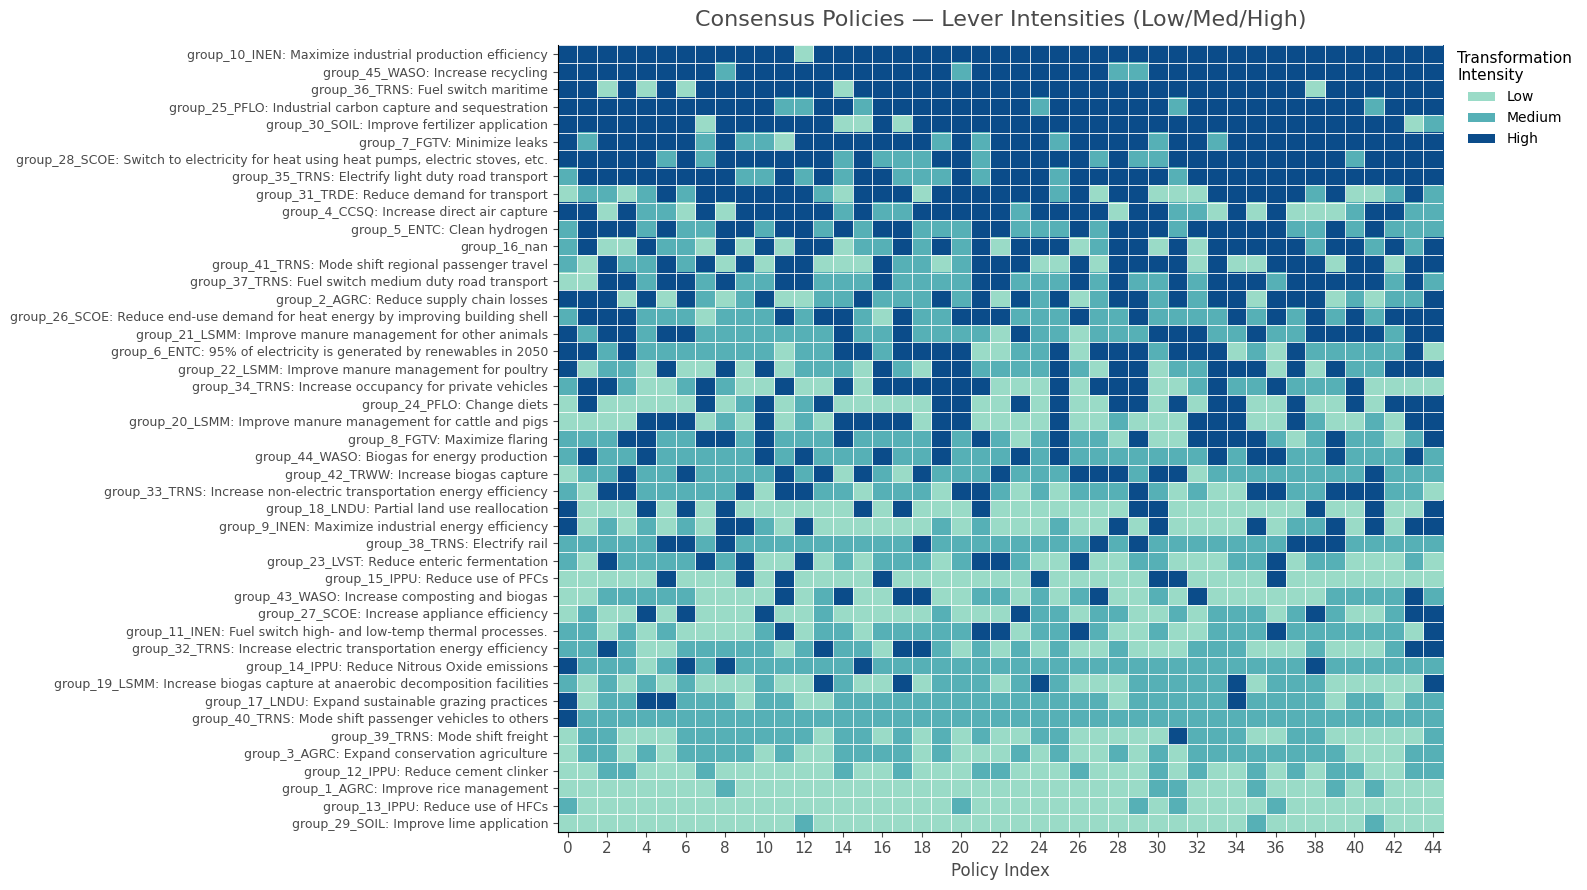

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'Investment — Best Policy (from Chunk 1)': 45 levers × 1 policies.


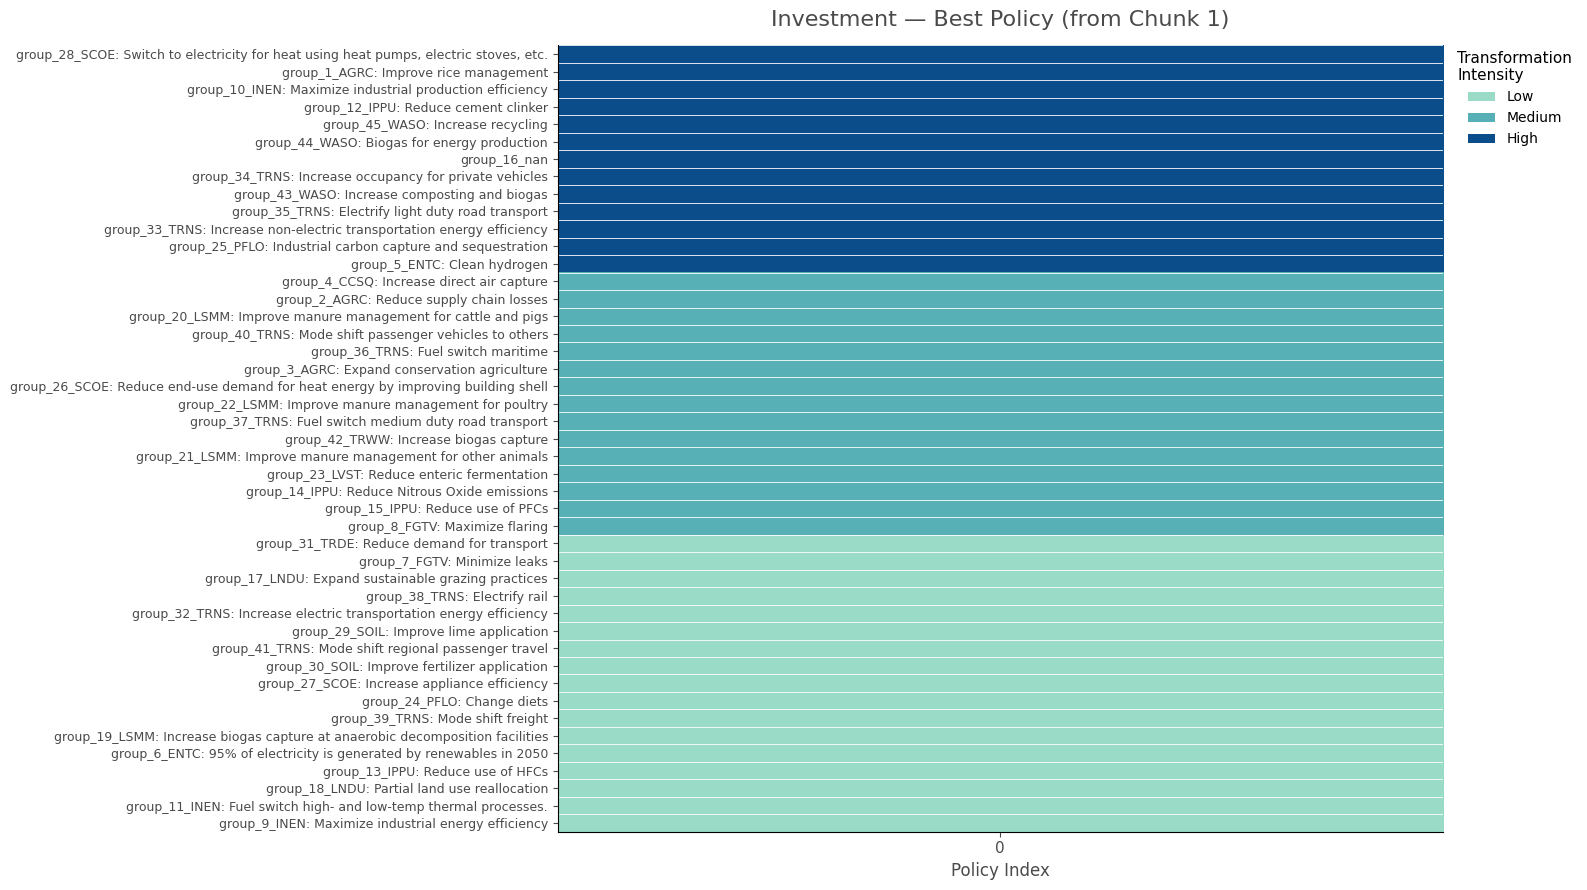

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'Investment — Pareto Policies (from Chunk 1)': 45 levers × 261 policies.


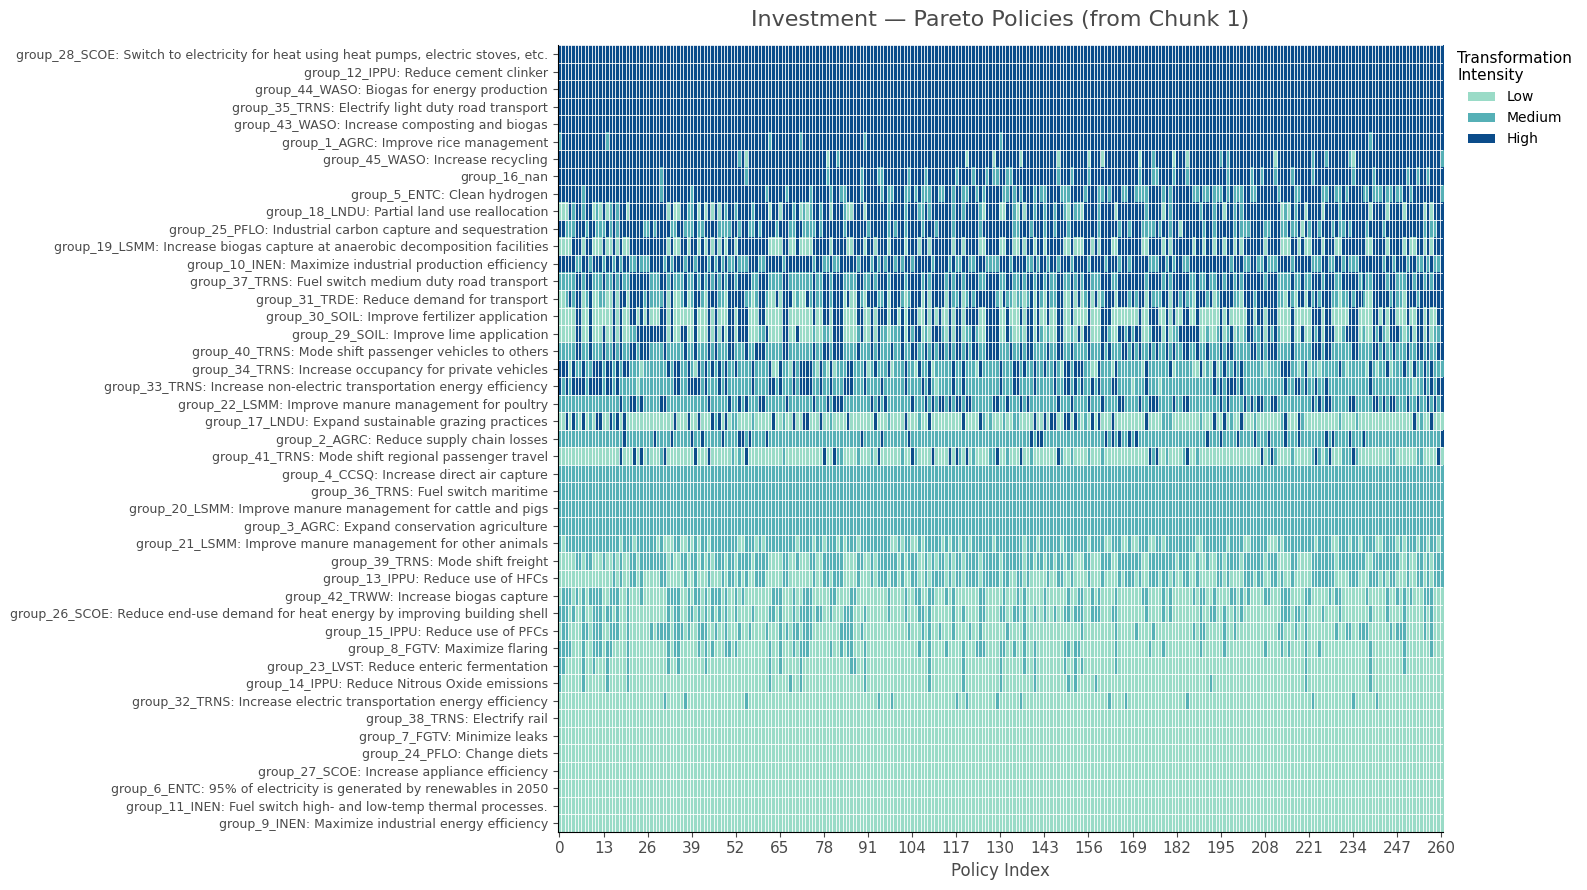

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'LowCarbon — Best Policy (from Chunk 1)': 45 levers × 1 policies.


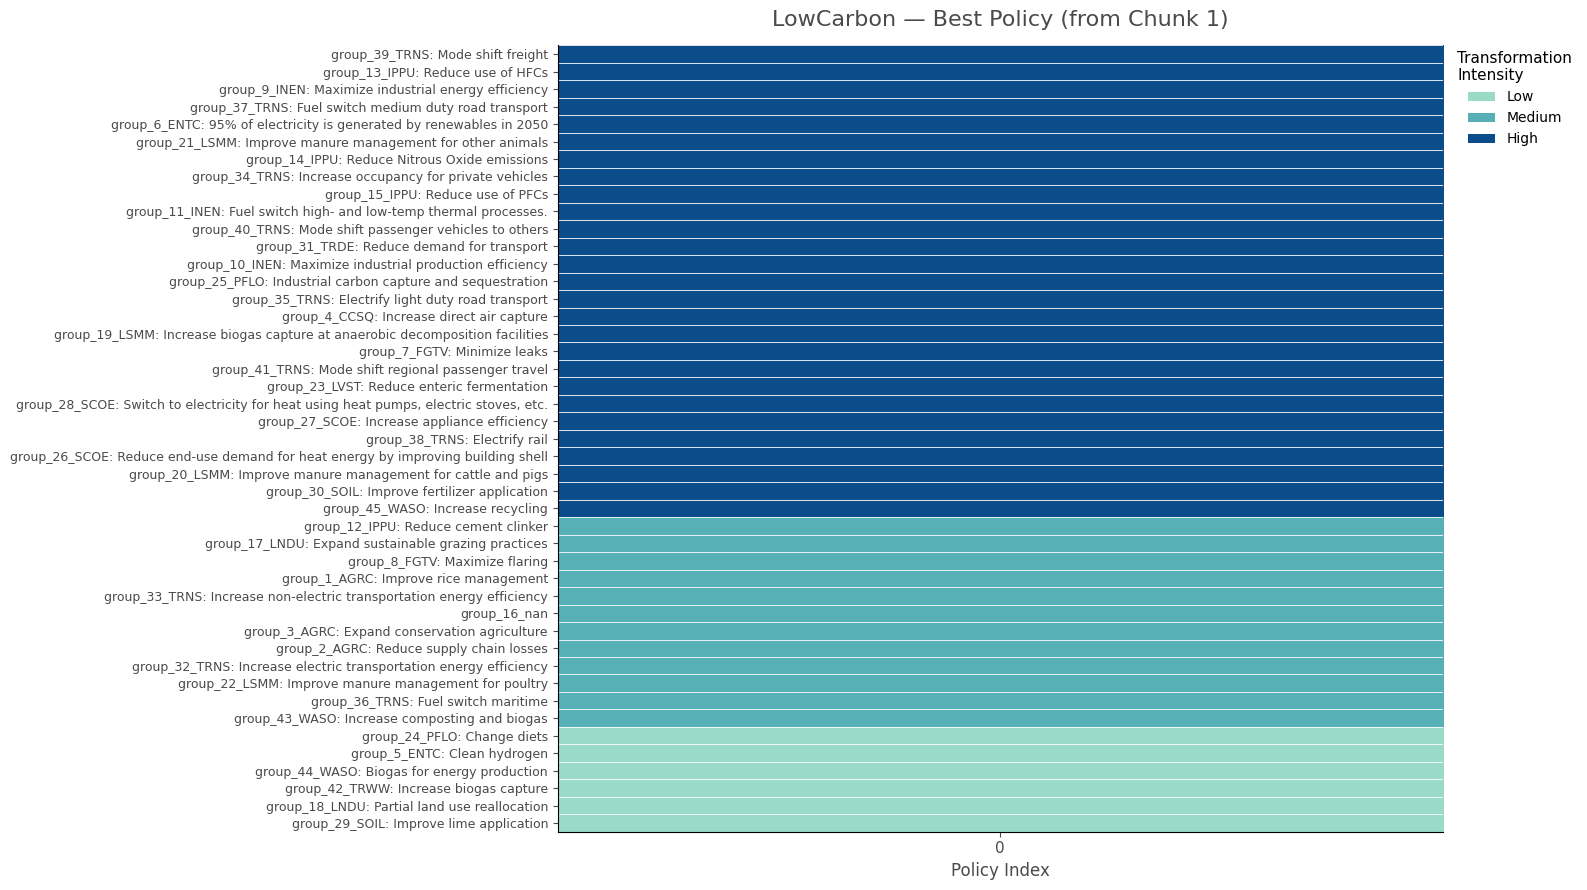

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'LowCarbon — Pareto Policies (from Chunk 1)': 45 levers × 300 policies.


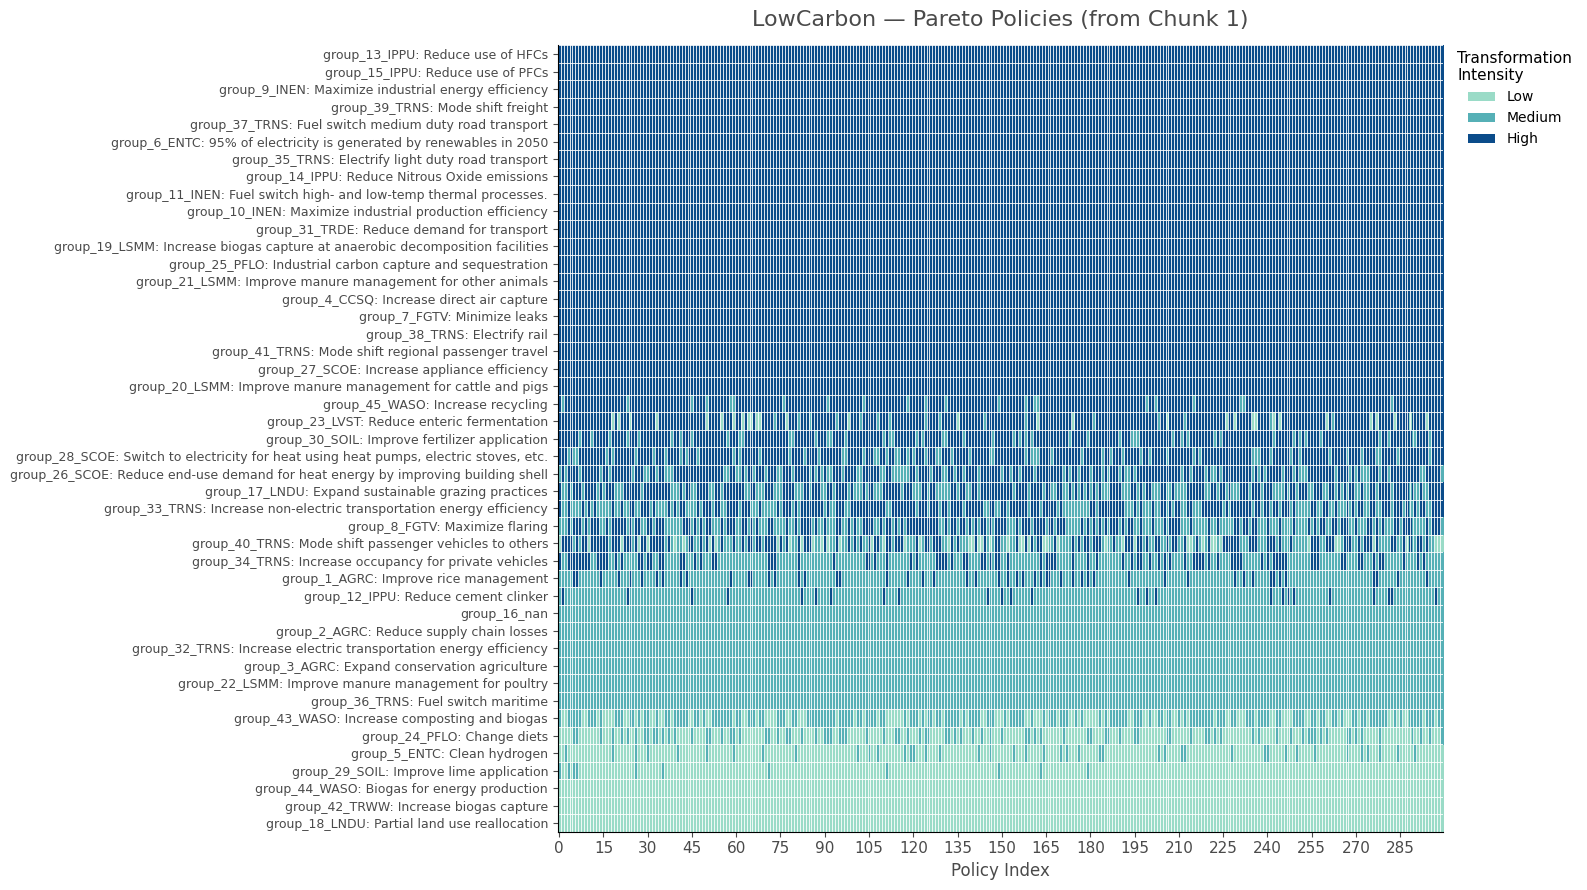

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'EconomicOpportunity — Best Policy (from Chunk 1)': 45 levers × 1 policies.


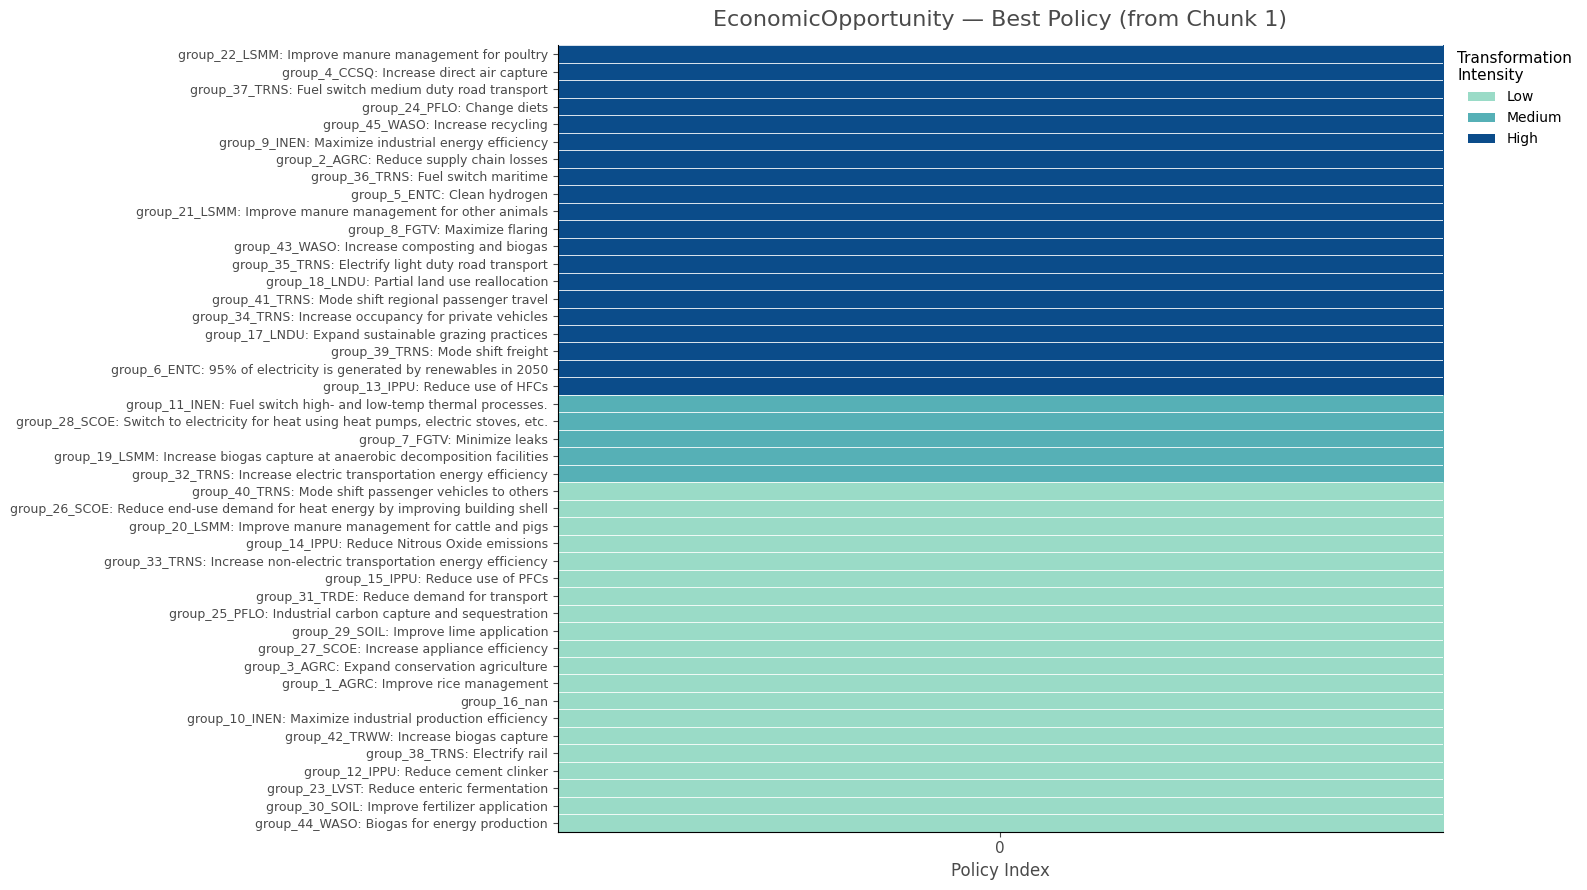

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'EconomicOpportunity — Pareto Policies (from Chunk 1)': 45 levers × 300 policies.


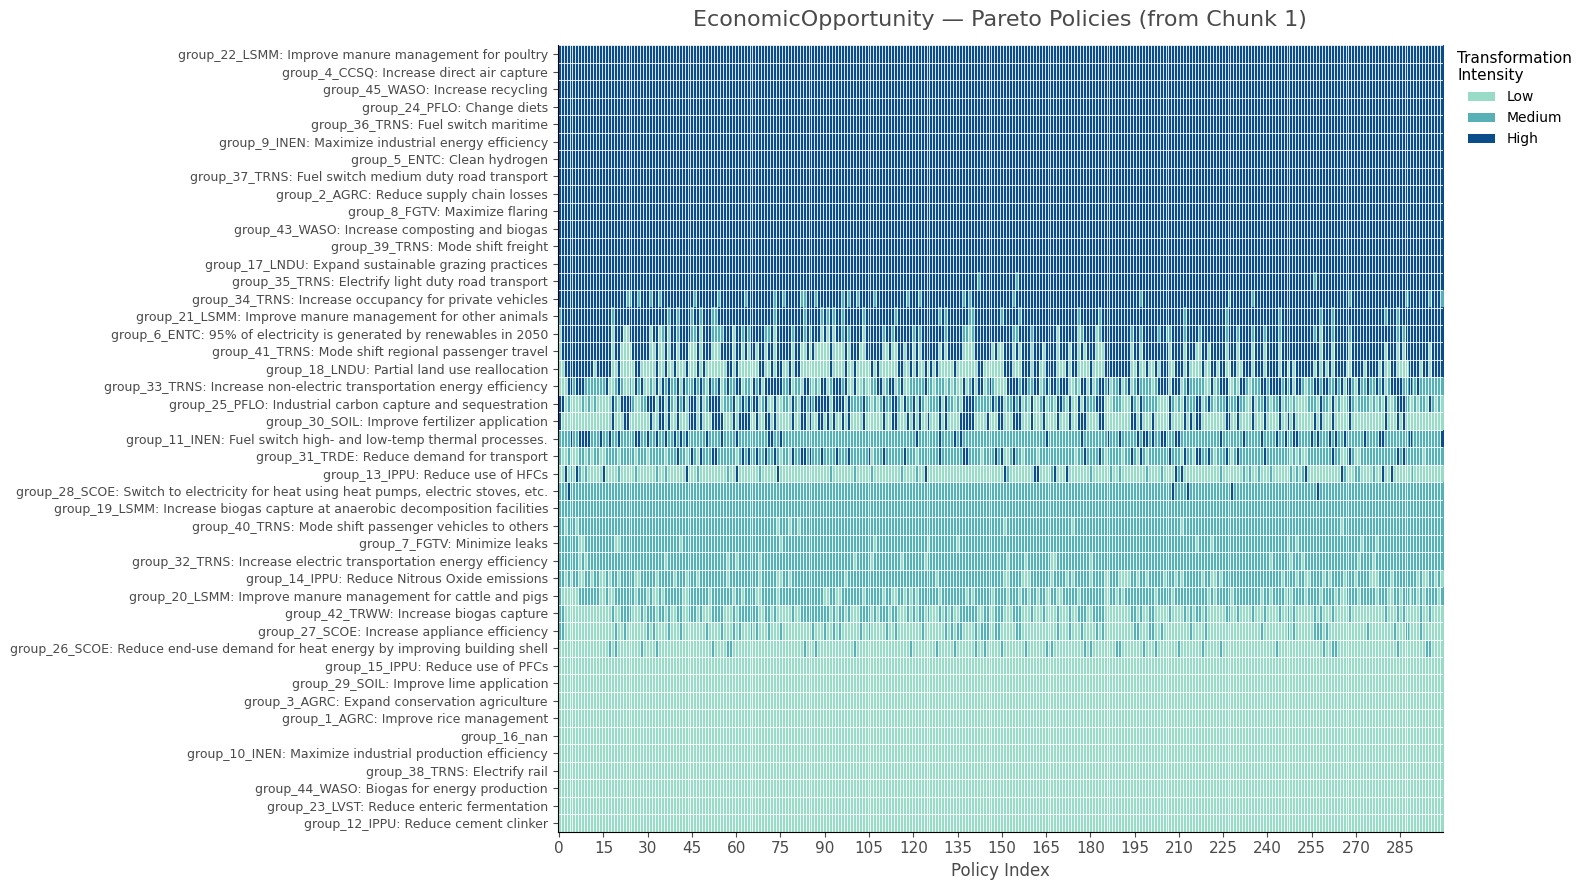

[heatmap] Using 45 lever cols with N < 46.
[heatmap] 'Global Multi-Objective — Pareto Policies (from Chunk 3)': 45 levers × 320 policies.


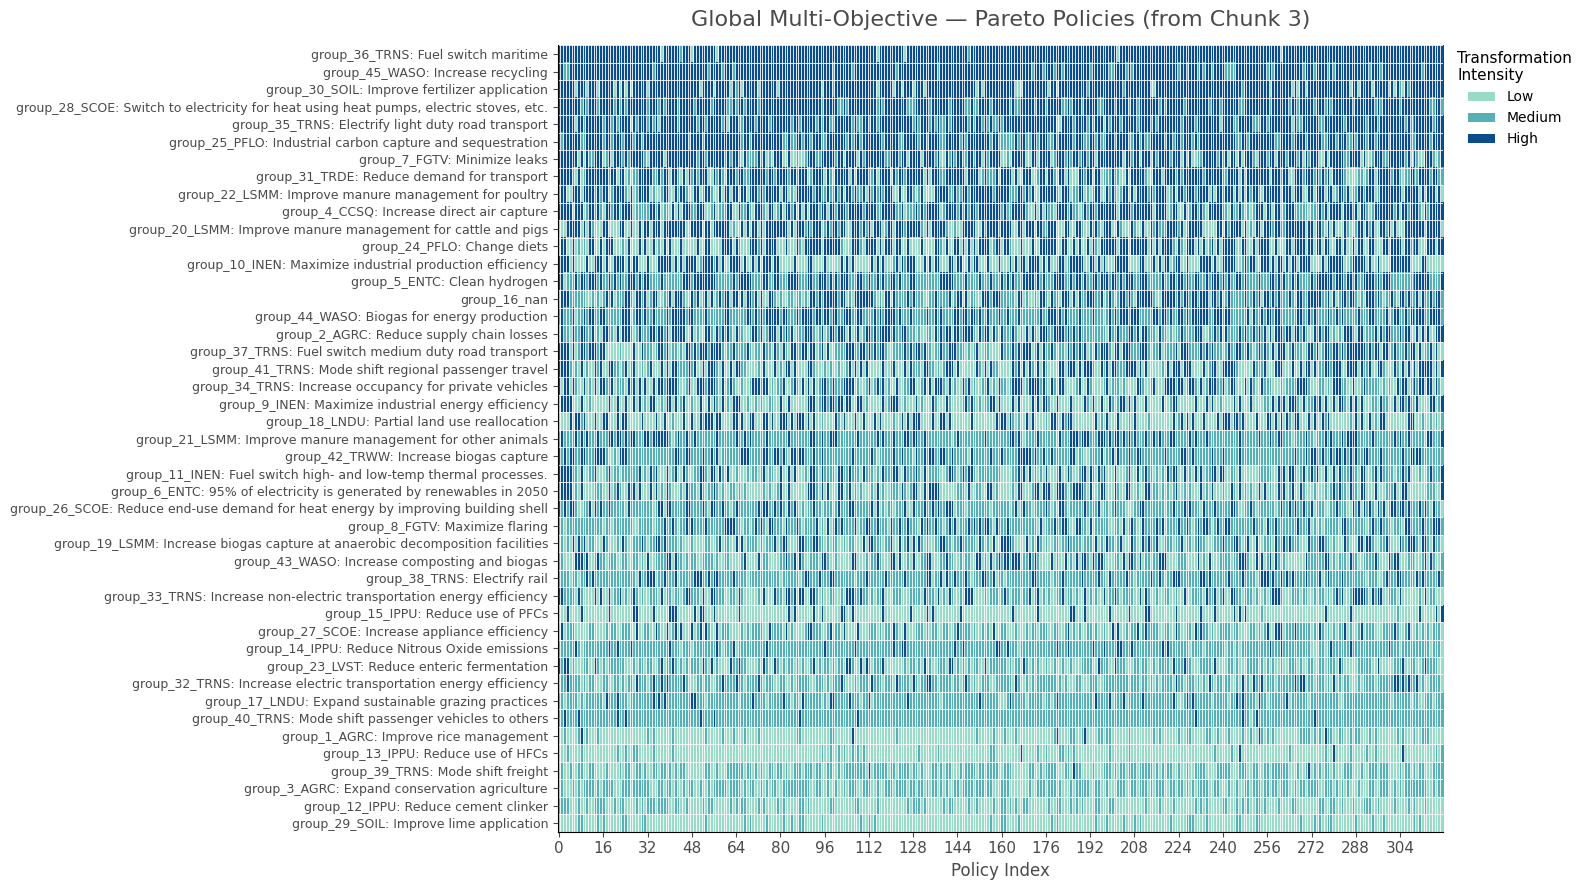

In [22]:
# =============================================================================
# Heatmaps for Lever Intensities across Policy Sets (with Friendly Labels ONLY)
# =============================================================================
# Purpose
# -------
# Produce quick, visual summaries of **lever intensities** (Low/Med/High bins)
# for multiple policy sets derived from the optimization workflow:
#
#   A) Consensus policies (agree_X), if available
#   B) Per-narrative BEST policy (one per narrative)
#   C) Per-narrative PARETO set (many per narrative)
#   D) Global Multi-Objective PARETO set from Chunk 3 (allobj_pareto_X)
#   E) (Optional) Global ALL-evaluations/history from Chunk 3 (allobj_all_evals)
#
# Notes on upstream optimization (context only):
#   • Per-narrative optimization used AGG_MODE="mean" and normalized per-objective
#     to [0,1] before selecting ONE best policy.
#   • Type-2 regret (unitless) was used for cross-evaluations & consensus filtering.
#
# Inputs expected in globals (if present):
#   - agree_X (pd.DataFrame): consensus policies
#   - best_policies_by_narrative (Dict[str, pd.DataFrame]): one-row best per narrative
#   - pareto_policies (Dict[str, pd.DataFrame]): multi-row Pareto per narrative
#   - allobj_pareto_X (pd.DataFrame): global Pareto (ALL objectives)
#   - allobj_all_evals (pd.DataFrame): optional global history/all-evals
#
# Friendly LABELS (no renaming):
#   - If available, we read:
#       • transformation_names_clean.csv    (transformation_code → name)
#       • VARIABLE_TRAJECTORY_GROUPS_L*.csv (variable_trajectory_group → code)
#     and build display labels "group_<id>_<friendly>" for the heatmap's y-axis.
#   - DataFrame column names are **never changed**.
#
# Other notes:
#   - Lever detection prefers columns "group_<N>" with N < 46 by default, but
#     falls back to any "group_*" columns if needed (tunable per call).
#   - Values are binned into Low/Medium/High (defaults: 0.25/0.75).
#   - Rows (levers) are ordered by High count, then Medium, then mean value.
# =============================================================================

# ----- Project paths (adjust if needed) --------------------------------------
import os
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")

# Example run id (only used for auto-locating mapping CSVs; safe to ignore)
run_id = "sisepuede_run_2025-10-14t00;19;25.886881"
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)

# ==============================================
# Heatmaps (self-contained, robust, with LABEL mapping)
# ==============================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from typing import List, Tuple, Dict, Optional

plt.rcParams["font.family"] = "DejaVu Sans"
TEXT_GRAY = "#4a4a4a"

# ---------- A) Mapping helpers (optional, used when available) ----------
def _build_map(t_src, g_src) -> Dict[int, str]:
    """
    Build a mapping {variable_trajectory_group -> friendly name} by joining:
      - Transformations table: transformation_code, transformation_name
      - Groups table: variable_trajectory_group, transformation_code
    The 'friendly name' is a cleaned transformation_name (prefix removed).
    """
    t = t_src if isinstance(t_src, pd.DataFrame) else pd.read_csv(str(t_src))
    if not {"transformation_code", "transformation_name"} <= set(t.columns):
        # Fallback if the first 2 columns are the mapping
        t = t.rename(columns={t.columns[0]: "transformation_code", t.columns[1]: "transformation_name"})

    g = g_src if isinstance(g_src, pd.DataFrame) else pd.read_csv(str(g_src))

    m = g.merge(t, on="transformation_code", how="left")
    m["name"] = (
        m["transformation_name"].astype(str)
        .str.replace(r"^Default Value -\s*", "", regex=True)
        .str.strip()
    )
    out = (
        m.dropna(subset=["name"])
         .drop_duplicates("variable_trajectory_group")
         .set_index("variable_trajectory_group")["name"]
         .to_dict()
    )
    # ensure int keys
    return {int(k): str(v) for k, v in out.items()}

def _maybe_get_group_to_name() -> Optional[Dict[int, str]]:
    """
    Try to obtain a {group_id -> friendly name} mapping from:
      1) globals() → group_to_name
      2) globals() → TRANSFORMATIONS_CSV & GROUPS_CSV
      3) SIMULATION_DIR_PATH inferred CSVs
    Return None if mapping cannot be built.
    """
    # 1) Pre-supplied mapping in globals
    if "group_to_name" in globals() and isinstance(group_to_name, dict) and group_to_name:
        return group_to_name

    # 2) Provided CSV paths in globals
    if "TRANSFORMATIONS_CSV" in globals() and "GROUPS_CSV" in globals():
        try:
            return _build_map(TRANSFORMATIONS_CSV, GROUPS_CSV)
        except Exception as e:
            print(f"[labels] Could not build mapping from provided CSVs: {e}")

    # 3) Auto-detect in SIMULATION_DIR_PATH
    try:
        if "SIMULATION_DIR_PATH" in globals():
            t_csv = os.path.join(SIMULATION_DIR_PATH, "transformation_names_clean.csv")
            g_csv_1 = os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv")
            g_csv_2 = os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L (1).csv")
            g_csv = g_csv_1 if os.path.exists(g_csv_1) else g_csv_2
            if os.path.exists(t_csv) and os.path.exists(g_csv):
                return _build_map(t_csv, g_csv)
    except Exception as e:
        print(f"[labels] Could not auto-build mapping: {e}")

    print("[labels] No group→name mapping available. Using raw suffixes for labels.")
    return None

# ---------- A.1) DISPLAY-LABEL HELPERS (NO column renaming) ----------
def _load_group_name_map_from_csvs(sim_dir: Optional[str] = None) -> Optional[Dict[int, str]]:
    """Light wrapper to allow explicit directory if needed."""
    if sim_dir is not None:
        globals()["SIMULATION_DIR_PATH"] = sim_dir
    return _maybe_get_group_to_name()

def _make_display_labels(lever_cols, group_to_name: Optional[Dict[int, str]] = None):
    """
    Build y-axis labels from existing column names WITHOUT renaming data:
      • Prefer "group_<id>_<friendly>" if mapping available for id
      • Else strip "group_<id>_" and use the remaining suffix
      • If suffix empty → use "group_<id>"
      • If duplicates remain → append " [<id>]" to only the colliding labels
    """
    from collections import Counter
    pat = re.compile(r"^group_(\d+)(?:_(.*))?$")

    ids, raw_suffixes = [], []
    for c in lever_cols:
        m = pat.match(str(c))
        if m:
            gid = int(m.group(1))
            suf = m.group(2) if m.group(2) else ""
        else:
            gid = None
            suf = str(c)
        ids.append(gid); raw_suffixes.append(suf)

    labels = []
    for gid, suf in zip(ids, raw_suffixes):
        if gid is not None and group_to_name and gid in group_to_name:
            labels.append(f"group_{gid}_{group_to_name[gid]}")
        else:
            labels.append(suf if suf else (f"group_{gid}" if gid is not None else str(suf)))

    cnt = Counter(labels)
    if any(v > 1 for v in cnt.values()):
        labels = [f"{lab} [{gid}]" if cnt[lab] > 1 and gid is not None else lab for lab, gid in zip(labels, ids)]

    return labels

# ---------- B) Heatmap helpers ----------
def _find_lever_cols(df: pd.DataFrame, prefer_max_idx_exclusive: int = 46) -> List[str]:
    """
    Detect lever columns. Prefer columns like 'group_<N>' with N < prefer_max_idx_exclusive
    (decision levers). Fallback to any 'group_*' columns if none match the preferred set.
    """
    cols = list(df.columns)
    rx_num = re.compile(r"^group_(\d+)(?:_|$)")
    with_num, plain_group = [], []
    for c in cols:
        m = rx_num.match(str(c))
        if m:
            n = int(m.group(1))
            if n < prefer_max_idx_exclusive:
                with_num.append(c)
        elif str(c).startswith("group_"):
            plain_group.append(c)

    if with_num:
        with_num.sort(key=lambda x: (int(rx_num.match(x).group(1)), x))
        print(f"[heatmap] Using {len(with_num)} lever cols with N < {prefer_max_idx_exclusive}.")
        return with_num

    if plain_group:
        plain_group.sort()
        print(f"[heatmap] No group_<N<{prefer_max_idx_exclusive}> found; falling back to {len(plain_group)} 'group_' columns.")
        return plain_group

    alt = [c for c in cols if str(c).startswith("group_")]
    if alt:
        alt.sort()
        print(f"[heatmap] Fallback: found {len(alt)} columns starting with 'group_'.")
        return alt

    print("[heatmap] No lever-like columns found (prefix 'group_').")
    return []

def _coerce_numeric_levers(df: pd.DataFrame, lever_cols: List[str]) -> pd.DataFrame:
    """Coerce lever columns to numeric (float32), filling NaNs with 0.0."""
    df = df.copy()
    for c in lever_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if lever_cols:
        before = df[lever_cols].isna().sum().sum()
        df[lever_cols] = df[lever_cols].fillna(0.0).astype("float32")
        after = df[lever_cols].isna().sum().sum()
        if before:
            print(f"[heatmap] Coerced {len(lever_cols)} levers; NaNs before={before}, after={after}.")
    return df

def _bin_low_med_high(values: np.ndarray, low_thr: float = 0.25, high_thr: float = 0.75) -> np.ndarray:
    """Bin lever values ∈[0,1] into {0:Low, 1:Med, 2:High} using thresholds."""
    vals = np.clip(values, 0.0, 1.0)
    bins = np.zeros_like(vals, dtype=int)             # Low
    bins[(vals >= low_thr) & (vals < high_thr)] = 1   # Med
    bins[vals >= high_thr] = 2                        # High
    return bins

def _order_rows_by_intensity(Z: np.ndarray, M: pd.DataFrame) -> np.ndarray:
    """Row ordering: High count ↓, then Medium count ↓, then mean value ↓."""
    high_cnt = (Z == 2).sum(axis=1)
    med_cnt  = (Z == 1).sum(axis=1)
    mean_val = M.to_numpy(dtype=float).mean(axis=1)
    return np.lexsort((-mean_val, -med_cnt, -high_cnt))

def plot_transformation_heatmap(
    policies_df: pd.DataFrame,
    title: str = "Transformations in Policies",
    low_thr: float = 0.25,
    high_thr: float = 0.75,
    figsize: Tuple[int, int] = (16, 9),
    prefer_max_idx_exclusive: int = 46,
):
    """
    Core heatmap renderer (no renaming):
      • Detect lever columns (prefer group_<N<46>).
      • Coerce lever columns to numeric and build matrix (levers × policies).
      • Bin values into Low/Med/High and order rows by intensity.
      • Build y-axis **display labels** from CSV mapping or raw suffixes.
      • Render heatmap with legend.
    """
    if not isinstance(policies_df, pd.DataFrame) or policies_df.empty:
        print(f"[heatmap] No data to plot for: {title}")
        return

    # 1) Detect lever columns
    lever_cols = _find_lever_cols(policies_df, prefer_max_idx_exclusive=prefer_max_idx_exclusive)
    if not lever_cols:
        print(f"[heatmap] Skipping '{title}': no lever columns found.")
        return

    # 2) Coerce numeric on lever columns only
    policies_df = _coerce_numeric_levers(policies_df, lever_cols)

    # 3) Build matrix (rows = levers, cols = policies)
    M = policies_df[lever_cols].T  # (n_levers, n_policies)
    print(f"[heatmap] '{title}': {M.shape[0]} levers × {M.shape[1]} policies.")

    # 4) Bin and order
    Z = _bin_low_med_high(M.to_numpy(dtype=float), low_thr=low_thr, high_thr=high_thr)
    order = _order_rows_by_intensity(Z, M)
    M = M.iloc[order, :]
    Z = Z[order, :]
    lever_cols_ordered = [lever_cols[i] for i in order]

    # 5) Row labels — build DISPLAY labels ONLY (no data renaming)
    group_to_name = _load_group_name_map_from_csvs()  # returns None if not found
    row_labels = _make_display_labels(lever_cols_ordered, group_to_name)

    # 6) Colormap and plot
    cmap = ListedColormap(["#9ADBC7", "#56B0B6", "#0B4C8A"])  # Low, Med, High
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(right=0.82)
    ax.imshow(Z, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

    ax.set_title(title, fontsize=16, pad=14, color=TEXT_GRAY)
    ax.set_xlabel("Policy Index", fontsize=12, color=TEXT_GRAY)
    ax.set_ylabel("", fontsize=12, color=TEXT_GRAY)

    n_pols = Z.shape[1]
    step = max(1, n_pols // 20)
    ax.set_xticks(np.arange(0, n_pols, step))
    ax.set_xticklabels(np.arange(n_pols)[::step], rotation=0, color=TEXT_GRAY)

    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9, color=TEXT_GRAY)

    ax.tick_params(axis="x", colors=TEXT_GRAY)
    ax.tick_params(axis="y", colors=TEXT_GRAY)
    ax.set_xticks(np.arange(-0.5, n_pols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    legend_elems = [
        Patch(facecolor=cmap(0), edgecolor="none", label="Low"),
        Patch(facecolor=cmap(1), edgecolor="none", label="Medium"),
        Patch(facecolor=cmap(2), edgecolor="none", label="High"),
    ]
    ax.legend(
        handles=legend_elems,
        title="Transformation\nIntensity",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        frameon=False,
        title_fontsize=11,
    )

    plt.tight_layout()
    plt.show()

def _plot_heatmap_for(df_policies: pd.DataFrame, title: str,
                      low_thr: float = 0.25, high_thr: float = 0.75,
                      prefer_max_idx_exclusive: int = 46,
                      rename_if_possible: bool = True):
    """
    Wrapper around the renderer. NOTE: We no longer rename columns here.
    The 'rename_if_possible' arg is ignored and kept only for backward compat.
    """
    if not isinstance(df_policies, pd.DataFrame) or df_policies.empty:
        print(f"[heatmap] No policies for: {title}")
        return
    plot_transformation_heatmap(
        df_policies,
        title=title,
        low_thr=low_thr,
        high_thr=high_thr,
        figsize=(16, 9),
        prefer_max_idx_exclusive=prefer_max_idx_exclusive,
    )

# ---------- C) Pick data sources (consensus + narrative best/pareto) ----------
# CONSENSUS
_consensus_df = None
if "agree_X_renamed" in globals() and isinstance(agree_X_renamed, pd.DataFrame) and not agree_X_renamed.empty:
    _consensus_df = agree_X_renamed
elif "agree_X" in globals() and isinstance(agree_X, pd.DataFrame) and not agree_X.empty:
    _consensus_df = agree_X

def _pick_best_df(name: str) -> Optional[pd.DataFrame]:
    """Return the best policy DF for a given narrative name."""
    if "renamed_best_policies_by_narrative" in globals():
        df = renamed_best_policies_by_narrative.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    if "best_policies_by_narrative" in globals():
        df = best_policies_by_narrative.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    return None

def _pick_pareto_df(name: str) -> Optional[pd.DataFrame]:
    """Return the Pareto policies DF for a given narrative name."""
    if "renamed_pareto_policies" in globals():
        df = renamed_pareto_policies.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    if "pareto_policies" in globals():
        df = pareto_policies.get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    return None

# Narrative names
if "narratives_cfg" in globals() and isinstance(narratives_cfg, dict) and narratives_cfg:
    _narr_names = list(narratives_cfg.keys())
else:
    _narr_names = ["IndustryEnergyInvestment", "EmissionsReduction", "PlaceToLive"]

# ---------- C.1) Add GLOBAL (all-objectives) Pareto heatmap -------------------
def _pick_global_pareto_df() -> Optional[pd.DataFrame]:
    """Prefer renamed global Pareto if present; else use allobj_pareto_X."""
    if "renamed_allobj_pareto_X" in globals():
        df = globals().get("renamed_allobj_pareto_X")
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    if "allobj_pareto_X" in globals():
        df = globals().get("allobj_pareto_X")
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df
    return None

# ================= RUN: Heatmaps =================

# A) CONSENSUS policies
if _consensus_df is not None:
    _plot_heatmap_for(
        _consensus_df,
        title="Consensus Policies — Lever Intensities (Low/Med/High)",
        rename_if_possible=True
    )
else:
    print("[heatmap] Skipped consensus heatmap: no consensus DataFrame found.")

# B–C) Each narrative: best + Pareto
for name in _narr_names:
    best_df = _pick_best_df(name)
    if best_df is not None:
        _plot_heatmap_for(best_df, title=f"{name} — Best Policy (from Chunk 1)", rename_if_possible=True)
    else:
        print(f"[heatmap] Skipped best policy heatmap for '{name}': not found or empty.")

    pareto_df = _pick_pareto_df(name)
    if pareto_df is not None:
        _plot_heatmap_for(pareto_df, title=f"{name} — Pareto Policies (from Chunk 1)", rename_if_possible=True)
    else:
        print(f"[heatmap] Skipped Pareto heatmap for '{name}': not found or empty.")

# D) Global Multi-Objective PARETO (Chunk 3)
_global_pareto_df = _pick_global_pareto_df()
if _global_pareto_df is not None:
    _plot_heatmap_for(
        _global_pareto_df,
        title="Global Multi-Objective — Pareto Policies (from Chunk 3)",
        rename_if_possible=True
    )
else:
    print("[heatmap] Skipped global (all-objectives) Pareto heatmap: allobj_pareto_X not found or empty.")

# # E) (Optional) GLOBAL history/all-evals heatmap (can be large)
# if "allobj_all_evals" in globals():
#     _df_hist = globals().get("allobj_all_evals")
#     if isinstance(_df_hist, pd.DataFrame) and not _df_hist.empty:
#         _plot_heatmap_for(
#             _df_hist,
#             title="Global Multi-Objective — ALL Evaluated Candidates (from Chunk 3)",
#             rename_if_possible=True
#         )
#     else:
#         print("[heatmap] Skipped global ALL-evals heatmap: empty or not a DataFrame.")
# else:
#     print("[heatmap] Skipped global ALL-evals heatmap: allobj_all_evals not in globals.")


In [23]:
# =============================================================================
# Lever Intensity Uplift vs Background — Robust Effect Sizes + Pretty Plot
# =============================================================================
# What this provides
# ------------------
# compare_lever_intensity_uplift(selected_df, background_df, ...)
#   → returns (stats_df, fig)
#
# • Detects lever columns (group_<N>), preferring N < 46 by default.
# • Scales to [0,1] jointly across selected ∪ background (or uses raw scale).
# • Computes standardized mean difference (SMD):
#       - Cohen’s d (pooled SD) if both groups have n≥2
#       - Glass’s Δ (uses background SD) if either group has n<2
#   This avoids "d = 0" when selected_df is a single policy.
# • Nonparametric Mann–Whitney U p-values (significance dots: • / •• / •••).
# • Ranks by signed effect (largest → smallest), inverts Y to show largest on top.
# • Filters NaN / tiny effects; optional fallback to rank by abs_delta or rel_delta.
# • Friendly labels if your helpers exist; otherwise robust fallback labels.
#
# Typical uses
# ------------
# 1) Consensus vs all global evaluations:
#    compare_lever_intensity_uplift(agree_X, allobj_all_evals, ...)
# 2) Narrative BEST vs that narrative’s ALL evaluated:
#    compare_lever_intensity_uplift(best_policies_by_narrative[name],
#                                   evaluated_candidates_by_narrative[name], ...)
#
# Notes
# -----
# - This code never renames your DataFrame columns; it only formats labels.
# - prefer_max_idx_exclusive controls which group_<id> are considered "levers".
#   Set very high (e.g., 10**9) to include exogenous if you wish.
# =============================================================================

import numpy as np
import pandas as pd
import re
from typing import List, Optional

# ---------- Lever detection / coercion ----------
def _detect_lever_cols(df: pd.DataFrame, prefer_max_idx_exclusive: int = 46) -> List[str]:
    """Prefer columns like 'group_<N>' with N < prefer_max_idx_exclusive; else fall back to any 'group_*'."""
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    with_num, plain = [], []
    for c in df.columns:
        m = rx.match(str(c))
        if m:
            n = int(m.group(1))
            if n < prefer_max_idx_exclusive:
                with_num.append(c)
        elif str(c).startswith("group_"):
            plain.append(c)
    if with_num:
        with_num.sort(key=lambda x: (int(rx.match(x).group(1)), x))
        return with_num
    if plain:
        plain.sort()
        return plain
    # last resort
    return [c for c in df.columns if str(c).startswith("group_")]

def _coerce_numeric(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out[cols] = out[cols].fillna(0.0).astype("float32")
    return out

# ---------- Labels (use your helpers if present; else robust fallback) ----------
def _build_display_labels(cols: List[str]) -> List[str]:
    """
    If your heatmap helpers exist, reuse them:
      _make_display_labels(cols, _load_group_name_map_from_csvs())
    Otherwise:
      - strip 'group_<id>_' → suffix; if empty, use 'group_<id>'
      - disambiguate duplicates by appending ' [<id>]'
    """
    if "_make_display_labels" in globals():
        try:
            gmap = None
            if "_load_group_name_map_from_csvs" in globals():
                gmap = _load_group_name_map_from_csvs()
            return _make_display_labels(cols, gmap)
        except Exception:
            pass

    rx = re.compile(r"^group_(\d+)(?:_(.*))?$")
    ids, labels = [], []
    for c in cols:
        m = rx.match(str(c))
        if m:
            gid = int(m.group(1))
            suf = (m.group(2) or "").strip()
            ids.append(gid)
            labels.append(suf if suf else f"group_{gid}")
        else:
            ids.append(None)
            labels.append(str(c).strip() or "unknown")

    # disambiguate duplicates
    from collections import Counter
    cnt = Counter(labels)
    if any(v > 1 for v in cnt.values()):
        labels = [f"{lab} [{gid}]" if cnt[lab] > 1 and gid is not None else lab
                  for lab, gid in zip(labels, ids)]
    return labels

# ---------- Effect sizes ----------
def _safe_rel_delta(mu_sel: float, mu_bg: float, eps: float = 1e-12) -> float:
    denom = mu_bg if abs(mu_bg) > eps else eps
    return (mu_sel - mu_bg) / denom

def _smd_effect(x: np.ndarray, y: np.ndarray, eps: float = 1e-12) -> float:
    """
    Standardized Mean Difference (SMD) with robust fallback.
    • If both groups have n>=2 → Cohen’s d (pooled SD).
    • Else → Glass’s Δ using background SD (y) as denominator.
    Sign convention: positive → selected (x) > background (y).
    """
    nx, ny = len(x), len(y)
    mx, my = float(np.nanmean(x)), float(np.nanmean(y))
    sx = float(np.nanstd(x, ddof=1)) if nx >= 2 else float("nan")
    sy = float(np.nanstd(y, ddof=1)) if ny >= 2 else float("nan")

    # Cohen's d when both SDs are available
    if nx >= 2 and ny >= 2:
        sp2 = ((nx - 1) * (sx ** 2) + (ny - 1) * (sy ** 2)) / max(nx + ny - 2, 1)
        sp = np.sqrt(max(sp2, 0.0))
        denom = sp if sp > eps else eps
        return (mx - my) / denom

    # Otherwise Glass's Δ using background SD
    denom = sy if (not np.isnan(sy) and sy > eps) else eps
    return (mx - my) / denom

def _mannwhitney_p(x: np.ndarray, y: np.ndarray) -> float:
    """Two-sided Mann–Whitney U p-value; returns NaN if scipy not available."""
    try:
        from scipy.stats import mannwhitneyu
        res = mannwhitneyu(x, y, alternative="two-sided", method="auto")
        return float(res.pvalue)
    except Exception:
        return float("nan")

# ---------- Ranking helper ----------
def _rank_and_mark(df: pd.DataFrame, p_col: str = "p_value", *, rank_by: str = "cohens_d", descending: bool = True) -> pd.DataFrame:
    """Add significance dots and sort by a chosen metric (default: signed Cohen’s d)."""
    def stars(p):
        if pd.isna(p): return ""
        if p < 1e-3: return "•••"
        if p < 1e-2: return "••"
        if p < 5e-2: return "•"
        return ""
    out = df.copy()
    out["signif"] = out[p_col].apply(stars)
    key = rank_by if rank_by in out.columns else "cohens_d"
    out = out.sort_values(key, ascending=not descending, kind="mergesort").reset_index(drop=True)
    return out

# ---------- Main API ----------
def compare_lever_intensity_uplift(
    selected_df: pd.DataFrame,
    background_df: pd.DataFrame,
    *,
    prefer_max_idx_exclusive: int = 46,
    top_k: int = 25,
    title: str = "Lever Intensity — Selected vs Background (Effect Size Ranking)",
    return_fig: bool = True,
    min_effect_for_plot: float = 1e-4,            # filter threshold for |effect|
    fallback_rank_if_all_zero: str = "abs_delta", # "abs_delta" or "rel_delta"
    compute_on_scaled: bool = True,               # True: joint [0,1]; False: raw
):
    """
    Compare lever intensities between 'selected' and 'background' sets and plot TOP-K effects.

    Returns
    -------
    stats_ranked : pd.DataFrame
        Columns: ['lever','label','mean_selected','mean_background','abs_delta',
                  'rel_delta','cohens_d','abs_d','p_value','signif']
        Sorted by the plotting metric (Cohen’s d by default).
    fig : matplotlib.figure.Figure or None
        The figure object if plotted; None if return_fig=False or nothing to plot.
    """
    assert isinstance(selected_df, pd.DataFrame) and isinstance(background_df, pd.DataFrame)

    # 1) Overlapping lever columns
    sel_cols = _detect_lever_cols(selected_df, prefer_max_idx_exclusive=prefer_max_idx_exclusive)
    bg_cols  = _detect_lever_cols(background_df, prefer_max_idx_exclusive=prefer_max_idx_exclusive)
    lever_cols = [c for c in sel_cols if c in bg_cols]
    if not lever_cols:
        raise ValueError("No overlapping lever columns found between selected_df and background_df.")

    # 2) Coerce numeric
    S = _coerce_numeric(selected_df[lever_cols], lever_cols)
    B = _coerce_numeric(background_df[lever_cols], lever_cols)

    # 2.1) Choose scale
    if compute_on_scaled:
        joint_min = np.nanmin(np.vstack([S.to_numpy(), B.to_numpy()]), axis=0)
        joint_max = np.nanmax(np.vstack([S.to_numpy(), B.to_numpy()]), axis=0)
        denom = np.maximum(joint_max - joint_min, 1e-12)
        S_use = (S.to_numpy() - joint_min) / denom
        B_use = (B.to_numpy() - joint_min) / denom
    else:
        S_use = S.to_numpy()
        B_use = B.to_numpy()

    # 3) Stats per lever
    rows = []
    for j, c in enumerate(lever_cols):
        xs, ys = S_use[:, j], B_use[:, j]
        mu_sel = float(np.nanmean(xs)); mu_bg = float(np.nanmean(ys))
        delta = mu_sel - mu_bg
        rel = _safe_rel_delta(mu_sel, mu_bg)
        d = _smd_effect(xs, ys)                # <-- robust effect size (Cohen/Glass)
        p = _mannwhitney_p(xs, ys)
        rows.append({
            "lever": c,
            "mean_selected": mu_sel,
            "mean_background": mu_bg,
            "abs_delta": delta,
            "rel_delta": rel,
            "cohens_d": d,
            "abs_d": abs(d),
            "p_value": p,
        })
    stats = pd.DataFrame(rows)

    # 4) Friendly labels
    labels = _build_display_labels(lever_cols)
    stats = stats.merge(pd.DataFrame({"lever": lever_cols, "label": labels}),
                        on="lever", how="left")

    # 5) Rank by signed Cohen/Glass effect
    stats_ranked = _rank_and_mark(stats, rank_by="cohens_d", descending=True)

    # 5.1) Filter tiny/NaN effects (avoid blank lines)
    stats_nonzero = stats_ranked.dropna(subset=["cohens_d"])
    stats_nonzero = stats_nonzero[stats_nonzero["cohens_d"].abs() > min_effect_for_plot].copy()

    # 5.2) Fallback if everything ~0: rank by mean difference
    used_metric = "cohens_d"
    if stats_nonzero.empty and fallback_rank_if_all_zero in {"abs_delta", "rel_delta"}:
        used_metric = fallback_rank_if_all_zero
        stats_ranked = _rank_and_mark(stats, rank_by=used_metric, descending=True)
        thr = 1e-6 if used_metric == "abs_delta" else 1e-4
        stats_nonzero = stats_ranked[stats_ranked[used_metric].abs() > thr].copy()

    # 6) Plot
    fig = None
    if return_fig:
        import matplotlib.pyplot as plt
        top = stats_nonzero.head(int(top_k)).copy()
        if top.empty:
            print("[plot] Nothing to plot: all effects below threshold "
                  f"(metric={used_metric}, min={min_effect_for_plot}). "
                  "Try lowering min_effect_for_plot, include more levers "
                  "or set compute_on_scaled=False.")
            return stats_ranked, None

        # significance dots appended to labels
        top["label_plot"] = np.where(top.get("signif", "") != "",
                                     top["label"] + "  " + top["signif"],
                                     top["label"])

        fig, ax = plt.subplots(figsize=(12, max(6, 0.4 * len(top))))
        xvals = top[used_metric] if used_metric != "cohens_d" else top["cohens_d"]
        ax.barh(top["label_plot"], xvals)
        ax.axvline(0.0)
        ttl_suffix = "" if used_metric == "cohens_d" else f"  (ranked by {used_metric})"
        ax.set_title(title + ttl_suffix)
        ax.set_xlabel("Cohen's d / Glass's Δ (effect size)\n"
                      "(>0 = Selected > Background; <0 = Selected < Background)"
                      if used_metric == "cohens_d"
                      else f"{used_metric} (selected − background)")
        ax.set_ylabel("Lever")
        ax.invert_yaxis()  # largest effect at the top
        plt.tight_layout()
        plt.show()

    return stats_ranked, fig


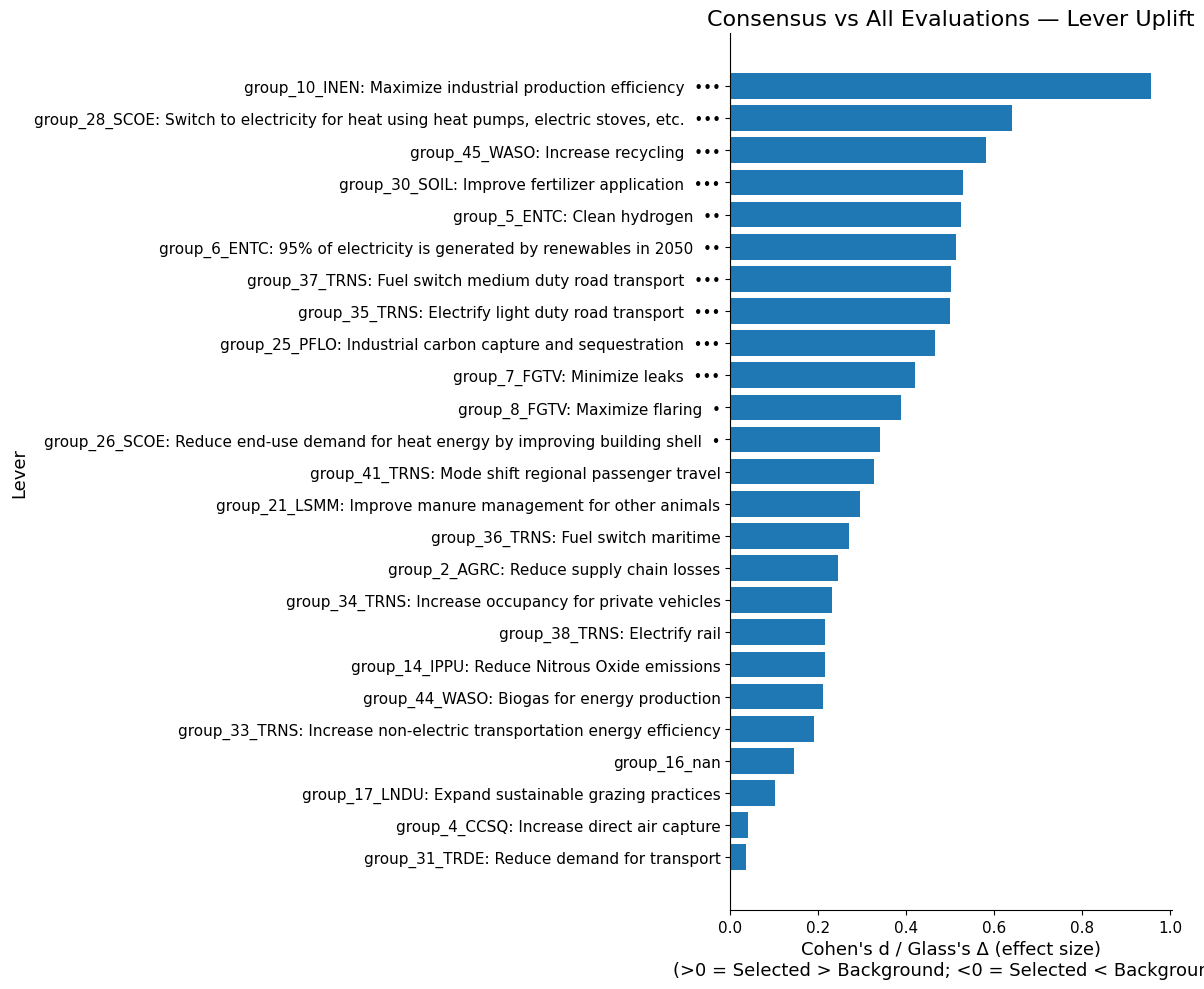

,lever,mean_selected,mean_background,abs_delta,rel_delta,cohens_d,abs_d,p_value,label,signif
0,group_10_scalar_inen_energy_demand,0.934159,0.553671,0.380488,0.687211,0.956186,0.956186,1.367765e-09,group_10_INEN: Maximize industrial production ...,•••
1,group_28_frac_scoe_heat_energy,0.870582,0.714409,0.156173,0.218605,0.641588,0.641588,5.460168e-07,group_28_SCOE: Switch to electricity for heat ...,•••
2,group_45_frac_waso_recycled,0.905766,0.758627,0.147140,0.193955,0.581269,0.581269,7.833808e-05,group_45_WASO: Increase recycling,•••
3,group_30_demscalar_soil_fertilizer_n_per_area,0.819559,0.617586,0.201973,0.327036,0.529889,0.529889,1.387968e-05,group_30_SOIL: Improve fertilizer application,•••
4,group_5_nemomod_entc_frac_min_share_production...,0.765924,0.633352,0.132571,0.209317,0.525189,0.525189,1.602349e-03,group_5_ENTC: Clean hydrogen,••
5,group_6_nemomod_en,0.625909,0.431759,0.194150,0.449671,0.512641,0.512641,2.995806e-03,group_6_ENTC: 95% of electricity is generated ...,••
6,group_37_frac_trns_fuelmix,0.732093,0.568642,0.163451,0.287441,0.501203,0.501203,2.809643e-04,group_37_TRNS: Fuel switch medium duty road tr...,•••
7,group_35_frac_trns_fuelmix_road_light,0.823699,0.686372,0.137327,0.200077,0.500669,0.500669,3.858052e-05,group_35_TRNS: Electrify light duty road trans...,•••
8,group_25_frac_ippu_production_with_co2_capture,0.885947,0.772302,0.113645,0.147151,0.466535,0.466535,1.737018e-05,group_25_PFLO: Industrial carbon capture and s...,•••
9,group_7_,0.793244,0.654552,0.138692,0.211888,0.419879,0.419879,6.621075e-04,group_7_FGTV: Minimize leaks,•••


In [24]:
# Example background = all global evals minus consensus rows (if indices overlap)
bg = allobj_all_evals
sel = agree_X
stats_con, fig = compare_lever_intensity_uplift(
    selected_df=sel,
    background_df=bg,
    prefer_max_idx_exclusive=46,  # only decision levers
    top_k=25,
    title="Consensus vs All Evaluations — Lever Uplift"
)
stats_con.head(20)


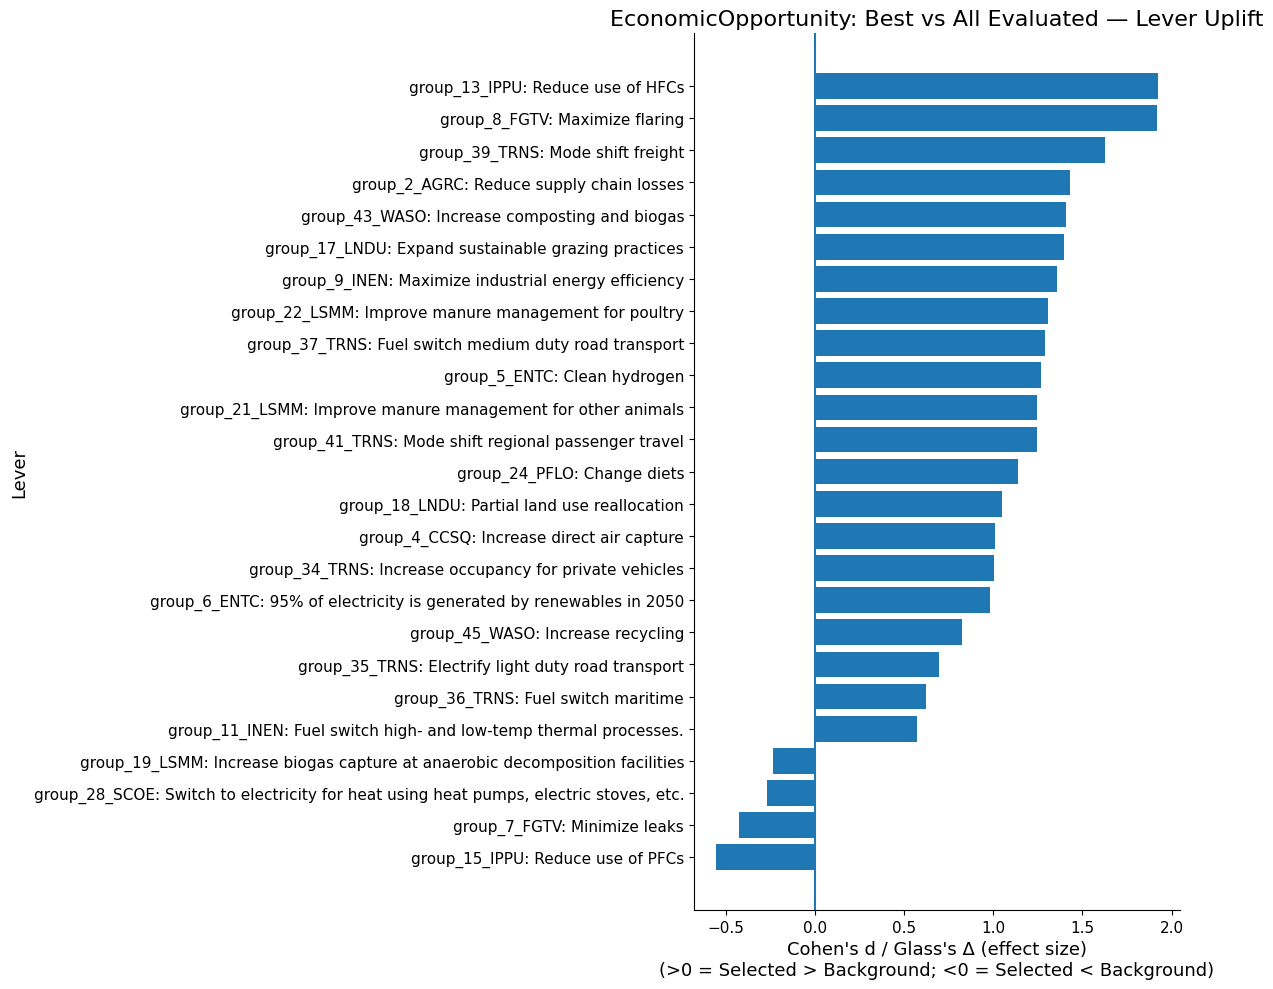

In [30]:
# Example: uplift for one narrative
name = "EconomicOpportunity"

selected_df  = best_policies_by_narrative[name]                   # 1-row best
#background_df = evaluated_candidates_by_narrative[name]           # ALL evaluated (history/fallback)
background_df = allobj_all_evals
stats_ie, fig_ie = compare_lever_intensity_uplift(
    selected_df=selected_df,
    background_df=background_df,
    prefer_max_idx_exclusive=46,   # only decision levers
    top_k=25,
    title=f"{name}: Best vs All Evaluated — Lever Uplift"
)



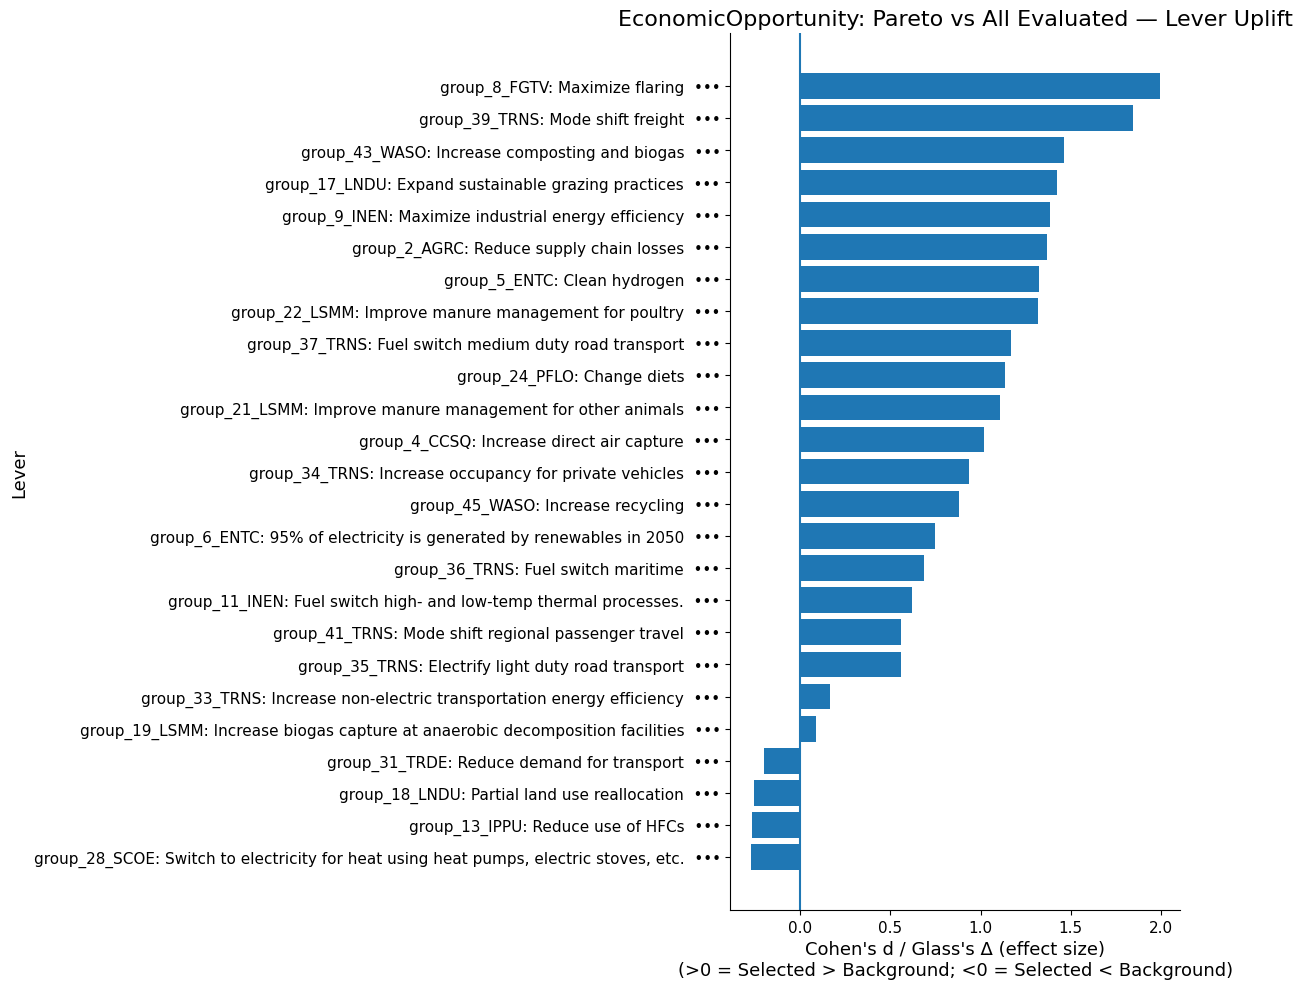

In [29]:
name = "EconomicOpportunity"

selected_df   = pareto_policies[name]                 # << Pareto set
#background_df = evaluated_candidates_by_narrative[name]  # all evaluated (history/fallback)
background_df = allobj_all_evals
stats_ie, fig_ie = compare_lever_intensity_uplift(
    selected_df=selected_df,
    background_df=background_df,
    prefer_max_idx_exclusive=46,   # only decision levers (<46). raise to include exogenous
    top_k=25,
    title=f"{name}: Pareto vs All Evaluated — Lever Uplift"
)


## Parallel axes plots

In [4]:
# === Chunk 0 (MINIMAL) — Paths, labels/colors, baselines, metrics order, and deferred range stack ===
from pathlib import Path
import pandas as pd

# ---- Sanity: rely on objects created by your optimization code ----
_required = [
    "pipeline", "train_metrics", "SCENARIOS", "narratives_cfg",
    "best_policies_by_narrative", "evaluated_candidates_by_narrative"
]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError(f"[Chunk 0 minimal] Missing globals from earlier code: {_missing}")

# ---- Output folders (don’t overwrite if already set) ----
if "PDF_ABS_DIR" not in globals():
    PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")
if "FIGS_PNG_DIR" not in globals():
    FIGS_PNG_DIR = PDF_ABS_DIR / "figs_png"
if "FIGS_PDF_DIR" not in globals():
    FIGS_PDF_DIR = PDF_ABS_DIR / "figs_pdf"
FIGS_PNG_DIR.mkdir(parents=True, exist_ok=True)
FIGS_PDF_DIR.mkdir(parents=True, exist_ok=True)

# ---- Baselines (optional subtraction in axis labels) ----
BASELINE_ON = globals().get("BASELINE_ON", False)
BASELINES = globals().get("BASELINES", {
    "production_total":      1.269096e+09,
    "production_cost_total": 1.888108e+10,
})

# ---- Regret percentile (used by reduction across futures) ----
REGRET_PERCENTILE = globals().get("REGRET_PERCENTILE", 75.0)

# ---- Pretty labels (kept minimal; won’t overwrite if provided) ----
label_map = globals().get("label_map", {
    "emission_total": "Total Emissions",
    "emission_avg_last_five_years": "Emissions (5-yr avg)",
    "production_total": "Total Production",
    "production_cost_total": "Production Cost",
    "air_pollution": "Air Pollution (benefit)",
    "num_jobs": "Number of jobs",
    "earning_per_job": "Average earning per job",
})

# ---- Policy colors (won’t overwrite if provided) ----
colors_by_policy = globals().get("colors_by_policy", {
    "Investment": "#FFC145",
    "LowCarbon": "#E76F51",
    "EconomicOpportunity": "#4D9DE0",
})

# ---- Metrics order + senses derived from your narratives_cfg (only if missing) ----
def _collect_objectives_and_senses(ncfg: dict[str, list[tuple[str, str]]]):
    senses = {}
    for _, pairs in ncfg.items():
        for m, s in pairs:
            senses[m] = s.lower()
    preferred = [
        "emission_avg_last_five_years",
        "emission_total",
        "production_total",
        "production_cost_total",
        "air_pollution",
        "num_jobs",
        "earning_per_job",
    ]
    # Keep only those present in both train_metrics and senses
    present = [m for m in preferred if (m in senses and m in train_metrics)]
    # Append any remaining sensed metrics that are in train_metrics
    for m in senses:
        if m not in present and m in train_metrics:
            present.append(m)
    return present, {m: senses[m] for m in present}

if "metrics7" not in globals() or "sense_by_obj7" not in globals():
    metrics7, sense_by_obj7 = _collect_objectives_and_senses(narratives_cfg)
else:
    # keep user-provided versions intact
    metrics7 = globals()["metrics7"]; sense_by_obj7 = globals()["sense_by_obj7"]

# ---- Optional overlays discovered if present (don’t error if missing) ----
_has_pareto = ("pareto_policies" in globals()) and isinstance(globals()["pareto_policies"], dict)
agree_X_renamed = globals().get("agree_X_renamed", pd.DataFrame())
agree_X = globals().get("agree_X", pd.DataFrame())

# ---- Defer GLOBAL_RANGE_STACK until Chunk 1 helpers exist ---------------------
# This uses _build_metric_table_for_rows() from your Chunk 1.
agree_X = globals().get("agree_X", pd.DataFrame())

# ---- Defer GLOBAL_RANGE_STACK until Chunk 1 helpers exist ---------------------
# This uses _build_metric_table_for_rows() from your Chunk 1.
def _compute_global_range_stack_later(*, reduce_mode: str | None = None, q: float | None = None, sample_cap: int = 5000) -> pd.DataFrame:
    """
    Build a shared-range metric table (GLOBAL_RANGE_STACK) in **raw units** for
    parallel-axes plots. Uses the same across-futures aggregation you intend to
    plot, so axis limits reflect what you draw.

    Inputs expected in globals (already defined by earlier chunks):
      - evaluated_candidates_by_narrative : dict[str, pd.DataFrame]
      - best_policies_by_narrative        : dict[str, pd.DataFrame]
      - pareto_policies (optional)        : dict[str, pd.DataFrame]
      - agree_X, agree_X_renamed (opt.)   : pd.DataFrame (consensus)
      - pipeline, SCENARIOS, metrics7     : model, futures, metric list
      - _build_metric_table_for_rows      : helper from Chunk 1

    Parameters
    ----------
    reduce_mode : {'mean','percentile'} or None
        Across-futures aggregation used to evaluate raw metrics before plotting.
        If None, falls back to RANGE_REDUCE (global; default 'percentile').
    q : float or None
        Percentile (e.g., 75) when reduce_mode='percentile'. If None, falls back
        to RANGE_PERCENTILE (global; defaults to REGRET_PERCENTILE if present).
        Ignored when reduce_mode='mean'.
    sample_cap : int
        Max number of decision rows sampled from the combined stack for speed
        (None or 0 to disable sampling).

    Returns
    -------
    pd.DataFrame
        The computed GLOBAL_RANGE_STACK (also stored in globals as
        `GLOBAL_RANGE_STACK`). A small metadata dict is stored in
        `GLOBAL_RANGE_STACK_META` with keys {'reduce','q','rows'}.

    Raises
    ------
    RuntimeError
        If no candidate rows are available to evaluate.
    ValueError
        If reduce_mode is not one of {'mean','percentile'}.

    Notes
    -----
    • Use the SAME reduce_mode ('mean' vs 'percentile') here and in your plot
      calls (e.g., `reduce_across_futures`) to keep axis ranges consistent.
    • Typical calls:
        _compute_global_range_stack_later(reduce_mode="mean")
        _compute_global_range_stack_later(reduce_mode="percentile", q=75)
    """
    mode = (reduce_mode or RANGE_REDUCE).lower()
    if mode not in ("mean", "percentile"):
        raise ValueError("reduce_mode must be 'mean' or 'percentile'.")
    qv = float(q) if (mode == "percentile" and q is not None) else (float(RANGE_PERCENTILE) if mode == "percentile" else None)

    # Collect decision rows to span a representative range
    frames: list[pd.DataFrame] = []

    for df in (evaluated_candidates_by_narrative or {}).values():
        if isinstance(df, pd.DataFrame) and len(df):
            frames.append(df)

    for df in (best_policies_by_narrative or {}).values():
        if isinstance(df, pd.DataFrame) and len(df):
            frames.append(df.iloc[[0]])

    if _has_pareto:
        for df in globals()["pareto_policies"].values():
            if isinstance(df, pd.DataFrame) and len(df):
                frames.append(df)

    if isinstance(agree_X_renamed, pd.DataFrame) and len(agree_X_renamed):
        frames.append(agree_X_renamed)
    elif isinstance(agree_X, pd.DataFrame) and len(agree_X):
        frames.append(agree_X)

    if not frames:
        raise RuntimeError("[GLOBAL_RANGE_STACK] nothing to evaluate; run optimization first.")

    bigX = pd.concat(frames, axis=0, ignore_index=True)
    if sample_cap and len(bigX) > sample_cap:
        bigX = bigX.sample(sample_cap, random_state=42)

    mt = _build_metric_table_for_rows(
        bigX,
        pipeline=pipeline,
        scenarios=SCENARIOS,
        metrics=metrics7,
        reduce=mode,
        q=qv,  # ignored for 'mean'
    )

    globals()["GLOBAL_RANGE_STACK"] = mt
    globals()["GLOBAL_RANGE_STACK_META"] = {"reduce": mode, "q": qv, "rows": int(len(mt))}
    print(f"[GLOBAL_RANGE_STACK] rows={len(mt)}, cols={list(mt.columns)}, reduce={mode}" + (f", q={qv}" if mode == "percentile" else ""))
    return mt


# Expose for other chunks that call it by name
globals()["_compute_global_range_stack_later"] = _compute_global_range_stack_later

print("[Chunk 0 minimal] Ready. Run your Chunk 1 helpers next; Chunk 5 will then build GLOBAL_RANGE_STACK.")

print("[Chunk 0 minimal] Ready. Run your Chunk 1 helpers next; Chunk 5 will then build GLOBAL_RANGE_STACK.")


[Chunk 0 minimal] Ready. Run your Chunk 1 helpers next; Chunk 5 will then build GLOBAL_RANGE_STACK.
[Chunk 0 minimal] Ready. Run your Chunk 1 helpers next; Chunk 5 will then build GLOBAL_RANGE_STACK.


In [5]:
# === Chunk 1 — Core helpers (predict/summarize/build + formatting) ============
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ---- Big-number formatter with per-metric decimals ---------------------------
# Exactly 3 decimals for any metric whose name CONTAINS "production_cost"
_DECIMALS_EXACT = {
    "production_cost_total": 3,
}
_DECIMALS_CONTAINS = {
    "production_cost": 3,
}
def _decimals_for_metric(metric: str, default: int = 1) -> int:
    if metric in _DECIMALS_EXACT:
        return _DECIMALS_EXACT[metric]
    m = metric.lower()
    for sub, d in _DECIMALS_CONTAINS.items():
        if sub.lower() in m:
            return d
    return default

def _kmb(value: float, decimals: int = 1) -> str:
    a = abs(value)
    if a >= 1_000_000_000: return f"{value/1_000_000_000:.{decimals}f}B"
    if a >= 1_000_000:     return f"{value/1_000_000:.{decimals}f}M"
    if a >= 1_000:         return f"{value/1_000:.{decimals}f}K"
    return f"{value:.{decimals}f}"

def _fmt_axis_value(metric: str, value: float) -> str:
    return _kmb(value, decimals=_decimals_for_metric(metric, default=1))

# ---- Baseline handling (uses BASELINE_ON / BASELINES from your prep chunk) ---
def _maybe_apply_baselines(df_vals: pd.DataFrame) -> pd.DataFrame:
    if not globals().get("BASELINE_ON", False):
        return df_vals.copy()
    df = df_vals.copy()
    for m, b in globals().get("BASELINES", {}).items():
        if m in df.columns:
            df[m] = df[m] - float(b)
    return df

# ---- Predict raw metrics for rows across futures -----------------------------
def _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics) -> np.ndarray:
    """Return (N,S,M) RAW predictions; safe on empty input."""
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

# ---- Aggregate across futures ------------------------------------------------
def _summarize_across_futures(arr_nsm: np.ndarray, reduce: str = "percentile", q: float | None = None) -> np.ndarray:
    if arr_nsm.size == 0:
        return np.zeros((0, 0), dtype=float)
    if reduce == "percentile":
        if q is None:
            q = globals().get("REGRET_PERCENTILE", 75.0)
        return np.percentile(arr_nsm, q, axis=1)
    if reduce == "mean":   return arr_nsm.mean(axis=1)
    if reduce == "median": return np.median(arr_nsm, axis=1)
    if reduce == "max":    return arr_nsm.max(axis=1)
    if reduce == "min":    return arr_nsm.min(axis=1)
    raise ValueError(f"Unknown reduce='{reduce}'")

# ---- Build (N,M) table in RAW units aggregated across futures ----------------
def _build_metric_table_for_rows(
    df_rows: pd.DataFrame, *, pipeline, scenarios, metrics,
    reduce="percentile", q: float | None = None
) -> pd.DataFrame:
    A  = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)  # (N,S,M)
    R  = _summarize_across_futures(A, reduce=reduce, q=q)                                  # (N,M)
    df = pd.DataFrame(R, columns=metrics, index=df_rows.index)
    df = _maybe_apply_baselines(df)
    return df


In [9]:
# === Chunk 2 — Per-narrative parallel-axes (shared-range + cost 3dp) ==========
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def _lighten(color, factor=0.78):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return (1 - (1 - r) * factor, 1 - (1 - g) * factor, 1 - (1 - b) * factor)

def plot_parallel_axes_flexible(
    narrative_name: str,
    *,
    best_policies_by_narrative: dict[str, pd.DataFrame],
    evaluated_candidates_by_narrative: dict[str, pd.DataFrame],
    pipeline,
    scenarios,
    metrics: list[str],
    sense_by_obj: dict[str, str],
    label_map: dict[str, str] | None = None,
    policy_colors: dict[str, str] | None = None,
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,
    figsize=(10.5, 6.7),
    dpi=200,
    background_lw=0.15,
    background_alpha=0.25,
    pareto_lw=1.2,
    pareto_alpha=0.65,
    best_lw=3.0,
    best_alpha=0.98,
    filename_prefix: str = "parallel_axes",
    show_all_evals: bool = True,
    show_pareto: bool = True,
    show_best: bool = True,
    range_mode: str = "custom",                      # << use shared stack
    range_stack_rows: pd.DataFrame | None = None,    # << pass GLOBAL_RANGE_STACK
    max_background: int | None = None,
    save_png: bool = True,
    png_dir: str | Path | None = None,
    png_dpi: int = 400,
    png_bbox_inches: str = "tight",
    png_pad_inches: float | None = None,
    save_pdf: bool = True,
    pdf_dir: str | Path | None = None,
    pdf_metadata: dict | None = None,
    output_dir: str | Path | None = None
):
    assert narrative_name in evaluated_candidates_by_narrative, f"No candidates for: {narrative_name}"
    assert narrative_name in best_policies_by_narrative, f"Unknown narrative: {narrative_name}"

    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)
    base_color = (policy_colors or globals().get("colors_by_policy", {})).get(narrative_name, "#4D9DE0")
    mid  = _lighten(base_color, factor=0.60)

    df_best_x = best_policies_by_narrative[narrative_name].iloc[[0]]
    df_all_x  = evaluated_candidates_by_narrative.get(narrative_name, pd.DataFrame(columns=df_best_x.columns))
    if max_background and len(df_all_x) > max_background:
        df_all_x = df_all_x.sample(max_background, random_state=42)

    df_pareto_x = None
    if show_pareto and ("pareto_policies" in globals()) and globals().get("_has_pareto", False):
        df_pareto_x = pareto_policies.get(narrative_name, None)

    df_best_m   = _build_metric_table_for_rows(df_best_x,  pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q)
    df_all_m    = _build_metric_table_for_rows(df_all_x,   pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q) if len(df_all_x) else df_best_m.iloc[[]]
    df_pareto_m = (_build_metric_table_for_rows(df_pareto_x, pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
                   if isinstance(df_pareto_x, pd.DataFrame) and len(df_pareto_x) else df_best_m.iloc[[]])

    # --- Range control (shared global stack strongly recommended) --------------
    if range_mode == "custom":
        assert isinstance(range_stack_rows, pd.DataFrame) and all(m in range_stack_rows.columns for m in metrics), \
            "For range_mode='custom', provide range_stack_rows with metric columns."
        df_stack = range_stack_rows[metrics]
    elif range_mode == "all_evals":
        df_stack = pd.concat([df_all_m, df_pareto_m, df_best_m], axis=0)
    elif range_mode == "visible":
        visible_parts = []
        if show_all_evals and len(df_all_m): visible_parts.append(df_all_m)
        if show_pareto    and len(df_pareto_m): visible_parts.append(df_pareto_m)
        if show_best      and len(df_best_m): visible_parts.append(df_best_m)
        df_stack = pd.concat(visible_parts, axis=0) if visible_parts else df_best_m
    else:
        raise ValueError("range_mode must be 'custom' | 'all_evals' | 'visible'")
    if df_stack.empty:
        df_stack = df_best_m.copy()

    scaler = MinMaxScaler().fit(df_stack[metrics].to_numpy(dtype=float))
    def _norm(df_in: pd.DataFrame) -> pd.DataFrame:
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    df_all_n    = _norm(df_all_m)
    df_pareto_n = _norm(df_pareto_m)
    df_best_n   = _norm(df_best_m)

    # --- Plot ------------------------------------------------------------------
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # top/bottom annotations from same stack (per-metric decimals applied)
    for i, c in enumerate(metrics):
        vmin, vmax = df_stack[c].min(), df_stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _fmt_axis_value(c, top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _fmt_axis_value(c, bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    if show_all_evals and len(df_all_n):
        for idx in df_all_n.index:
            ax.plot(x, df_all_n.loc[idx, metrics], color="#D0D0D0", alpha=background_alpha, lw=background_lw, zorder=1)

    if show_pareto and len(df_pareto_n):
        for idx in df_pareto_n.index:
            ax.plot(x, df_pareto_n.loc[idx, metrics], color=mid, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    if show_best and len(df_best_n):
        ax.plot(x, df_best_n.iloc[0][metrics], color=base_color, alpha=best_alpha, lw=best_lw, zorder=3)

    legend_lines, legend_labels = [], []
    if show_all_evals and len(df_all_n):
        legend_lines.append(Line2D([0],[0], color="#D0D0D0", lw=2, alpha=background_alpha)); legend_labels.append("All evaluations")
    if show_pareto and len(df_pareto_n):
        legend_lines.append(Line2D([0],[0], color=mid, lw=2.2, alpha=pareto_alpha)); legend_labels.append("Pareto set")
    if show_best and len(df_best_n):
        legend_lines.append(Line2D([0],[0], color=base_color, lw=3)); legend_labels.append("Best policy")
    if legend_lines:
        ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  frameon=False, title=narrative_name)

    ttl = f"{narrative_name} — outcomes ({reduce_across_futures}"
    if reduce_across_futures == "percentile":
        ttl += f", q={(percentile_across_futures if percentile_across_futures is not None else globals().get('REGRET_PERCENTILE', 75.0)):.0f}"
    ttl += f")  |  range_mode={range_mode}"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # ---- SAVE -----------------------------------------------------------------
    fname_core = f"{filename_prefix}_{narrative_name.replace(' ', '_')}"
    resolved_png_dir = png_dir or output_dir
    resolved_pdf_dir = pdf_dir or globals().get("FIGS_PDF_DIR", None)
    if save_png and resolved_png_dir is not None:
        resolved_png_dir = Path(resolved_png_dir); resolved_png_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(resolved_png_dir / f"{fname_core}.png", bbox_inches=png_bbox_inches, dpi=png_dpi,
                    pad_inches=(png_pad_inches if png_pad_inches is not None else plt.rcParams.get('savefig.pad_inches', 0.1)))
        print(f"[saved PNG] {(resolved_png_dir / f'{fname_core}.png')}")
    if save_pdf and resolved_pdf_dir is not None:
        resolved_pdf_dir = Path(resolved_pdf_dir); resolved_pdf_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(resolved_pdf_dir / f"{fname_core}.pdf", bbox_inches="tight", format="pdf",
                    metadata=(pdf_metadata or {}))
        print(f"[saved PDF] {(resolved_pdf_dir / f'{fname_core}.pdf')}")
    plt.show(); plt.close(fig)


# ---- Convenience: gray-only (keeps shared-range) -----------------------------
def plot_gray_only(
    narrative_name: str,
    *,
    best_policies_by_narrative,
    evaluated_candidates_by_narrative,
    pipeline,
    scenarios,
    metrics,
    sense_by_obj,
    **kwargs
):
    kwargs.setdefault("show_all_evals", True)
    kwargs.setdefault("show_pareto", False)
    kwargs.setdefault("show_best", False)
    kwargs.setdefault("range_mode", "custom")
    return plot_parallel_axes_flexible(
        narrative_name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,
        pipeline=pipeline,
        scenarios=scenarios,
        metrics=metrics,
        sense_by_obj=sense_by_obj,
        **kwargs
    )


In [6]:
# === Chunk 4 — ALL-objectives overlay (shared-range + cost 3dp) ===============
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from sklearn.preprocessing import MinMaxScaler

CONSENSUS_COLOR = "#2A9D8F"

def plot_allobjectives_consensus_overlay(
    *,
    metrics: list,
    sense_by_obj: dict,
    label_map: dict | None,
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,
    figsize=(13.5, 7.7),
    dpi=200,
    all_evals_color="#9aa3aa",
    pareto_color="#5d6a73",
    all_evals_lw=0.30, all_evals_alpha=0.22,
    pareto_lw=1.0,   pareto_alpha=0.55,
    best_lw=2.6,     best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,
    show_all_evals: bool = True,
    show_pareto: bool = True,
    show_consensus: bool = True,
    show_best: bool = True,
    max_all_evals: int | None = None,
    max_consensus: int | None = None,
    range_mode: str = "custom",                  # << use shared stack
    range_stack_rows: pd.DataFrame | None = None,# << pass GLOBAL_RANGE_STACK
    save_png: bool = True,
    png_dir: str | Path | None = None,
    png_dpi: int = 400,
    png_bbox_inches: str = "tight",
    png_pad_inches: float | None = None,
    save_pdf: bool = True,
    pdf_dir: str | Path | None = None,
    pdf_filename: str = "parallel_axes_ALLOBJECTIVES_overlay.pdf",
    png_filename: str | None = None
):
    # Auto-discover ALL-obj frames if present
    allobj_all_evals = None
    for cand_name in ["allobj_all_evals", "evaluated_candidates_allobj", "global_all_evals"]:
        if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
            allobj_all_evals = globals()[cand_name]
            break
    allobj_pareto_X = None
    for cand_name in ["allobj_pareto_X", "pareto_X_allobj", "global_pareto_X", "pareto_X"]:
        if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
            allobj_pareto_X = globals()[cand_name]
            break
    _consensus_df = None
    if "agree_X_renamed" in globals() and isinstance(agree_X_renamed, pd.DataFrame) and not agree_X_renamed.empty:
        _consensus_df = agree_X_renamed
    elif "agree_X" in globals() and isinstance(agree_X, pd.DataFrame) and not agree_X.empty:
        _consensus_df = agree_X

    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    visible_parts = []
    # Build metric tables for visible layers
    all_evals_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_all_evals, pd.DataFrame) and len(allobj_all_evals):
        df = allobj_all_evals
        if max_all_evals and len(df) > max_all_evals:
            df = df.sample(max_all_evals, random_state=42)
        all_evals_m = _build_metric_table_for_rows(df, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        if show_all_evals: visible_parts.append(all_evals_m)

    pareto_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_pareto_X, pd.DataFrame) and len(allobj_pareto_X):
        pareto_m = _build_metric_table_for_rows(allobj_pareto_X, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
        if show_pareto: visible_parts.append(pareto_m)

    consensus_m = pd.DataFrame(columns=metrics)
    if isinstance(_consensus_df, pd.DataFrame) and len(_consensus_df):
        dfc = _consensus_df
        if max_consensus and len(dfc) > max_consensus:
            dfc = dfc.sample(max_consensus, random_state=42)
        consensus_m = _build_metric_table_for_rows(dfc, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        if show_consensus: visible_parts.append(consensus_m)

    best_tables = {}
    if show_best:
        for name, dfb in best_policies_by_narrative.items():
            dfb1 = dfb.iloc[[0]]
            bm = _build_metric_table_for_rows(dfb1, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                              reduce=reduce_across_futures, q=q)
            best_tables[name] = bm
            visible_parts.append(bm)

    # ---- Range selection (shared global stack recommended) --------------------
    if range_mode == "custom":
        assert isinstance(range_stack_rows, pd.DataFrame) and all(m in range_stack_rows.columns for m in metrics), \
            "For range_mode='custom', provide range_stack_rows with metric columns."
        stack = range_stack_rows[metrics]
    elif range_mode == "visible":
        stack = pd.concat([df for df in visible_parts if len(df)], axis=0)
    else:  # "all"
        stack = pd.concat([all_evals_m, pareto_m, consensus_m] + list(best_tables.values()), axis=0)
    if stack.empty:
        # fallback to any best metric table
        stack = next(iter(best_tables.values()))

    scaler = MinMaxScaler().fit(stack[metrics].to_numpy(dtype=float))
    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    all_evals_n = _norm(all_evals_m)
    pareto_n    = _norm(pareto_m)
    consensus_n = _norm(consensus_m) if len(consensus_m) else consensus_m
    best_n      = {name: _norm(bm) for name, bm in best_tables.items()}

    # ---- Plot -----------------------------------------------------------------
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(labels, rotation=32, ha="right"); ax.set_yticks([])

    # Shared-range metric labels with per-metric decimals
    for i, c in enumerate(metrics):
        vmin, vmax = stack[c].min(), stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _fmt_axis_value(c, top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _fmt_axis_value(c, bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    if show_all_evals and len(all_evals_n):
        for idx in all_evals_n.index:
            ax.plot(x, all_evals_n.loc[idx, metrics], color=all_evals_color, alpha=all_evals_alpha, lw=all_evals_lw, zorder=1)
    if show_pareto and len(pareto_n):
        for idx in pareto_n.index:
            ax.plot(x, pareto_n.loc[idx, metrics], color=pareto_color, alpha=pareto_alpha, lw=pareto_lw, zorder=2)
    if show_consensus and len(consensus_n):
        for idx in consensus_n.index:
            ax.plot(x, consensus_n.loc[idx, metrics], color=CONSENSUS_COLOR, alpha=consensus_alpha, lw=consensus_lw, linestyle="--", zorder=3.5)
    if show_best and len(best_n):
        for name, bn in best_n.items():
            c = colors_by_policy.get(name, "#666666")
            ax.plot(x, bn.iloc[0][metrics], color=c, alpha=best_alpha, lw=best_lw, zorder=4)

    legend_lines, legend_labels = [], []
    if show_all_evals and len(all_evals_n): legend_lines.append(Line2D([0],[0], color=all_evals_color, lw=2, alpha=all_evals_alpha)); legend_labels.append("ALL-objs — all evals")
    if show_pareto and len(pareto_n):       legend_lines.append(Line2D([0],[0], color=pareto_color, lw=2.2, alpha=pareto_alpha)); legend_labels.append("ALL-objs — Pareto")
    if show_consensus and len(consensus_n): legend_lines.append(Line2D([0],[0], color=CONSENSUS_COLOR, lw=2.0, ls="--", alpha=consensus_alpha)); legend_labels.append("Consensus (dashed)")
    if show_best and len(best_n):
        for name in best_n.keys():
            legend_lines.append(Line2D([0],[0], color=colors_by_policy.get(name, "#666666"), lw=3)); legend_labels.append(f"{name} — best")
    if legend_lines:
        ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Overlays")

    ttl = "ALL-Objectives Optimization — "
    parts = []
    if show_all_evals: parts.append("all evals")
    if show_pareto:    parts.append("Pareto")
    if show_consensus: parts.append("consensus")
    if show_best:      parts.append("narrative best")
    ttl += ", ".join(parts) if parts else "no layers selected"
    if reduce_across_futures == "percentile": ttl += f"  (across futures: {reduce_across_futures}, q={q:.0f})"
    else:                                     ttl += f"  (across futures: {reduce_across_futures})"
    ttl += f"  |  range_mode={range_mode}"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # Save
    png_dir = Path(png_dir) if png_dir is not None else globals().get("FIGS_PNG_DIR", Path.cwd())
    pdf_dir = Path(pdf_dir) if pdf_dir is not None else globals().get("FIGS_PDF_DIR", Path.cwd())
    png_dir.mkdir(parents=True, exist_ok=True); pdf_dir.mkdir(parents=True, exist_ok=True)
    if png_filename is None:
        png_filename = Path(pdf_filename).with_suffix(".png").name
    if save_png:
        plt.savefig(png_dir / png_filename, bbox_inches=png_bbox_inches, dpi=png_dpi,
                    pad_inches=(png_pad_inches if png_pad_inches is not None else plt.rcParams.get("savefig.pad_inches", 0.1)))
        print(f"[saved PNG] {(png_dir / png_filename)}")
    if save_pdf:
        plt.savefig(pdf_dir / pdf_filename, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {(pdf_dir / pdf_filename)}")
    plt.show(); plt.close(fig)


In [7]:
# === Chunk 5 — Compute GLOBAL_RANGE_STACK if the prep deferred it ============
if "_compute_global_range_stack_later" in globals():
    _compute_global_range_stack_later(reduce_mode="mean")
# Now GLOBAL_RANGE_STACK is ready and will be used for identical ranges everywhere.


[GLOBAL_RANGE_STACK] rows=5000, cols=['emission_avg_last_five_years', 'emission_total', 'production_total', 'production_cost_total', 'air_pollution', 'num_jobs', 'earning_per_job'], reduce=mean


[saved PNG] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_Investment.png
[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_Investment.pdf


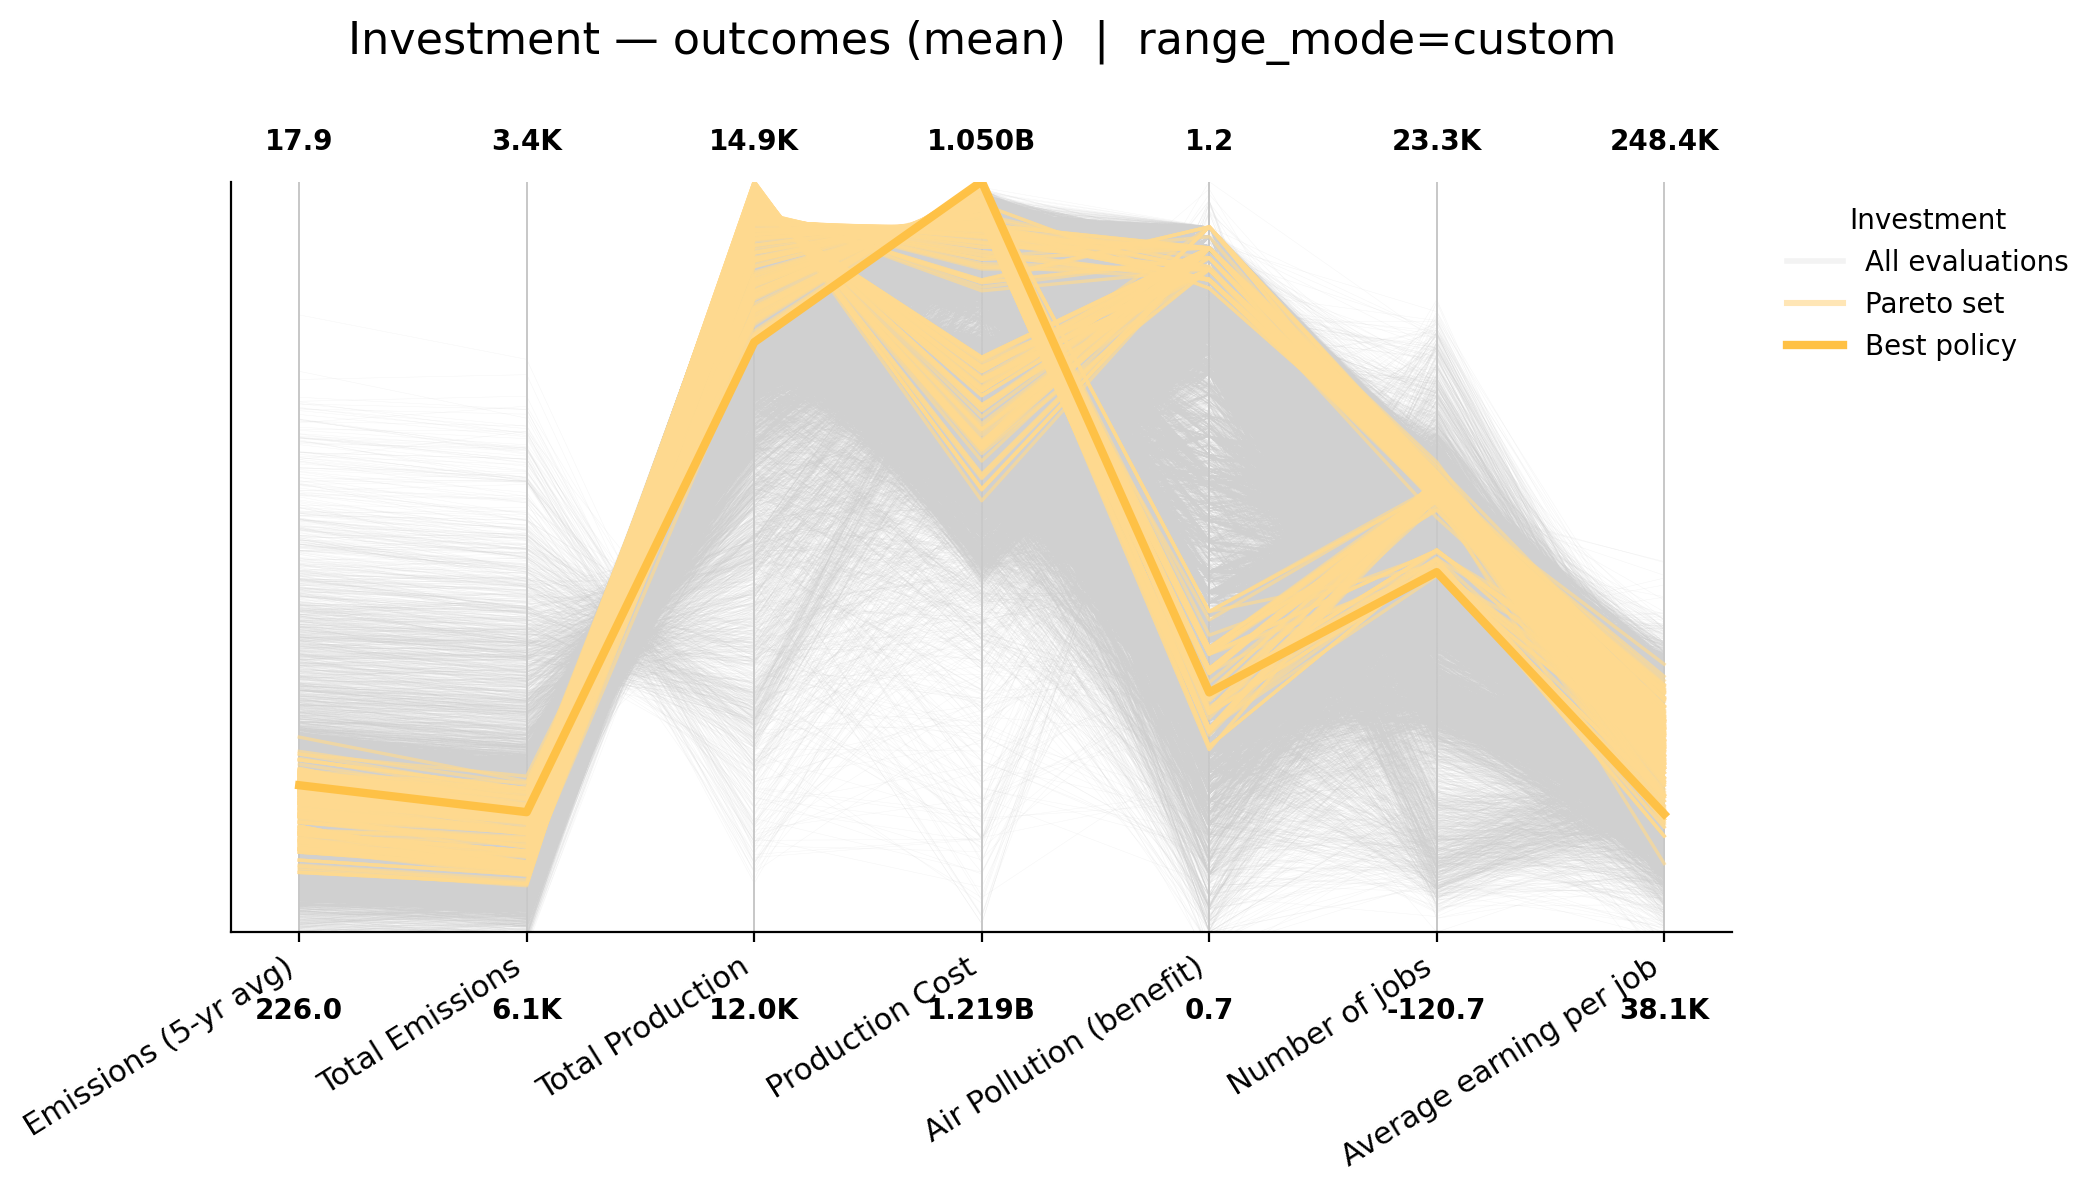

[saved PNG] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_LowCarbon.png
[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_LowCarbon.pdf


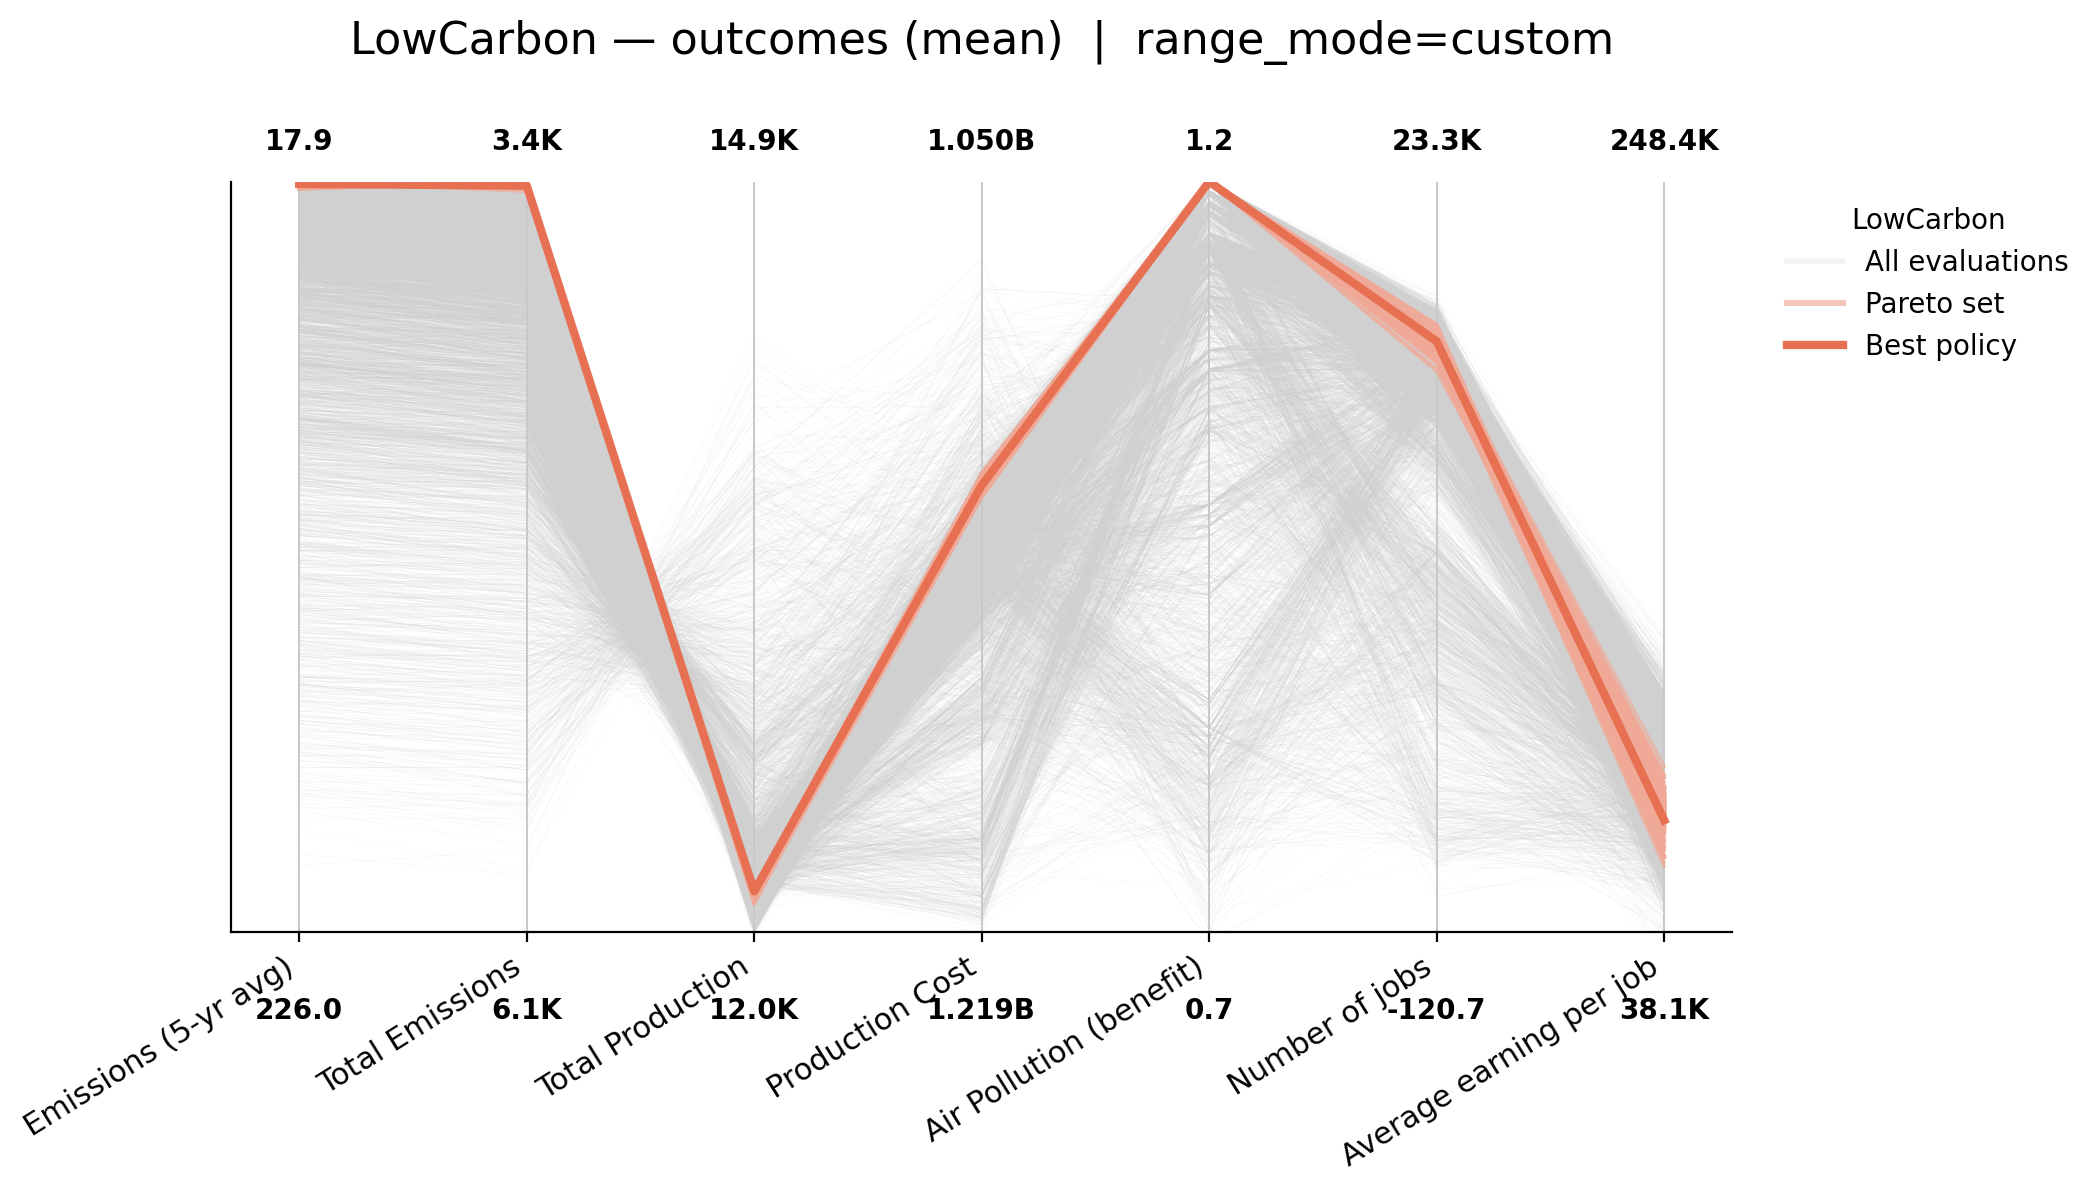

[saved PNG] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_EconomicOpportunity.png
[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_EconomicOpportunity.pdf


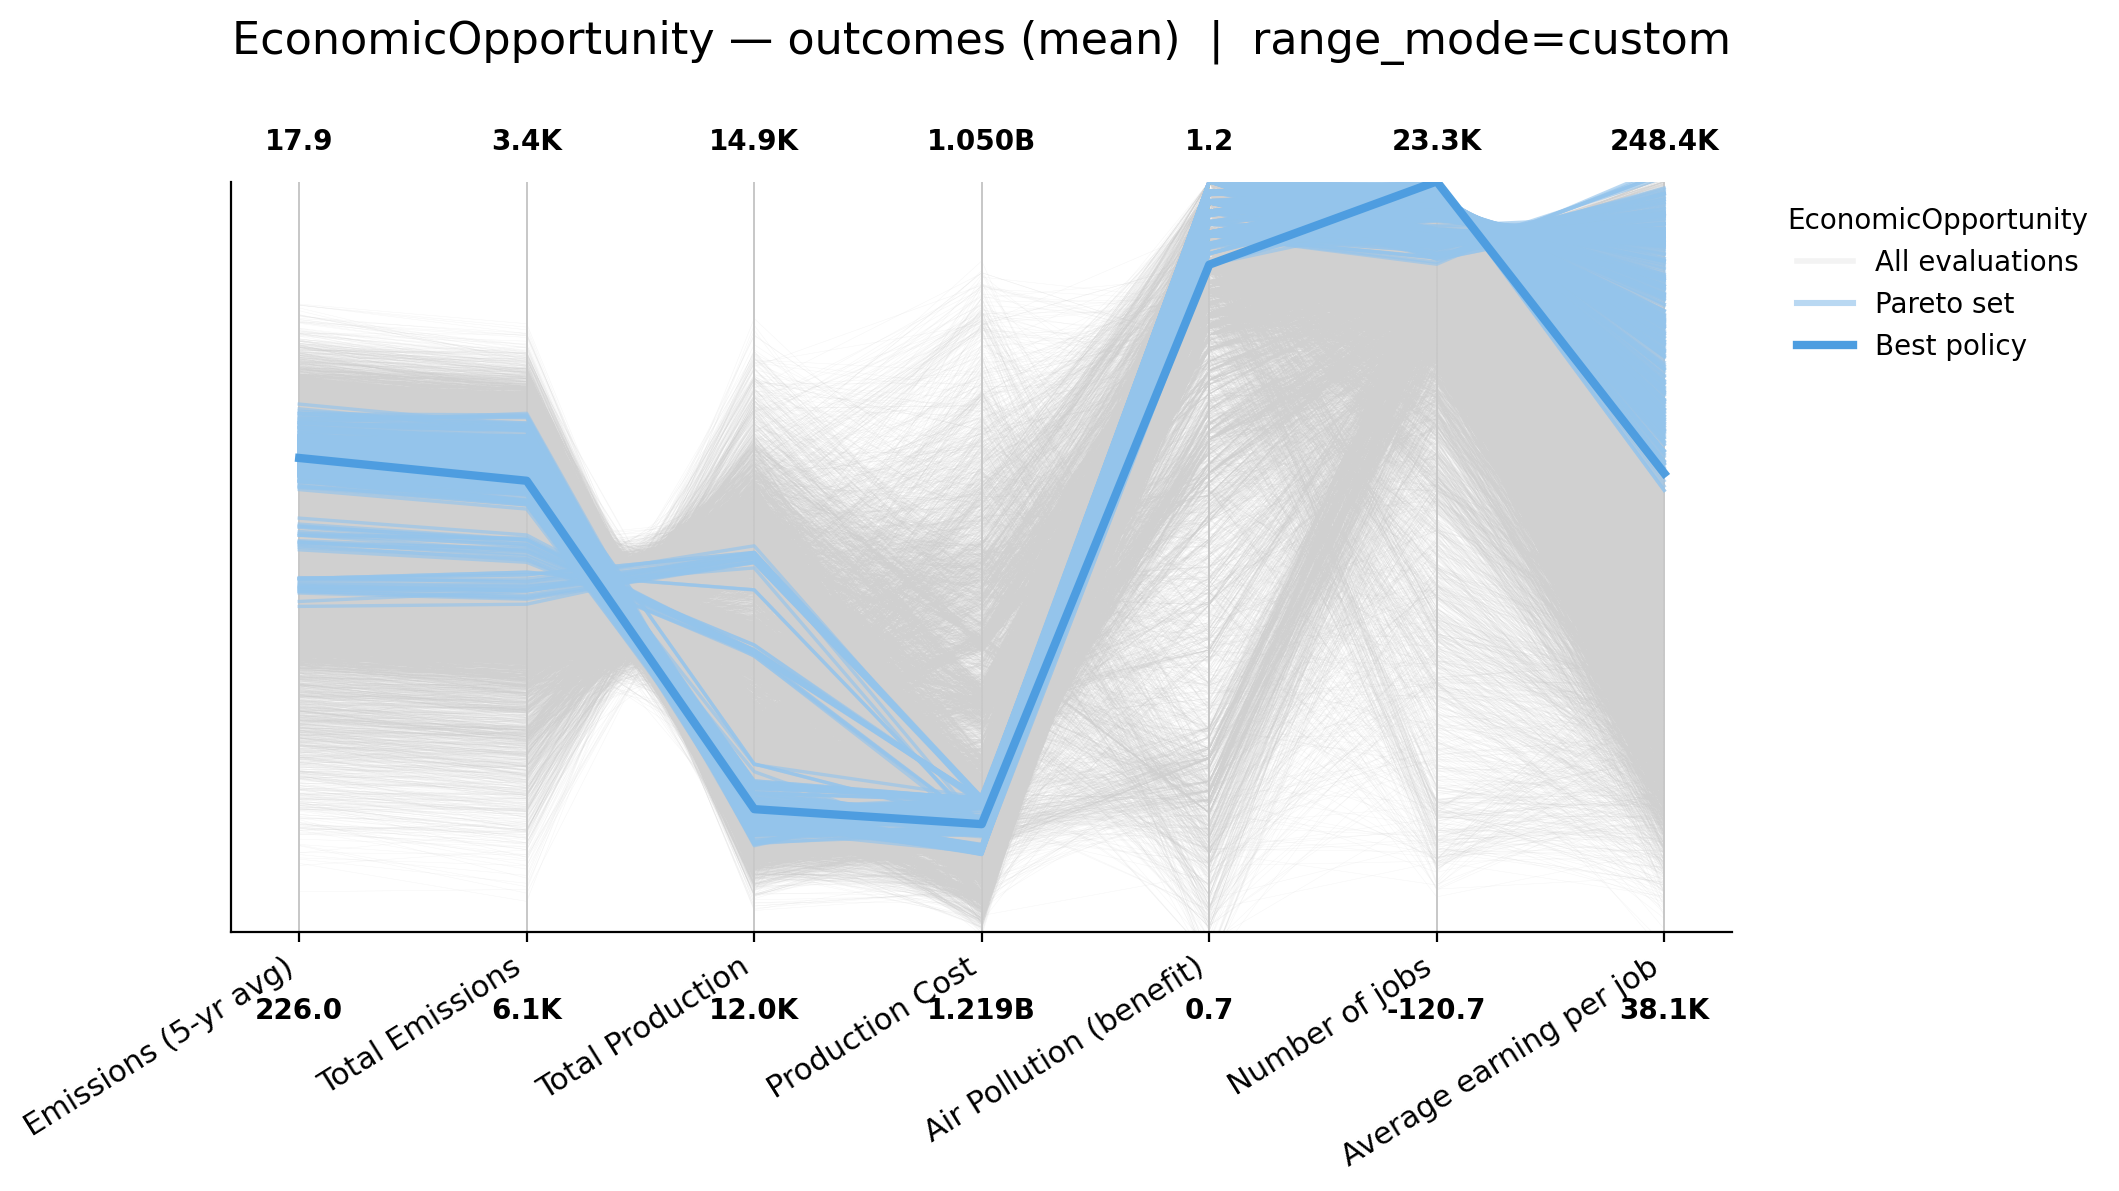

In [10]:
# === Chunk 6 — Generate the four figures (identical axis ranges) =============
# 3 narrative plots (names must match the narratives_cfg keys)
for narrative_name in ["Investment", "LowCarbon", "EconomicOpportunity"]:
    plot_parallel_axes_flexible(
        narrative_name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,
        pipeline=pipeline,
        scenarios=SCENARIOS,
        metrics=metrics7,
        sense_by_obj=sense_by_obj7,
        label_map=label_map,
        policy_colors=colors_by_policy,
        reduce_across_futures="mean",
        percentile_across_futures=None,        # uses REGRET_PERCENTILE
        range_mode="custom",
        range_stack_rows=GLOBAL_RANGE_STACK,    # << identical ranges across figures
        save_png=True, png_dir=FIGS_PNG_DIR, png_dpi=400,
        save_pdf=True, pdf_dir=FIGS_PDF_DIR,
        filename_prefix="parallel_axes"
    )




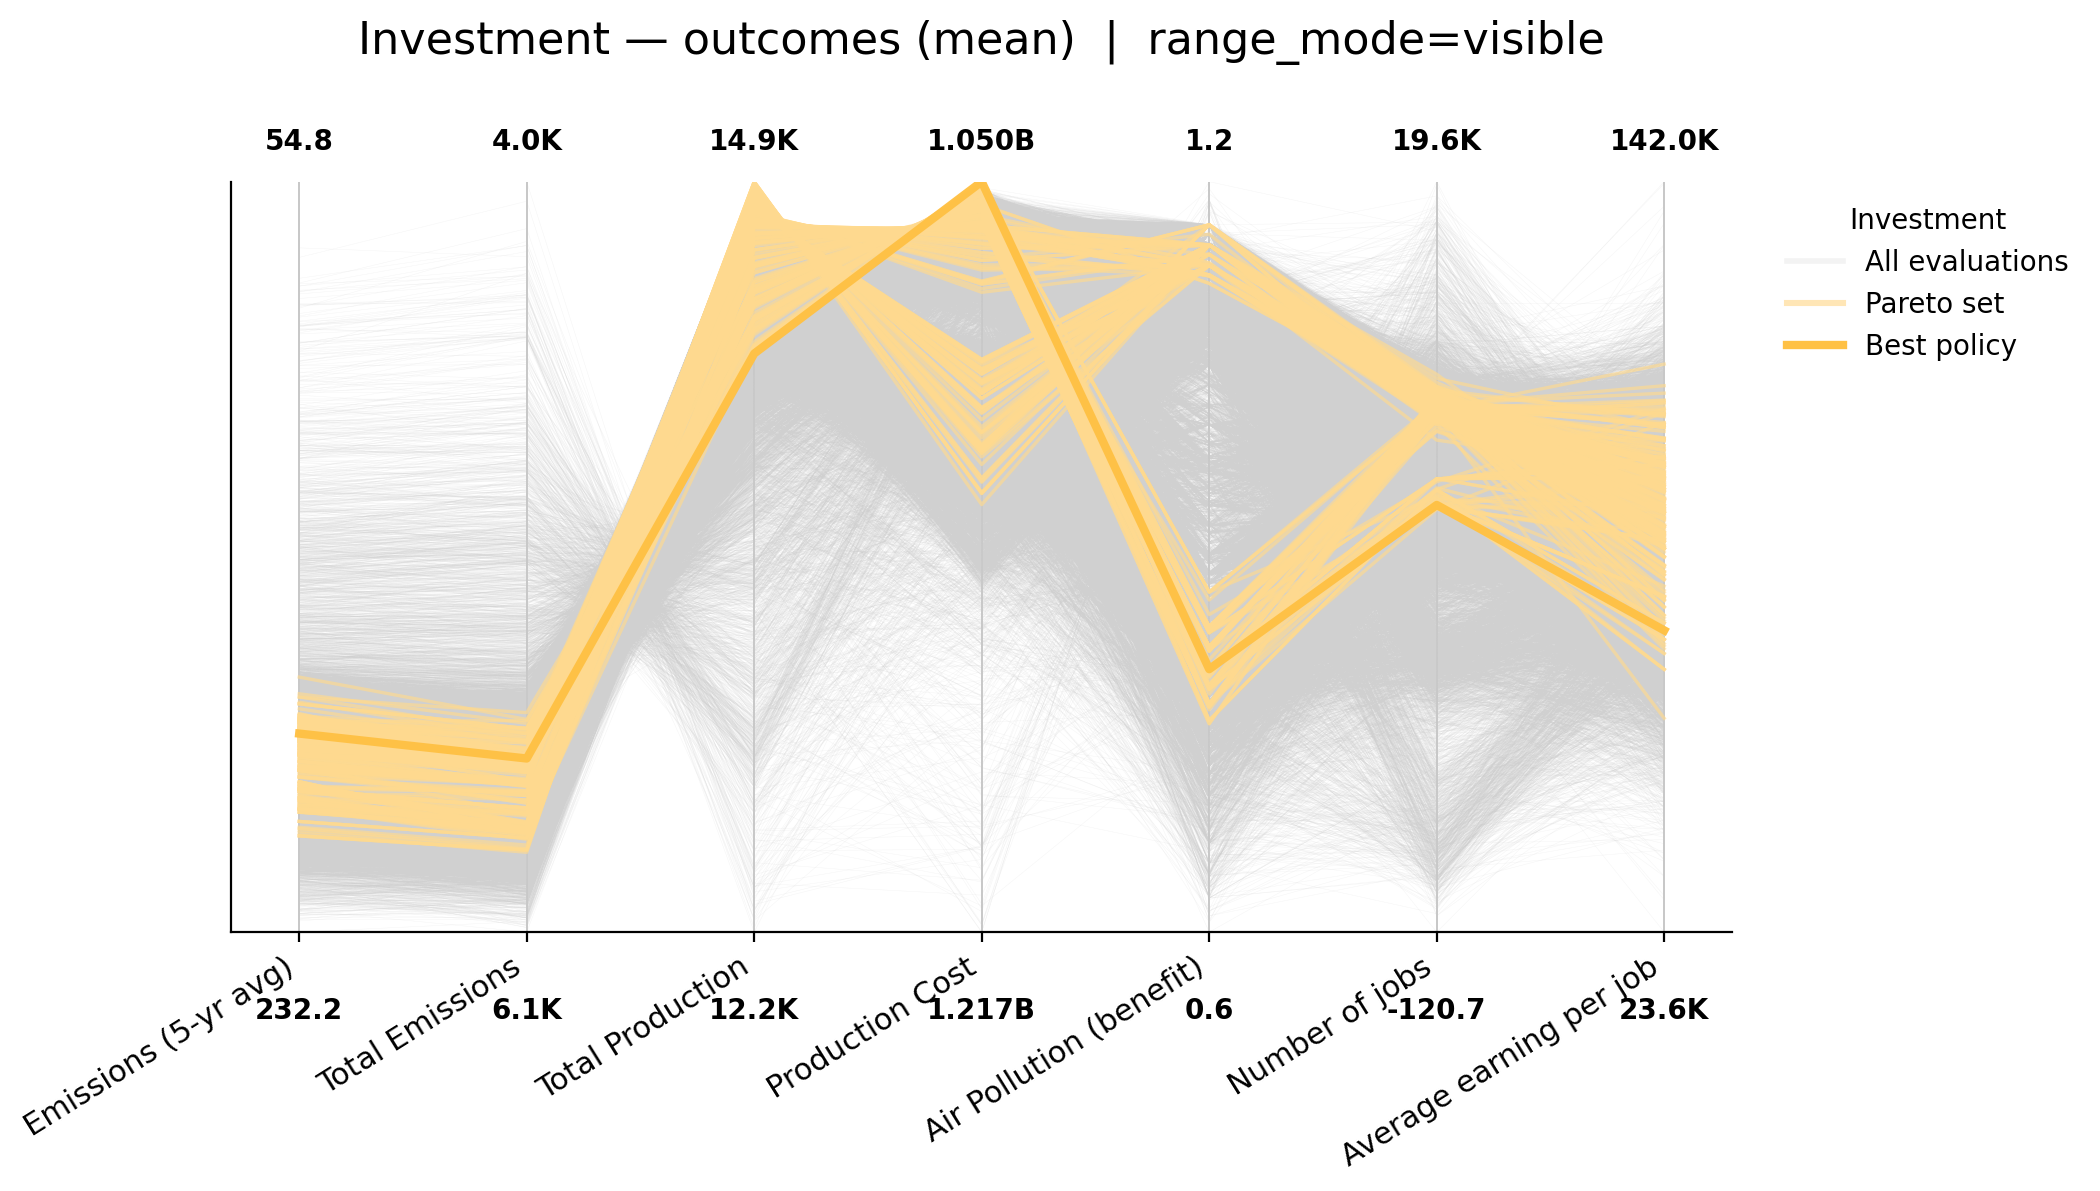

In [11]:
plot_parallel_axes_flexible(
    "Investment",
    best_policies_by_narrative=best_policies_by_narrative,
    evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,
    pipeline=pipeline, scenarios=SCENARIOS,
    metrics=metrics7, sense_by_obj=sense_by_obj7,
    label_map=label_map, policy_colors=colors_by_policy,
    reduce_across_futures="mean",
    range_mode="visible",           # << bypass GLOBAL_RANGE_STACK
    save_png=False, save_pdf=False
)


In [ ]:
allobj_all_evals

[saved PNG] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_ALLOBJECTIVES_overlay.png
[saved PDF] E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_ALLOBJECTIVES_overlay.pdf


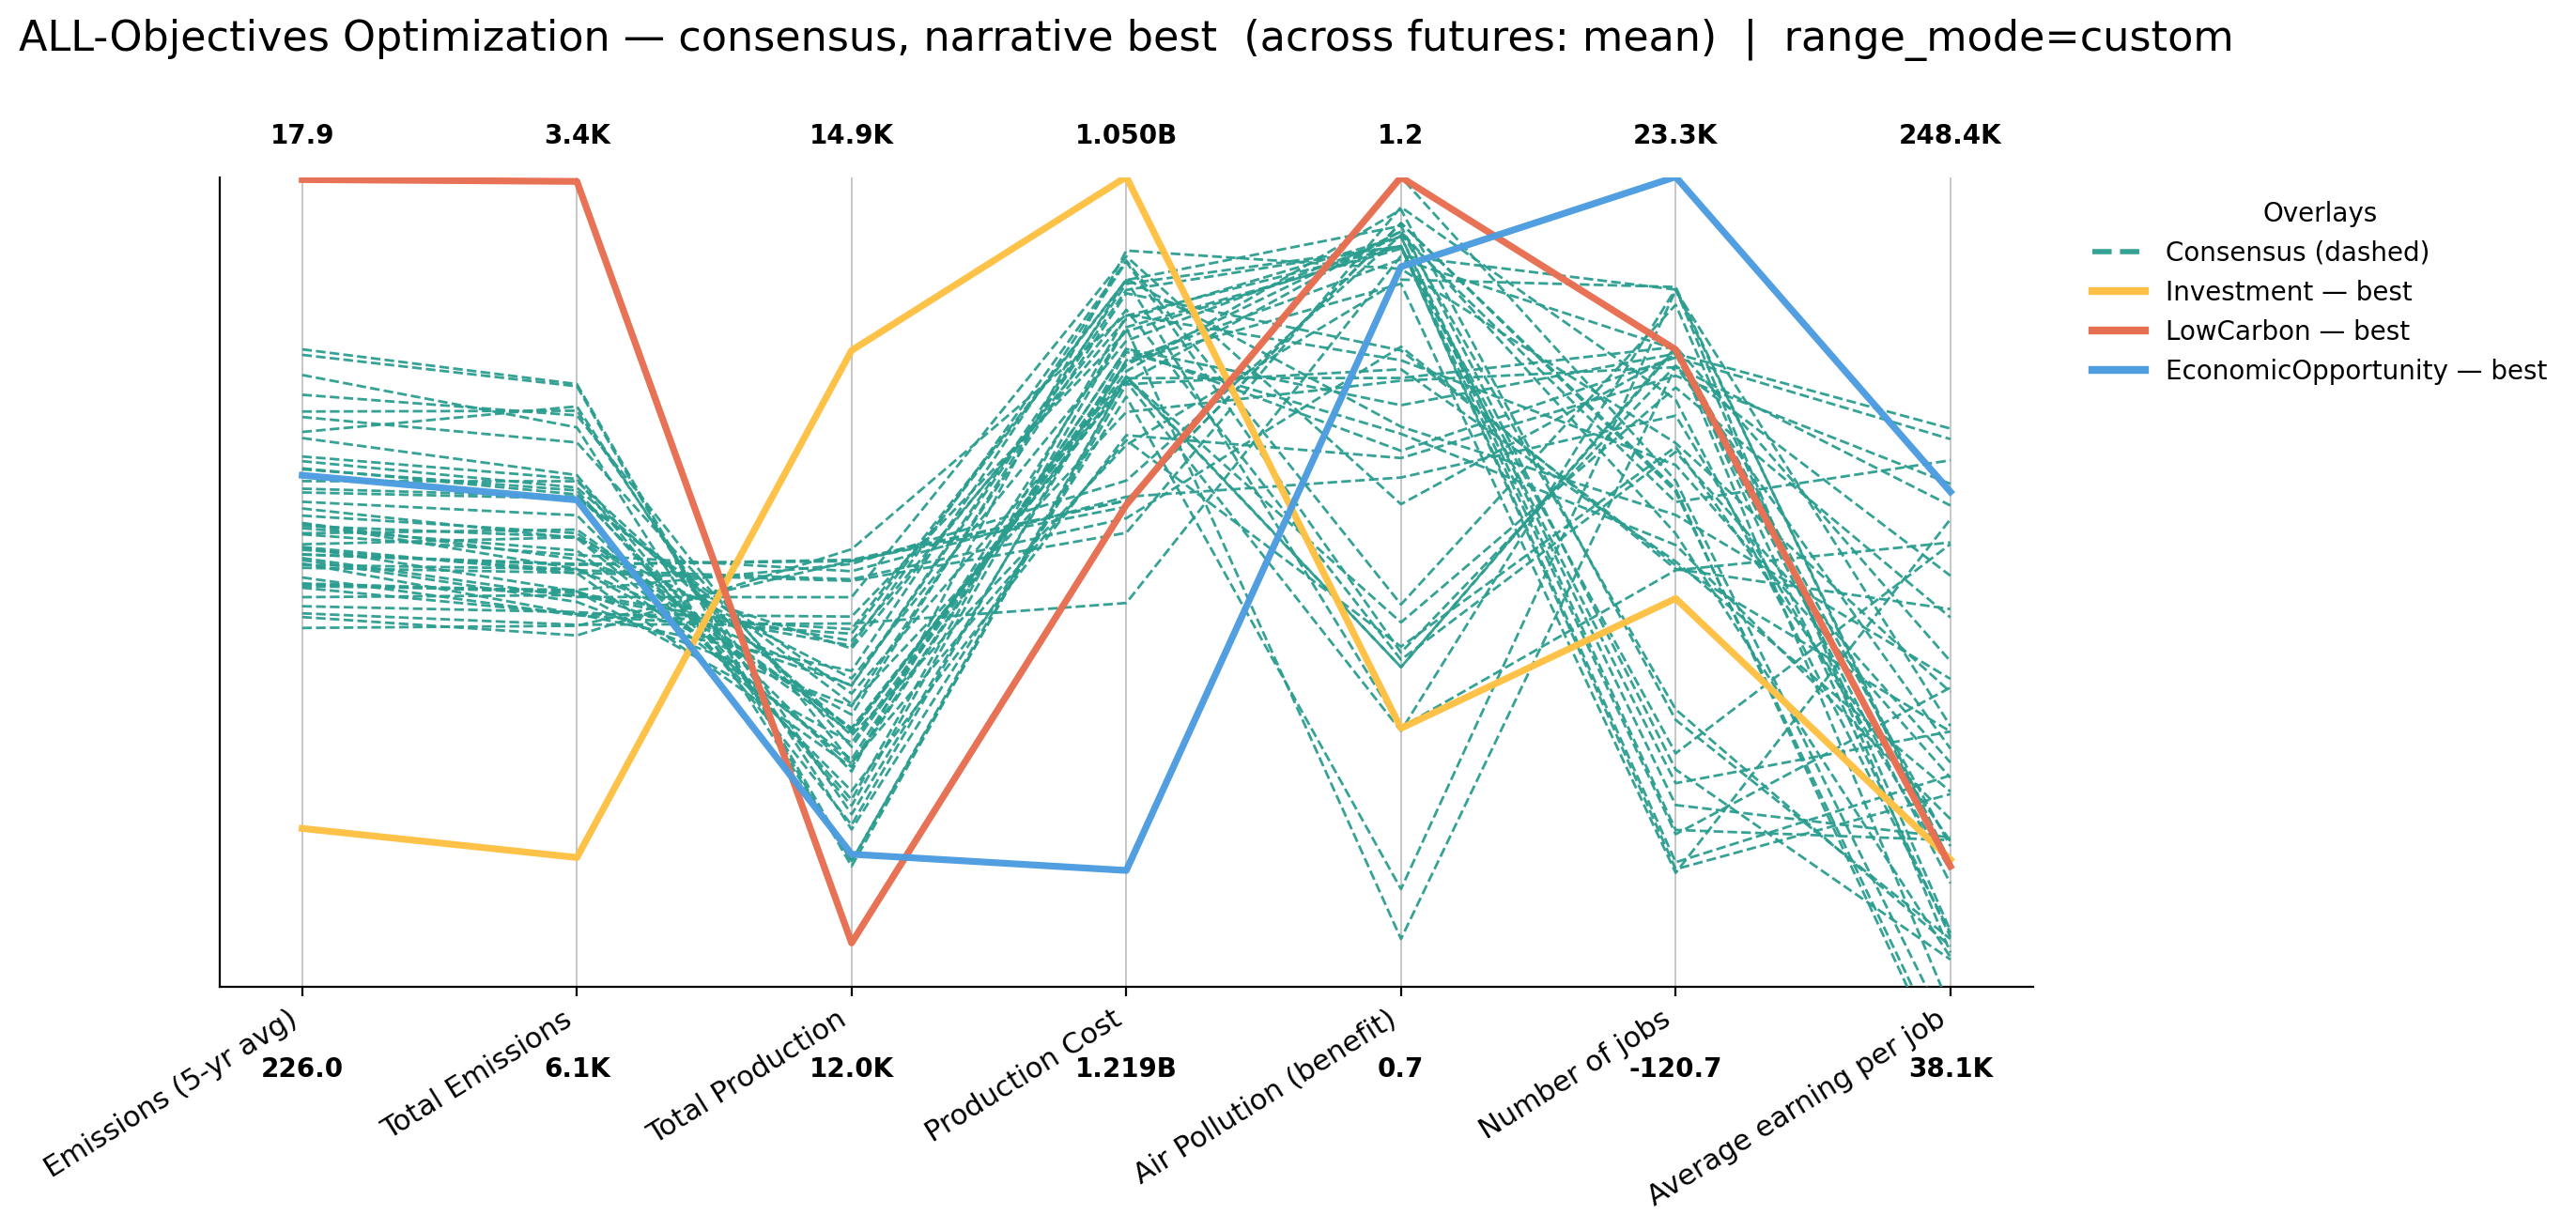

In [12]:
# 1 ALL-objectives overlay
plot_allobjectives_consensus_overlay(
    metrics=metrics7,
    sense_by_obj=sense_by_obj7,
    label_map=label_map,
    reduce_across_futures="mean",
    percentile_across_futures=None,            # uses REGRET_PERCENTILE
    range_mode="custom",
    range_stack_rows=GLOBAL_RANGE_STACK,       # << same shared range
    show_all_evals=False,
    show_pareto=False,
    show_consensus=True,
    show_best=True,
    all_evals_color="#9aa3aa",
    all_evals_lw=0.12, all_evals_alpha=0.20,
    pareto_color="#5d6a73",
    pareto_lw=1.0, pareto_alpha=0.55,
    best_lw=2.6, best_alpha=0.98,
    consensus_lw=1.0, consensus_alpha=0.95,
    save_png=True, png_dir=FIGS_PNG_DIR, png_dpi=400,
    save_pdf=True, pdf_dir=FIGS_PDF_DIR,
    pdf_filename="parallel_axes_ALLOBJECTIVES_overlay.pdf",
    png_filename="parallel_axes_ALLOBJECTIVES_overlay.png"
)

# OLD

### Optimziation for each perspective

In [ ]:
# ========================= Per-Narrative Plots (ALL evals + Pareto overlay, optional baselines) =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# ---- Required globals from earlier chunks ----
_required = [
    "pipeline", "train_metrics", "SCENARIOS", "narratives_cfg",
    "best_policies_by_narrative", "evaluated_candidates_by_narrative"
]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError(f"Missing required globals from Chunk 1/2: {_missing}")

# Optional: Pareto decision vectors per narrative (from Chunk 1)
_has_pareto = "pareto_policies" in globals() and isinstance(pareto_policies, dict)

# ---- PDF output: absolute Windows path (auto-created) ----
PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")

# ---- Baselines (optional subtraction) ----
BASELINE_ON = False  # <<<<< set to True to subtract baselines; False to leave raw values unchanged
BASELINES = {
    "production_total":        1.269096e+09,
    "production_cost_total":   1.888108e+10,
}

def _collect_objectives_and_senses(narratives_cfg: dict[str, list[tuple[str, str]]]):
    senses = {}
    for _, pairs in narratives_cfg.items():
        for metric, sense in pairs:
            senses[metric] = sense.lower()
    ordered = [
        "emission_avg_last_five_years",
        "emission_total",
        "production_total",
        "production_cost_total",
        "air_pollution",
        "num_jobs",
        "earning_per_job",
    ]
    metrics = [m for m in ordered if m in senses]
    sense_by_obj = {m: senses[m] for m in metrics}
    return metrics, sense_by_obj

metrics7, sense_by_obj7 = _collect_objectives_and_senses(narratives_cfg)

# Pretty labels (no delta wording)
label_map = {
    "emission_total": "Total Emissions",
    "emission_avg_last_five_years": "Emissions (5-yr avg)",
    "production_total": "Total Production",
    "production_cost_total": "Production Cost",
    "air_pollution": "Air Pollution (benefit)",
    "num_jobs": "Number of jobs created",
    "earning_per_job": "Average earning per job",
}

colors_by_policy = {
    "Investment": "#FFC145",  # amber
    "LowCarbon": "#E76F51",        # coral
    "EconomicOpportunity": "#4D9DE0",               # blue
}

def _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics) -> np.ndarray:
    """(N,S,M) RAW predictions; safe on empty input."""
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

def _summarize_across_futures(arr_nsm: np.ndarray, reduce: str = "percentile", q: float | None = None) -> np.ndarray:
    """(N,S,M) -> (N,M) via percentile/mean/median/max/min across futures."""
    if arr_nsm.size == 0:
        return np.zeros((0, 0), dtype=float)
    if reduce == "percentile":
        if q is None:
            q = globals().get("REGRET_PERCENTILE", 75.0)
        return np.percentile(arr_nsm, q, axis=1)
    if reduce == "mean":
        return arr_nsm.mean(axis=1)
    if reduce == "median":
        return np.median(arr_nsm, axis=1)
    if reduce == "max":
        return arr_nsm.max(axis=1)
    if reduce == "min":
        return arr_nsm.min(axis=1)
    raise ValueError(f"Unknown reduce='{reduce}'")

def _kmb(v: float) -> str:
    a = abs(v)
    if a >= 1_000_000_000: return f"{v/1_000_000_000:.1f}B"
    if a >= 1_000_000:     return f"{v/1_000_000:.1f}M"
    if a >= 1_000:         return f"{v/1_000:.1f}K"
    return f"{v:.1f}"

def _lighten(color, factor=0.78):
    r, g, b = to_rgb(color)
    return (1 - (1 - r) * factor, 1 - (1 - g) * factor, 1 - (1 - b) * factor)

def _maybe_apply_baselines(df_vals: pd.DataFrame) -> pd.DataFrame:
    """Optionally subtract baselines for specified metrics; return a copy."""
    if not BASELINE_ON:
        return df_vals.copy()
    df = df_vals.copy()
    for m, b in BASELINES.items():
        if m in df.columns:
            df[m] = df[m] - float(b)
    return df

def _build_metric_table_for_rows(
    df_rows: pd.DataFrame, *, pipeline, scenarios, metrics,
    reduce="percentile", q: float | None = None
) -> pd.DataFrame:
    """Returns (N,M) in RAW units aggregated across futures; baseline subtraction optional."""
    A  = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)  # (N,S,M)
    R  = _summarize_across_futures(A, reduce=reduce, q=q)                                  # (N,M)
    df = pd.DataFrame(R, columns=metrics, index=df_rows.index)
    df = _maybe_apply_baselines(df)
    return df

def plot_single_narrative(
    narrative_name: str,
    *,
    best_policies_by_narrative: dict[str, pd.DataFrame],
    evaluated_candidates_by_narrative: dict[str, pd.DataFrame],   # ALL evals (history)
    pipeline,
    scenarios,
    metrics: list[str],
    sense_by_obj: dict[str, str],
    label_map: dict[str, str] | None = None,
    color: str = "#4D9DE0",
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,  # default uses REGRET_PERCENTILE or 75
    figsize=(10.5, 6.7),
    dpi=200,
    background_lw=0.15,
    background_alpha=0.25,
    pareto_lw=1.2,
    pareto_alpha=0.65,
    best_lw=3.0,
    best_alpha=0.98,
    output_dir: str | Path | None = None,            # PNG folder (optional)
    filename_prefix: str = "parallel_axes",
    max_background: int | None = None,               # downsample candidates if huge
    save_pdf: bool = True                            # Save PDFs to PDF_ABS_DIR
):
    """
    One figure per narrative:
      • Thin tinted lines = ALL evaluated candidates (search history)
      • Medium lines      = Pareto set (if available)
      • Bold line         = BEST policy selected in Chunk 1
    Notes:
      - Optional baseline subtraction controlled by BASELINE_ON.
      - Title is higher; extra bottom margin avoids overlap with labels/annotations.
      - PDFs saved to the absolute folder PDF_ABS_DIR if save_pdf=True.
    """
    assert narrative_name in best_policies_by_narrative, f"Unknown narrative: {narrative_name}"
    assert narrative_name in evaluated_candidates_by_narrative, f"No candidates for: {narrative_name}"

    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    # Candidate sets
    df_best_x = best_policies_by_narrative[narrative_name].iloc[[0]]
    df_all_x  = evaluated_candidates_by_narrative.get(narrative_name, pd.DataFrame(columns=df_best_x.columns))
    if max_background and len(df_all_x) > max_background:
        df_all_x = df_all_x.sample(max_background, random_state=42)

    df_pareto_x = None
    if _has_pareto:
        df_pareto_x = pareto_policies.get(narrative_name, None)

    # Metric tables (RAW aggregated across futures), maybe baselines
    df_best_m   = _build_metric_table_for_rows(df_best_x,  pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q)
    df_all_m    = _build_metric_table_for_rows(df_all_x,   pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q) if len(df_all_x) else df_best_m.iloc[[]]
    df_pareto_m = (_build_metric_table_for_rows(df_pareto_x, pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
                   if isinstance(df_pareto_x, pd.DataFrame) and len(df_pareto_x) else df_best_m.iloc[[]])

    # Normalize jointly (all evals + Pareto + best). Flip "min" objectives so higher=better.
    df_stack = pd.concat([df_all_m, df_pareto_m, df_best_m], axis=0)
    scaler = MinMaxScaler().fit(df_stack[metrics].to_numpy(dtype=float))

    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    df_all_n    = _norm(df_all_m)
    df_pareto_n = _norm(df_pareto_m)
    df_best_n   = _norm(df_best_m)

    # --- Plot ---
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # Vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # Top/bottom annotations (respect baseline choice since df_stack already reflects it)
    for i, c in enumerate(metrics):
        vmin, vmax = df_stack[c].min(), df_stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    base = colors_by_policy.get(narrative_name, "#666666")
    lite = "#D0D0D0"   # force light gray for ALL evaluations
    mid  = _lighten(base, factor=0.60)

    # ALL evaluations (thin)
    for idx in df_all_n.index:
        ax.plot(x, df_all_n.loc[idx, metrics], color=lite, alpha=background_alpha, lw=background_lw, zorder=1)

    # Pareto (if available)
    if len(df_pareto_n):
        for idx in df_pareto_n.index:
            ax.plot(x, df_pareto_n.loc[idx, metrics], color=mid, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    # Best policy (bold)
    ax.plot(x, df_best_n.iloc[0][metrics], color=base, alpha=best_alpha, lw=best_lw, zorder=3)

    # Legend
    legend_lines = [Line2D([0],[0], color=lite, lw=2, alpha=background_alpha, label="All evaluations")]
    legend_labels = ["All evaluations"]
    if len(df_pareto_n):
        legend_lines.append(Line2D([0],[0], color=mid, lw=2.2, alpha=pareto_alpha, label="Pareto set"))
        legend_labels.append("Pareto set")
    legend_lines.append(Line2D([0],[0], color=base, lw=3, label="Best policy"))
    legend_labels.append("Best policy")
    ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              frameon=False, title=narrative_name)

    # Title higher + extra bottom whitespace
    ttl = f"{narrative_name} — outcomes ({reduce_across_futures} across futures"
    if reduce_across_futures == "percentile":
        ttl += f", q={q:.0f}"
    ttl += ")"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # Save PNG (optional) and PDF (absolute)
    fname_core = f"{filename_prefix}_{narrative_name.replace(' ', '_')}"
    if output_dir:
        output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
        png_path = output_dir / f"{fname_core}.png"
        plt.savefig(png_path, bbox_inches="tight", dpi=dpi)
        print(f"[saved PNG] {png_path}")

    if save_pdf:
        PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)
        pdf_path = PDF_ABS_DIR / f"{fname_core}.pdf"
        plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)

# ============ RUN: make one figure per narrative ============
# PNGs -> set out_dir if wanted; PDFs always go to PDF_ABS_DIR when save_pdf=True
out_dir = None  # e.g., "figs_parallel_axes"

for _name in ["IndustryEnergyInvestment", "EmissionsReduction", "PlaceToLive"]:
    plot_single_narrative(
        _name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,  # ALL evals (Chunk 1)
        pipeline=pipeline,
        scenarios=SCENARIOS,
        metrics=metrics7,
        sense_by_obj=sense_by_obj7,
        reduce_across_futures= "mean",
        label_map=label_map,
        color=colors_by_policy[_name],
        output_dir=out_dir,   # set a folder (e.g., "figs") to also get PNGs
        save_pdf=True         # PDFs saved to PDF_ABS_DIR
        # percentile_across_futures=90,
        # max_background=20000,
    )
# ====================================================================================================

#### without gray but the range for all evalautions kept

In [ ]:
def plot_single_narrative(
    narrative_name: str,
    *,
    best_policies_by_narrative: dict[str, pd.DataFrame],
    evaluated_candidates_by_narrative: dict[str, pd.DataFrame],   # ALL evals (history)
    pipeline,
    scenarios,
    metrics: list[str],
    sense_by_obj: dict[str, str],
    label_map: dict[str, str] | None = None,
    color: str = "#4D9DE0",
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,  # default uses REGRET_PERCENTILE or 75
    figsize=(10.5, 6.7),
    dpi=200,
    # background_* kept for compatibility; we won't draw them when show_all_evals=False
    background_lw=0.15,
    background_alpha=0.25,
    pareto_lw=1.2,
    pareto_alpha=0.65,
    best_lw=3.0,
    best_alpha=0.98,
    output_dir: str | Path | None = None,            # PNG folder (optional)
    filename_prefix: str = "parallel_axes",
    max_background: int | None = None,               # downsample candidates if huge
    save_pdf: bool = True,
    show_all_evals: bool = False                     # <<< NEW: keep ranges, hide gray lines
):
    """
    One figure per narrative:
      • (optionally hidden) Thin tinted lines = ALL evaluated candidates (search history)
      • Medium lines                          = Pareto set (if available)
      • Bold line                             = BEST policy selected in Chunk 1

    IMPORTANT: Even when show_all_evals=False (no gray lines drawn), the scaler and
    the axis top/bottom annotations are computed using ALL evaluations so the range
    is IDENTICAL to the version that draws the gray lines.
    """
    assert narrative_name in best_policies_by_narrative, f"Unknown narrative: {narrative_name}"
    assert narrative_name in evaluated_candidates_by_narrative, f"No candidates for: {narrative_name}"

    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    # Candidate sets
    df_best_x = best_policies_by_narrative[narrative_name].iloc[[0]]
    df_all_x  = evaluated_candidates_by_narrative.get(narrative_name, pd.DataFrame(columns=df_best_x.columns))
    if max_background and len(df_all_x) > max_background:
        df_all_x = df_all_x.sample(max_background, random_state=42)

    df_pareto_x = None
    if _has_pareto:
        df_pareto_x = pareto_policies.get(narrative_name, None)

    # Metric tables (RAW aggregated across futures), maybe baselines
    df_best_m   = _build_metric_table_for_rows(df_best_x,  pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q)
    df_all_m    = _build_metric_table_for_rows(df_all_x,   pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q) if len(df_all_x) else df_best_m.iloc[[]]
    df_pareto_m = (_build_metric_table_for_rows(df_pareto_x, pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
                   if isinstance(df_pareto_x, pd.DataFrame) and len(df_pareto_x) else df_best_m.iloc[[]])

    # --- Keep ranges identical by fitting scaler on ALL evals (+ pareto + best)
    df_stack = pd.concat([df_all_m, df_pareto_m, df_best_m], axis=0)

    scaler = MinMaxScaler().fit(df_stack[metrics].to_numpy(dtype=float))

    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    df_all_n    = _norm(df_all_m)
    df_pareto_n = _norm(df_pareto_m)
    df_best_n   = _norm(df_best_m)

    # --- Plot ---
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # Vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # Top/bottom annotations from df_stack to match original ranges
    for i, c in enumerate(metrics):
        vmin, vmax = df_stack[c].min(), df_stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    base = colors_by_policy.get(narrative_name, "#666666")
    lite = "#D0D0D0"
    mid  = _lighten(base, factor=0.60)

    # --- (Hidden) ALL evaluations: only draw if requested
    if show_all_evals and len(df_all_n):
        for idx in df_all_n.index:
            ax.plot(x, df_all_n.loc[idx, metrics], color=lite, alpha=background_alpha, lw=background_lw, zorder=1)

    # Pareto (if available)
    if len(df_pareto_n):
        for idx in df_pareto_n.index:
            ax.plot(x, df_pareto_n.loc[idx, metrics], color=mid, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    # Best policy (bold)
    ax.plot(x, df_best_n.iloc[0][metrics], color=base, alpha=best_alpha, lw=best_lw, zorder=3)

    # Legend (omit All evaluations when hidden)
    legend_lines, legend_labels = [], []
    if show_all_evals and len(df_all_n):
        legend_lines.append(Line2D([0],[0], color=lite, lw=2, alpha=background_alpha, label="All evaluations"))
        legend_labels.append("All evaluations")
    if len(df_pareto_n):
        legend_lines.append(Line2D([0],[0], color=mid, lw=2.2, alpha=pareto_alpha, label="Pareto set"))
        legend_labels.append("Pareto set")
    legend_lines.append(Line2D([0],[0], color=base, lw=3, label="Best policy"))
    legend_labels.append("Best policy")
    ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              frameon=False, title=narrative_name)

    # Title higher + extra bottom whitespace
    ttl = f"{narrative_name} — outcomes ({reduce_across_futures} across futures"
    if reduce_across_futures == "percentile":
        ttl += f", q={q:.0f}"
    ttl += ")"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # Save PNG (optional) and PDF (absolute)
    fname_core = f"{filename_prefix}_{narrative_name.replace(' ', '_')}"
    if output_dir:
        output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
        png_path = output_dir / f"{fname_core}.png"
        plt.savefig(png_path, bbox_inches="tight", dpi=dpi)
        print(f"[saved PNG] {png_path}")

    if save_pdf:
        PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)
        pdf_path = PDF_ABS_DIR / f"{fname_core}.pdf"
        plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)


In [ ]:
out_dir = None  # or e.g., "figs_parallel_axes"
for _name in ["IndustryEnergyInvestment", "EmissionsReduction", "PlaceToLive"]:
    plot_single_narrative(
        _name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,
        pipeline=pipeline,
        scenarios=SCENARIOS,
        metrics=metrics7,
        sense_by_obj=sense_by_obj7,
        reduce_across_futures="mean",   # or "percentile"
        label_map=label_map,
        color=colors_by_policy[_name],
        output_dir=out_dir,
        save_pdf=False,
        show_all_evals=True            # <<< hides gray lines; ranges unchanged
    )


felxible 

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler

# NOTE: This code assumes the following helpers/vars already exist in your session,
# just like in your earlier chunks:
#   - _build_metric_table_for_rows(...)
#   - _kmb(...)
#   - _lighten(...)
#   - colors_by_policy (dict)
#   - PDF_ABS_DIR (Path) [optional]
#   - _has_pareto (bool) and pareto_policies (dict) [optional]

def plot_parallel_axes_flexible(
    narrative_name: str,
    *,
    # === required data (same objects you already have) ===
    best_policies_by_narrative: dict[str, pd.DataFrame],
    evaluated_candidates_by_narrative: dict[str, pd.DataFrame],   # ALL evals (history)
    pipeline,
    scenarios,
    metrics: list[str],
    sense_by_obj: dict[str, str],
    # === optional pretties / config ===
    label_map: dict[str, str] | None = None,
    policy_colors: dict[str, str] | None = None,
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,   # uses REGRET_PERCENTILE global if None
    figsize=(10.5, 6.7),
    dpi=200,
    background_lw=0.15,
    background_alpha=0.25,
    pareto_lw=1.2,
    pareto_alpha=0.65,
    best_lw=3.0,
    best_alpha=0.98,
    # === file naming core ===
    filename_prefix: str = "parallel_axes",
    # === NEW: layer visibility toggles ===
    show_all_evals: bool = True,                      # gray lines
    show_pareto: bool = True,
    show_best: bool = True,
    # === NEW: choose how to set the scaler & top/bottom annotations ===
    # "all_evals": always use ALL evaluations (even if you’re not drawing them)
    # "visible":   use exactly the layers you are drawing (all_evals/pareto/best that are True)
    # "custom":    use a custom stack you pass via range_stack_rows (raw metrics, pre-normalization)
    range_mode: str = "all_evals",
    range_stack_rows: pd.DataFrame | None = None,     # only used if range_mode="custom"
    # === NEW: performance/volume guard for gray layer ===
    max_background: int | None = None,                # downsample candidates if huge
    # === NEW: SAVE OPTIONS (PNG/PDF) ===
    save_png: bool = False,
    png_dir: str | Path | None = None,                # defaults to output_dir fallback
    png_dpi: int = 400,                               # high-res PNG (e.g., 300/400/600)
    png_bbox_inches: str = "tight",
    png_pad_inches: float | None = None,              # None = Matplotlib default
    save_pdf: bool = False,
    pdf_dir: str | Path | None = None,                # defaults to PDF_ABS_DIR if defined, else png_dir/output_dir
    pdf_metadata: dict | None = None,                 # e.g., {"Title":"...", "Author":"..."}
    # === legacy/output compatibility (kept for drop-in ease) ===
    output_dir: str | Path | None = None              # legacy PNG dir fallback (kept for compatibility)
):
    """
    Parallel-axes plot with fine-grained control over:
      • Which layers are drawn: All evaluations (gray), Pareto, and/or Best.
      • How the axis range/normalization is determined (range_mode).
      • High-resolution saving to PNG and/or vector PDF.

    Parameters
    ----------
    narrative_name : str
        One of your narrative keys, e.g. "EmissionsReduction".
    best_policies_by_narrative : dict[str, pd.DataFrame]
        Dict mapping narrative -> 1-row DataFrame of decision variables for the selected best policy.
    evaluated_candidates_by_narrative : dict[str, pd.DataFrame]
        Dict mapping narrative -> DataFrame of ALL evaluated decision vectors (search history).
    pipeline :
        Your trained regression pipeline supporting .predict(X) -> DataFrame/ndarray with columns `train_metrics`.
    scenarios : list[dict]
        Futures to evaluate over (keys are feature cols, values are numbers).
    metrics : list[str]
        Ordered metric names to plot.
    sense_by_obj : dict[str, str]
        Mapping metric -> "min"/"max" (case-insensitive). We flip "min" in normalization so higher is better.
    label_map : dict[str, str], optional
        Pretty labels per metric for x-axis.
    policy_colors : dict[str, str], optional
        Mapping narrative -> hex color (fallback provided).
    reduce_across_futures : {"percentile","mean","median","max","min"}
        Aggregation of predictions across futures.
    percentile_across_futures : float | None
        If reduce_across_futures="percentile", quantile to use (defaults to REGRET_PERCENTILE global or 75).
    figsize, dpi : figure sizing and base raster DPI for on-screen
    background_lw, background_alpha, pareto_lw, pareto_alpha, best_lw, best_alpha : styling

    filename_prefix : str
        Base filename stem for saved figures (e.g., "parallel_axes_EmissionsReduction.png/pdf").

    show_all_evals, show_pareto, show_best : bool
        Which layers to draw.

    range_mode : {"all_evals","visible","custom"}
        - "all_evals": normalization is fit on ALL evaluations (+any available pareto/best), regardless of visibility.
        - "visible"  : normalization is fit on exactly the layers that are drawn.
        - "custom"   : normalization is fit on `range_stack_rows` (raw metric values you pass in).

    max_background : int | None
        If set, randomly down-samples the gray “all evaluations” to at most this many rows (random_state=42).

    SAVE OPTIONS
    ------------
    save_png : bool
        Save a PNG (raster). Uses `png_dpi` for high resolution (e.g., 300/400/600).
    png_dir : str | Path | None
        Directory for PNGs. If None, falls back to `output_dir`. If both None, no PNG path is created unless save_png=True and pdf_dir is set (then PNG follows pdf_dir).
    png_dpi : int
        DPI for PNG. 300–600 are typical for print.
    png_bbox_inches : str
        Bbox option for PNG saving ("tight" is typical).
    png_pad_inches : float | None
        Padding inches for "tight" bbox; None = Matplotlib default.

    save_pdf : bool
        Save a vector PDF (publication-quality).
    pdf_dir : str | Path | None
        Directory for PDFs. If None, uses global PDF_ABS_DIR if defined, else falls back to png_dir/output_dir.
    pdf_metadata : dict | None
        PDF metadata dict, e.g., {"Title": "...", "Author": "..."}.

    output_dir : str | Path | None  [legacy]
        Historical parameter you used for PNGs; still honored as a fallback.
    """
    assert narrative_name in evaluated_candidates_by_narrative, f"No candidates for: {narrative_name}"
    assert narrative_name in best_policies_by_narrative, f"Unknown narrative: {narrative_name}"

    # ---------- Resolve colors and quantile ----------
    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)
    base_color = (policy_colors or globals().get("colors_by_policy", {})).get(narrative_name, "#4D9DE0")
    lite = "#D0D0D0"
    mid  = _lighten(base_color, factor=0.60)

    # ---------- Pull candidate sets ----------
    df_best_x = best_policies_by_narrative[narrative_name].iloc[[0]]
    df_all_x  = evaluated_candidates_by_narrative.get(narrative_name, pd.DataFrame(columns=df_best_x.columns))
    if max_background and len(df_all_x) > max_background:
        df_all_x = df_all_x.sample(max_background, random_state=42)

    df_pareto_x = None
    if show_pareto and ("pareto_policies" in globals()) and globals().get("_has_pareto", False):
        df_pareto_x = pareto_policies.get(narrative_name, None)

    # ---------- Build metric tables (RAW units; aggregated across futures) ----------
    df_best_m   = _build_metric_table_for_rows(df_best_x,  pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q)
    df_all_m    = _build_metric_table_for_rows(df_all_x,   pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                               reduce=reduce_across_futures, q=q) if len(df_all_x) else df_best_m.iloc[[]]
    df_pareto_m = (_build_metric_table_for_rows(df_pareto_x, pipeline=pipeline, scenarios=scenarios, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
                   if isinstance(df_pareto_x, pd.DataFrame) and len(df_pareto_x) else df_best_m.iloc[[]])

    # ---------- Decide what sets the AXIS RANGE / NORMALIZATION ----------
    visible_parts = []
    if show_all_evals and len(df_all_m): visible_parts.append(df_all_m)
    if show_pareto    and len(df_pareto_m): visible_parts.append(df_pareto_m)
    if show_best      and len(df_best_m): visible_parts.append(df_best_m)

    if range_mode == "all_evals":
        stack_parts = [df_all_m, df_pareto_m, df_best_m]
    elif range_mode == "visible":
        stack_parts = visible_parts if visible_parts else [df_best_m]
    elif range_mode == "custom":
        assert isinstance(range_stack_rows, pd.DataFrame) and all(m in range_stack_rows.columns for m in metrics), \
            "For range_mode='custom', provide range_stack_rows with the same metric columns."
        stack_parts = [range_stack_rows[metrics]]
    else:
        raise ValueError("range_mode must be one of {'all_evals','visible','custom'}")

    df_stack = pd.concat(stack_parts, axis=0)
    if df_stack.empty:
        df_stack = df_best_m.copy()

    # ---------- Normalize (MinMax on chosen stack; flip 'min') ----------
    scaler = MinMaxScaler().fit(df_stack[metrics].to_numpy(dtype=float))

    def _norm(df_in: pd.DataFrame) -> pd.DataFrame:
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    df_all_n    = _norm(df_all_m)
    df_pareto_n = _norm(df_pareto_m)
    df_best_n   = _norm(df_best_m)

    # ---------- Plot ----------
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # top/bottom annotations use the SAME stack that drove the scaler (keeps ranges consistent)
    for i, c in enumerate(metrics):
        vmin, vmax = df_stack[c].min(), df_stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    # draw layers
    if show_all_evals and len(df_all_n):
        for idx in df_all_n.index:
            ax.plot(x, df_all_n.loc[idx, metrics], color="#D0D0D0", alpha=background_alpha, lw=background_lw, zorder=1)

    if show_pareto and len(df_pareto_n):
        for idx in df_pareto_n.index:
            ax.plot(x, df_pareto_n.loc[idx, metrics], color=mid, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    if show_best and len(df_best_n):
        ax.plot(x, df_best_n.iloc[0][metrics], color=base_color, alpha=best_alpha, lw=best_lw, zorder=3)

    # legend (only for drawn layers)
    legend_lines, legend_labels = [], []
    if show_all_evals and len(df_all_n):
        legend_lines.append(Line2D([0],[0], color="#D0D0D0", lw=2, alpha=background_alpha, label="All evaluations"))
        legend_labels.append("All evaluations")
    if show_pareto and len(df_pareto_n):
        legend_lines.append(Line2D([0],[0], color=_lighten(base_color, 0.60), lw=2.2, alpha=pareto_alpha, label="Pareto set"))
        legend_labels.append("Pareto set")
    if show_best and len(df_best_n):
        legend_lines.append(Line2D([0],[0], color=base_color, lw=3, label="Best policy"))
        legend_labels.append("Best policy")
    if legend_lines:
        ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  frameon=False, title=narrative_name)

    # title + layout
    ttl = f"{narrative_name} — outcomes ({reduce_across_futures} across futures"
    if reduce_across_futures == "percentile":
        ttl += f", q={q:.0f}"
    ttl += f")  |  range_mode={range_mode}"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # ---------- SAVE (PNG/PDF) ----------
    fname_core = f"{filename_prefix}_{narrative_name.replace(' ', '_')}"

    # Resolve default dirs
    # PNG dir: provided png_dir > legacy output_dir > (if not set but PDF dir exists, reuse it) > None
    resolved_png_dir = png_dir or output_dir
    # PDF dir: provided pdf_dir > global PDF_ABS_DIR (if exists) > resolved_png_dir > output_dir
    resolved_pdf_dir = pdf_dir
    if resolved_pdf_dir is None:
        if "PDF_ABS_DIR" in globals():
            resolved_pdf_dir = globals()["PDF_ABS_DIR"]
        else:
            resolved_pdf_dir = resolved_png_dir or output_dir

    if save_png and resolved_png_dir is not None:
        resolved_png_dir = Path(resolved_png_dir); resolved_png_dir.mkdir(parents=True, exist_ok=True)
        png_path = resolved_png_dir / f"{fname_core}.png"
        plt.savefig(
            png_path,
            bbox_inches=png_bbox_inches,
            dpi=png_dpi,
            pad_inches=(png_pad_inches if png_pad_inches is not None else plt.rcParams.get("savefig.pad_inches", 0.1))
        )
        print(f"[saved PNG] {png_path}  (dpi={png_dpi})")

    if save_pdf and resolved_pdf_dir is not None:
        resolved_pdf_dir = Path(resolved_pdf_dir); resolved_pdf_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = resolved_pdf_dir / f"{fname_core}.pdf"
        plt.savefig(
            pdf_path,
            bbox_inches="tight",
            format="pdf",
            metadata=(pdf_metadata or {})
        )
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)


# ---------------- Convenience wrapper: GRAY-ONLY ----------------
def plot_gray_only(
    narrative_name: str,
    *,
    best_policies_by_narrative,
    evaluated_candidates_by_narrative,
    pipeline,
    scenarios,
    metrics,
    sense_by_obj,
    **kwargs
):
    """
    Draw ONLY the 'All evaluations' layer (gray lines).
    Axis range is determined per `range_mode` in kwargs (defaults to 'all_evals' if not provided).
    You can still save high-res PNG/PDF via kwargs (save_png/save_pdf, png_dpi, pdf_metadata, etc.).
    """
    kwargs.setdefault("show_all_evals", True)
    kwargs.setdefault("show_pareto", False)
    kwargs.setdefault("show_best", False)
    kwargs.setdefault("range_mode", "all_evals")

    return plot_parallel_axes_flexible(
        narrative_name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,
        pipeline=pipeline,
        scenarios=scenarios,
        metrics=metrics,
        sense_by_obj=sense_by_obj,
        **kwargs
    )


In [ ]:
for _name in ["IndustryEnergyInvestment", "EmissionsReduction", "PlaceToLive"]:
    plot_gray_only(
        _name,
        best_policies_by_narrative=best_policies_by_narrative,
        evaluated_candidates_by_narrative=evaluated_candidates_by_narrative,
        pipeline=pipeline,
        scenarios=SCENARIOS,
        metrics=metrics7,
        sense_by_obj=sense_by_obj7,
        filename_prefix="parallel_axes_grayonly",
        save_png=True, png_dir="figs_png", png_dpi=600,
        save_pdf=True, pdf_dir="figs_pdf",
        pdf_metadata={"Title": f"{_name} — Gray Only", "Author": "Your Team"}
    )


### all three +consensus 

In [ ]:
# ================= One Plot: ALL-Objectives Optimization Overlay (+Consensus + Narrative best) =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# --------- Required globals already defined in prior chunks ----------
req = ["pipeline","train_metrics","SCENARIOS","narratives_cfg",
       "best_policies_by_narrative","metrics7","sense_by_obj7","label_map","colors_by_policy"]
missing = [x for x in req if x not in globals()]
if missing:
    raise RuntimeError(f"[consensus overlay] Missing globals: {missing}")

# --------- OPTIONAL globals (auto-detected names for ALL-objectives results) ----------
# Provide your ALL-objectives optimization outputs under one of these names:
#   - ALL evaluations (history): any of  allobj_all_evals / evaluated_candidates_allobj / global_all_evals
#   - Pareto set: any of           allobj_pareto_X / pareto_X_allobj / global_pareto_X
allobj_all_evals = None
for cand_name in ["allobj_all_evals", "evaluated_candidates_allobj", "global_all_evals"]:
    if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
        allobj_all_evals = globals()[cand_name]
        print(f"[consensus overlay] Using ALL-evals from '{cand_name}' ({len(allobj_all_evals)})")
        break

allobj_pareto_X = None
for cand_name in ["allobj_pareto_X", "pareto_X_allobj", "global_pareto_X", "pareto_X"]:
    if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
        allobj_pareto_X = globals()[cand_name]
        print(f"[consensus overlay] Using Pareto set from '{cand_name}' ({len(allobj_pareto_X)})")
        break

# Consensus decision vectors (prefer renamed)
CONSENSUS_COLOR = "#2A9D8F"
_consensus_df = None
if "agree_X_renamed" in globals() and isinstance(agree_X_renamed, pd.DataFrame) and not agree_X_renamed.empty:
    _consensus_df = agree_X_renamed
elif "agree_X" in globals() and isinstance(agree_X, pd.DataFrame) and not agree_X.empty:
    _consensus_df = agree_X

# --------- PDF output path ----------
PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")
PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)

# --------- Baseline toggle (reused from previous chunks) ----------
if "BASELINE_ON" not in globals():  BASELINE_ON = False
if "BASELINES" not in globals():
    BASELINES = {
        "production_total":        1.269096e+09,
        "production_cost_total":   1.888108e+10,
    }

def _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics) -> np.ndarray:
    """(N,S,M) RAW predictions; safe on empty input."""
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

def _summarize_across_futures(arr_nsm: np.ndarray, reduce: str = "percentile", q: float | None = None) -> np.ndarray:
    if arr_nsm.size == 0:
        return np.zeros((0, 0), dtype=float)
    if reduce == "percentile":
        if q is None:
            q = globals().get("REGRET_PERCENTILE", 75.0)
        return np.percentile(arr_nsm, q, axis=1)
    if reduce == "mean":   return arr_nsm.mean(axis=1)
    if reduce == "median": return np.median(arr_nsm, axis=1)
    if reduce == "max":    return arr_nsm.max(axis=1)
    if reduce == "min":    return arr_nsm.min(axis=1)
    raise ValueError(f"Unknown reduce='{reduce}'")

def _maybe_apply_baselines(df_vals: pd.DataFrame) -> pd.DataFrame:
    if not BASELINE_ON:
        return df_vals.copy()
    df = df_vals.copy()
    for m, b in BASELINES.items():
        if m in df.columns:
            df[m] = df[m] - float(b)
    return df

def _build_metric_table_for_rows(
    df_rows: pd.DataFrame, *, pipeline, scenarios, metrics,
    reduce="percentile", q: float | None = None
) -> pd.DataFrame:
    A  = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)
    R  = _summarize_across_futures(A, reduce=reduce, q=q)
    df = pd.DataFrame(R, columns=metrics, index=df_rows.index)
    df = _maybe_apply_baselines(df)
    return df

def _kmb(v: float) -> str:
    a = abs(v)
    if a >= 1_000_000_000: return f"{v/1_000_000_000:.1f}B"
    if a >= 1_000_000:     return f"{v/1_000_000:.1f}M"
    if a >= 1_000:         return f"{v/1_000:.1f}K"
    return f"{v:.1f}"

def _lighten(color, factor=0.78):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return (1 - (1 - r) * factor, 1 - (1 - g) * factor, 1 - (1 - b) * factor)

def plot_allobjectives_consensus_overlay(
    *,
    metrics: list,
    sense_by_obj: dict,
    label_map: dict | None,
    reduce_across_futures="percentile",
    percentile_across_futures: float | None = None,   # default uses REGRET_PERCENTILE or 75
    figsize=(13.5, 7.7),
    dpi=200,
    all_evals_color="#9aa3aa",      # neutral gray for ALL-evals (ALL objectives)
    pareto_color="#5d6a73",         # darker neutral for Pareto
    all_evals_lw=0.35, all_evals_alpha=0.22,
    pareto_lw=1.0,   pareto_alpha=0.55,
    best_lw=2.6,     best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,
    max_all_evals: int | None = None,
    max_consensus: int | None = None,
    save_pdf: bool = True,
    output_pdf_name: str = "parallel_axes_ALLOBJECTIVES_overlay.pdf"
):
    """
    Overlays for the ALL-objectives optimization:
      - All evaluations (thin neutral)
      - Pareto set (medium neutral)
      - Consensus policies (dashed teal)
      - Best policy from each single-narrative optimization (bold, narrative colors)
    All lines share a single normalization fitted across everything on the chart.
    """
    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    # ---- Build metric tables for ALL-objectives pieces ----
    pools = []  # for joint scaler fit
    all_evals_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_all_evals, pd.DataFrame) and len(allobj_all_evals):
        df = allobj_all_evals
        if max_all_evals and len(df) > max_all_evals:
            df = df.sample(max_all_evals, random_state=42)
        all_evals_m = _build_metric_table_for_rows(df, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        pools.append(all_evals_m)
    else:
        print("[consensus overlay] No ALL-evaluations DataFrame for ALL-objectives run.")

    pareto_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_pareto_X, pd.DataFrame) and len(allobj_pareto_X):
        pareto_m = _build_metric_table_for_rows(allobj_pareto_X, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
        pools.append(pareto_m)
    else:
        print("[consensus overlay] No Pareto set for ALL-objectives run.")

    consensus_m = pd.DataFrame(columns=metrics)
    if isinstance(_consensus_df, pd.DataFrame) and len(_consensus_df):
        dfc = _consensus_df
        if max_consensus and len(dfc) > max_consensus:
            dfc = dfc.sample(max_consensus, random_state=42)
        consensus_m = _build_metric_table_for_rows(dfc, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        pools.append(consensus_m)
    else:
        print("[consensus overlay] No consensus policies to plot (agree_X).")

    # Best policy (single row each) for each narrative
    best_tables = {}
    for name, dfb in best_policies_by_narrative.items():
        dfb1 = dfb.iloc[[0]]
        bm = _build_metric_table_for_rows(dfb1, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                          reduce=reduce_across_futures, q=q)
        best_tables[name] = bm
        pools.append(bm)

    # Joint normalizer
    if not pools:
        raise RuntimeError("[consensus overlay] Nothing to plot — no metric tables available.")
    stack = pd.concat(pools, axis=0)
    scaler = MinMaxScaler().fit(stack[metrics].to_numpy(dtype=float))

    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    all_evals_n = _norm(all_evals_m)
    pareto_n    = _norm(pareto_m)
    consensus_n = _norm(consensus_m) if len(consensus_m) else consensus_m
    best_n      = {name: _norm(bm) for name, bm in best_tables.items()}

    # ---- Plot ----
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # Vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # Top/bottom annotations from joint stack (already baseline-adjusted)
    for i, c in enumerate(metrics):
        vmin, vmax = stack[c].min(), stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    # 1) ALL-evaluations (ALL-objectives) — thin neutral
    for idx in all_evals_n.index:
        ax.plot(x, all_evals_n.loc[idx, metrics], color=all_evals_color, alpha=all_evals_alpha, lw=all_evals_lw, zorder=1)

    # 2) Pareto (ALL-objectives) — medium neutral
    for idx in pareto_n.index:
        ax.plot(x, pareto_n.loc[idx, metrics], color=pareto_color, alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    # 3) Consensus policies — dashed teal
    for idx in consensus_n.index:
        ax.plot(x, consensus_n.loc[idx, metrics], color=CONSENSUS_COLOR, alpha=consensus_alpha,
                lw=consensus_lw, linestyle="--", zorder=3.5)

    # 4) Best policy from each narrative — bold in narrative colors
    for name, bn in best_n.items():
        col = colors_by_policy.get(name, "#666666")
        ax.plot(x, bn.iloc[0][metrics], color=col, alpha=best_alpha, lw=best_lw, zorder=4)

    # Legend
    legend_lines = [
        Line2D([0],[0], color=all_evals_color, lw=2, alpha=all_evals_alpha, label="ALL-objs — all evals"),
        Line2D([0],[0], color=pareto_color,    lw=2.2, alpha=pareto_alpha,    label="ALL-objs — Pareto"),
        Line2D([0],[0], color=CONSENSUS_COLOR, lw=2.0, ls="--", alpha=consensus_alpha, label="Consensus (dashed)"),
    ]
    legend_labels = [h.get_label() for h in legend_lines]
    for name in best_n.keys():
        legend_lines.append(Line2D([0],[0], color=colors_by_policy.get(name, "#666666"), lw=3, label=f"{name} — best"))
        legend_labels.append(f"{name} — best")

    ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
              frameon=False, title="Overlays")

    ttl = "ALL-Objectives Optimization — all evals, Pareto, consensus + narrative best"
    if reduce_across_futures == "percentile":
        q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)
        ttl += f"  (across futures: {reduce_across_futures}, q={q:.0f})"
    else:
        ttl += f"  (across futures: {reduce_across_futures})"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # Save PDF
    if save_pdf:
        pdf_path = PDF_ABS_DIR / output_pdf_name
        plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)

# ===================== RUN =====================
plot_allobjectives_consensus_overlay(
    metrics=metrics7,
    sense_by_obj=sense_by_obj7,
    label_map=label_map,
    reduce_across_futures="percentile",
    percentile_across_futures=None,
    figsize=(13.5, 7.7),
    dpi=200,

    # Make ALL-evals ultra thin + light gray
    all_evals_color="#FFFFFF",   # light gray
    all_evals_lw=0.10,           # extra thin
    all_evals_alpha=0.20,        # faint

    pareto_color="#5d6a73",
    pareto_lw=1.0, pareto_alpha=0.55,
    best_lw=2.6, best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,
    max_all_evals=None,
    max_consensus=None,
    save_pdf=True,
    output_pdf_name="parallel_axes_ALLOBJECTIVES_overlay.pdf"
)

# ====================================================================================================


In [ ]:
# ================= One Plot: ALL-Objectives Optimization Overlay (+Consensus + Narrative best) =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

# --------- Required globals already defined in prior chunks ----------
req = ["pipeline","train_metrics","SCENARIOS","narratives_cfg",
       "best_policies_by_narrative","metrics7","sense_by_obj7","label_map","colors_by_policy"]
missing = [x for x in req if x not in globals()]
if missing:
    raise RuntimeError(f"[consensus overlay] Missing required globals: {missing}")

# --------- OPTIONAL globals (auto-detected names for ALL-objectives results) ----------
# Provide your ALL-objectives optimization outputs under one of these names:
#   - ALL evaluations (history): any of  allobj_all_evals / evaluated_candidates_allobj / global_all_evals
#   - Pareto set: any of           allobj_pareto_X / pareto_X_allobj / global_pareto_X / pareto_X
allobj_all_evals = None
for cand_name in ["allobj_all_evals", "evaluated_candidates_allobj", "global_all_evals"]:
    if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
        allobj_all_evals = globals()[cand_name]
        print(f"[consensus overlay] Using ALL-evals from '{cand_name}' ({len(allobj_all_evals)})")
        break

allobj_pareto_X = None
for cand_name in ["allobj_pareto_X", "pareto_X_allobj", "global_pareto_X", "pareto_X"]:
    if cand_name in globals() and isinstance(globals()[cand_name], pd.DataFrame):
        allobj_pareto_X = globals()[cand_name]
        print(f"[consensus overlay] Using Pareto set from '{cand_name}' ({len(allobj_pareto_X)})")
        break

# Consensus decision vectors (prefer renamed)
CONSENSUS_COLOR = "#2A9D8F"
_consensus_df = None
if "agree_X_renamed" in globals() and isinstance(agree_X_renamed, pd.DataFrame) and not agree_X_renamed.empty:
    _consensus_df = agree_X_renamed
elif "agree_X" in globals() and isinstance(agree_X, pd.DataFrame) and not agree_X.empty:
    _consensus_df = agree_X

# --------- Outputs root (as in your code) + standard subfolders for figures ----------
PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")
PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)

# Default figure subfolders INSIDE outputs/
FIGS_PNG_DIR = PDF_ABS_DIR / "figs_png"
FIGS_PDF_DIR = PDF_ABS_DIR / "figs_pdf"
FIGS_PNG_DIR.mkdir(parents=True, exist_ok=True)
FIGS_PDF_DIR.mkdir(parents=True, exist_ok=True)

# --------- Baseline toggle (reused from previous chunks) ----------
if "BASELINE_ON" not in globals():  BASELINE_ON = False
if "BASELINES" not in globals():
    BASELINES = {
        "production_total":        1.269096e+09,
        "production_cost_total":   1.888108e+10,
    }

def _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics) -> np.ndarray:
    """(N,S,M) RAW predictions; safe on empty input."""
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        pred = pipeline.predict(Xs)
        Y = pd.DataFrame(pred, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

def _summarize_across_futures(arr_nsm: np.ndarray, reduce: str = "percentile", q: float | None = None) -> np.ndarray:
    """Aggregate across futures: percentile/mean/median/max/min."""
    if arr_nsm.size == 0:
        return np.zeros((0, 0), dtype=float)
    if reduce == "percentile":
        if q is None:
            q = globals().get("REGRET_PERCENTILE", 75.0)
        return np.percentile(arr_nsm, q, axis=1)
    if reduce == "mean":   return arr_nsm.mean(axis=1)
    if reduce == "median": return np.median(arr_nsm, axis=1)
    if reduce == "max":    return arr_nsm.max(axis=1)
    if reduce == "min":    return arr_nsm.min(axis=1)
    raise ValueError(f"Unknown reduce='{reduce}'")

def _maybe_apply_baselines(df_vals: pd.DataFrame) -> pd.DataFrame:
    """Optionally subtract baselines for specified metrics."""
    if not BASELINE_ON:
        return df_vals.copy()
    df = df_vals.copy()
    for m, b in BASELINES.items():
        if m in df.columns:
            df[m] = df[m] - float(b)
    return df

def _build_metric_table_for_rows(
    df_rows: pd.DataFrame, *, pipeline, scenarios, metrics,
    reduce="percentile", q: float | None = None
) -> pd.DataFrame:
    """Returns (N,M) in RAW units aggregated across futures; baseline subtraction optional."""
    A  = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)  # (N,S,M)
    R  = _summarize_across_futures(A, reduce=reduce, q=q)                                  # (N,M)
    df = pd.DataFrame(R, columns=metrics, index=df_rows.index)
    df = _maybe_apply_baselines(df)
    return df

def _kmb(v: float) -> str:
    """Format big numbers to K/M/B for top/bottom axis annotations."""
    a = abs(v)
    if a >= 1_000_000_000: return f"{v/1_000_000_000:.1f}B"
    if a >= 1_000_000:     return f"{v/1_000_000:.1f}M"
    if a >= 1_000:         return f"{v/1_000:.1f}K"
    return f"{v:.1f}"

def _lighten(color, factor=0.78):
    """Lighten a color toward white by 'factor'."""
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return (1 - (1 - r) * factor, 1 - (1 - g) * factor, 1 - (1 - b) * factor)

def plot_allobjectives_consensus_overlay(
    *,
    metrics: list,
    sense_by_obj: dict,
    label_map: dict | None,
    # ---- aggregation across futures ----
    reduce_across_futures: str = "percentile",
    percentile_across_futures: float | None = None,   # default uses REGRET_PERCENTILE or 75
    # ---- figure styling ----
    figsize=(13.5, 7.7),
    dpi=200,
    # ---- layer styling ----
    all_evals_color="#9aa3aa",      # neutral gray for ALL-evals (ALL objectives)
    pareto_color="#5d6a73",         # darker neutral for Pareto
    all_evals_lw=0.30, all_evals_alpha=0.22,
    pareto_lw=1.0,   pareto_alpha=0.55,
    best_lw=2.6,     best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,
    # ---- layer toggles ----
    show_all_evals: bool = True,
    show_pareto: bool = True,
    show_consensus: bool = True,
    show_best: bool = True,
    # ---- volume guards ----
    max_all_evals: int | None = None,
    max_consensus: int | None = None,
    # ---- range/normalization control ----
    # "all":     fit on ALL-evals + (visible) pareto + best + consensus (even if some not drawn)
    # "visible": fit only on the layers actually drawn (per show_* toggles)
    # "custom":  fit on a custom DataFrame of raw metric rows you pass via range_stack_rows
    range_mode: str = "all",
    range_stack_rows: pd.DataFrame | None = None,
    # ---- saving (both default into outputs subfolders) ----
    save_png: bool = True,
    png_dir: str | Path | None = None,     # default: outputs/figs_png
    png_dpi: int = 400,
    png_bbox_inches: str = "tight",
    png_pad_inches: float | None = None,
    save_pdf: bool = True,
    pdf_dir: str | Path | None = None,     # default: outputs/figs_pdf
    pdf_filename: str = "parallel_axes_ALLOBJECTIVES_overlay.pdf",
    png_filename: str | None = None        # default uses pdf_filename stem + ".png"
):
    """
    Flexible ALL-objectives parallel-axes overlay with:
      • Layer toggles: all evaluations (gray), Pareto, consensus, and narrative best.
      • Range control via range_mode: 'all' | 'visible' | 'custom'.
      • High-quality saving to PNG (raster) and PDF (vector) inside outputs/.

    Notes
    -----
    - Baseline subtraction honors BASELINE_ON/BASELINES.
    - Normalization is MinMax on the chosen range stack, then "min" metrics are flipped (higher=better).
    - If png_dir / pdf_dir not provided, they default to:
        png_dir = outputs/figs_png
        pdf_dir = outputs/figs_pdf
    """
    # Resolve outputs dirs (default under outputs/)
    png_dir = Path(png_dir) if png_dir is not None else FIGS_PNG_DIR
    pdf_dir = Path(pdf_dir) if pdf_dir is not None else FIGS_PDF_DIR
    png_dir.mkdir(parents=True, exist_ok=True)
    pdf_dir.mkdir(parents=True, exist_ok=True)

    # Resolve filenames
    if png_filename is None:
        png_filename = Path(pdf_filename).with_suffix(".png").name

    q = percentile_across_futures if percentile_across_futures is not None else globals().get("REGRET_PERCENTILE", 75.0)

    # ---- Build metric tables for ALL-objectives pieces ----
    pools = []  # for joint scaler fit (depending on range_mode)
    visible_parts = []  # what we actually draw

    all_evals_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_all_evals, pd.DataFrame) and len(allobj_all_evals):
        df = allobj_all_evals
        if max_all_evals and len(df) > max_all_evals:
            df = df.sample(max_all_evals, random_state=42)
        all_evals_m = _build_metric_table_for_rows(df, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        if show_all_evals:
            visible_parts.append(all_evals_m)
    else:
        print("[consensus overlay] No ALL-evaluations DataFrame for ALL-objectives run.")

    pareto_m = pd.DataFrame(columns=metrics)
    if isinstance(allobj_pareto_X, pd.DataFrame) and len(allobj_pareto_X):
        pareto_m = _build_metric_table_for_rows(allobj_pareto_X, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                reduce=reduce_across_futures, q=q)
        if show_pareto:
            visible_parts.append(pareto_m)
    else:
        print("[consensus overlay] No Pareto set for ALL-objectives run.")

    consensus_m = pd.DataFrame(columns=metrics)
    if isinstance(_consensus_df, pd.DataFrame) and len(_consensus_df):
        dfc = _consensus_df
        if max_consensus and len(dfc) > max_consensus:
            dfc = dfc.sample(max_consensus, random_state=42)
        consensus_m = _build_metric_table_for_rows(dfc, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                                   reduce=reduce_across_futures, q=q)
        if show_consensus:
            visible_parts.append(consensus_m)
    else:
        print("[consensus overlay] No consensus policies to plot (agree_X).")

    # Best policy (single row each) for each narrative
    best_tables = {}
    for name, dfb in best_policies_by_narrative.items():
        dfb1 = dfb.iloc[[0]]
        bm = _build_metric_table_for_rows(dfb1, pipeline=pipeline, scenarios=SCENARIOS, metrics=metrics,
                                          reduce=reduce_across_futures, q=q)
        best_tables[name] = bm
        if show_best:
            visible_parts.append(bm)

    # ---- Decide what sets the AXIS RANGE / NORMALIZATION ----
    if range_mode not in {"all","visible","custom"}:
        raise ValueError("range_mode must be one of {'all','visible','custom'}")

    if range_mode == "all":
        # Fit on all-evals + pareto + best + consensus (regardless of visibility)
        stack_candidates = [all_evals_m, pareto_m, consensus_m] + list(best_tables.values())
        pools = [df for df in stack_candidates if len(df)]
    elif range_mode == "visible":
        pools = [df for df in visible_parts if len(df)]
    elif range_mode == "custom":
        assert isinstance(range_stack_rows, pd.DataFrame) and all(m in range_stack_rows.columns for m in metrics), \
            "For range_mode='custom', provide range_stack_rows with the same metric columns."
        pools = [range_stack_rows[metrics]]

    if not pools:
        # Fallback: at least include one of the best policies
        pools = [next(iter(best_tables.values()))]

    stack = pd.concat(pools, axis=0)

    # ---- Normalize (MinMax on chosen stack; flip 'min') ----
    scaler = MinMaxScaler().fit(stack[metrics].to_numpy(dtype=float))

    def _norm(df_in):
        if len(df_in) == 0:
            return df_in.reindex(columns=metrics)
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if sense_by_obj[c].lower().startswith("min"):
                df[c] = 1.0 - df[c]
        return df

    all_evals_n = _norm(all_evals_m)
    pareto_n    = _norm(pareto_m)
    consensus_n = _norm(consensus_m) if len(consensus_m) else consensus_m
    best_n      = {name: _norm(bm) for name, bm in best_tables.items()}

    # ---- Plot ----
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x = np.arange(len(metrics))
    labels = [(label_map or {}).get(c, c) for c in metrics]

    # Vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_yticks([])

    # Top/bottom annotations from the same stack used for normalization
    for i, c in enumerate(metrics):
        vmin, vmax = stack[c].min(), stack[c].max()
        is_min = sense_by_obj[c].lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin
        ax.text(i, 1.035, _kmb(top_val), ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val), ha="center", va="top", fontsize=10, fontweight="bold")

    # 1) ALL-evaluations (ALL-objectives) — thin neutral
    if show_all_evals and len(all_evals_n):
        for idx in all_evals_n.index:
            ax.plot(x, all_evals_n.loc[idx, metrics], color=all_evals_color,
                    alpha=all_evals_alpha, lw=all_evals_lw, zorder=1)

    # 2) Pareto (ALL-objectives) — medium neutral
    if show_pareto and len(pareto_n):
        for idx in pareto_n.index:
            ax.plot(x, pareto_n.loc[idx, metrics], color=pareto_color,
                    alpha=pareto_alpha, lw=pareto_lw, zorder=2)

    # 3) Consensus policies — dashed teal
    if show_consensus and len(consensus_n):
        for idx in consensus_n.index:
            ax.plot(x, consensus_n.loc[idx, metrics], color=CONSENSUS_COLOR,
                    alpha=consensus_alpha, lw=consensus_lw, linestyle="--", zorder=3.5)

    # 4) Best policy from each narrative — bold in narrative colors
    if show_best:
        for name, bn in best_n.items():
            col = colors_by_policy.get(name, "#666666")
            ax.plot(x, bn.iloc[0][metrics], color=col, alpha=best_alpha, lw=best_lw, zorder=4)

    # Legend (only for drawn layers)
    legend_lines, legend_labels = [], []
    if show_all_evals and len(all_evals_n):
        legend_lines.append(Line2D([0],[0], color=all_evals_color, lw=2, alpha=all_evals_alpha, label="ALL-objs — all evals"))
        legend_labels.append("ALL-objs — all evals")
    if show_pareto and len(pareto_n):
        legend_lines.append(Line2D([0],[0], color=pareto_color, lw=2.2, alpha=pareto_alpha, label="ALL-objs — Pareto"))
        legend_labels.append("ALL-objs — Pareto")
    if show_consensus and len(consensus_n):
        legend_lines.append(Line2D([0],[0], color=CONSENSUS_COLOR, lw=2.0, ls="--", alpha=consensus_alpha, label="Consensus (dashed)"))
        legend_labels.append("Consensus (dashed)")
    if show_best and len(best_n):
        for name in best_n.keys():
            legend_lines.append(Line2D([0],[0], color=colors_by_policy.get(name, "#666666"), lw=3, label=f"{name} — best"))
            legend_labels.append(f"{name} — best")

    if legend_lines:
        ax.legend(legend_lines, legend_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  frameon=False, title="Overlays")

    ttl = "ALL-Objectives Optimization — "
    pieces = []
    if show_all_evals: pieces.append("all evals")
    if show_pareto:    pieces.append("Pareto")
    if show_consensus: pieces.append("consensus")
    if show_best:      pieces.append("narrative best")
    ttl += ", ".join(pieces) if pieces else "no layers selected"
    if reduce_across_futures == "percentile":
        ttl += f"  (across futures: {reduce_across_futures}, q={q:.0f})"
    else:
        ttl += f"  (across futures: {reduce_across_futures})"
    ttl += f"  |  range_mode={range_mode}"
    ax.set_title(ttl, pad=30, y=1.06)
    fig.subplots_adjust(top=0.80, bottom=0.24, right=0.84)

    # ---- SAVE (both into outputs subfolders) ----
    if save_png:
        png_path = png_dir / (png_filename if png_filename else "parallel_axes_ALLOBJECTIVES_overlay.png")
        plt.savefig(
            png_path,
            bbox_inches=png_bbox_inches,
            dpi=png_dpi,
            pad_inches=(png_pad_inches if png_pad_inches is not None else plt.rcParams.get("savefig.pad_inches", 0.1))
        )
        print(f"[saved PNG] {png_path}  (dpi={png_dpi})")

    if save_pdf:
        pdf_path = pdf_dir / pdf_filename
        plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
        print(f"[saved PDF] {pdf_path}")

    plt.show()
    plt.close(fig)

# ===================== RUN (example) =====================
plot_allobjectives_consensus_overlay(
    metrics=metrics7,
    sense_by_obj=sense_by_obj7,
    label_map=label_map,
    reduce_across_futures="percentile",
    percentile_across_futures=None,
    figsize=(13.5, 7.7),
    dpi=200,

    # Layers & styling
    show_all_evals=False,
    show_pareto=True,
    show_consensus=True,
    show_best=True,
    all_evals_color="#9aa3aa",   # neutral gray
    all_evals_lw=0.12,           # extra thin, given many lines
    all_evals_alpha=0.20,        # faint
    pareto_color="#5d6a73",
    pareto_lw=1.0, pareto_alpha=0.55,
    best_lw=2.6, best_alpha=0.98,
    consensus_lw=2.0, consensus_alpha=0.95,

    # Range behavior
    range_mode="all",            # or "visible" / "custom" (+range_stack_rows=...)

    # Save BOTH to outputs/figs_png & outputs/figs_pdf
    save_png=True, png_dir=FIGS_PNG_DIR, png_dpi=400,
    save_pdf=True, pdf_dir=FIGS_PDF_DIR,
    pdf_filename="parallel_axes_ALLOBJECTIVES_overlay.pdf",
    png_filename="parallel_axes_ALLOBJECTIVES_overlay.png"
)
# ====================================================================================================
